# Prosper Loan Data Analysis

## Preliminary Wrangling

Prosper loan dataset contains 113,937 loans with 81 variables on each loan, including loan amount, borrower rate (or interest rate), current loan status, borrower income, and many others.

Prosper was founded in 2005 as the first peer-to-peer lending marketplace in the United States. Since then, Prosper has facilitated more than USD 12 billion in loans to more than 770,000 people.

Through Prosper, people can invest in each other in a way that is financially and socially rewarding. Borrowers apply online for a fixed-rate, fixed-term loan between USD 2,000 and USD 40,000. Individuals and institutions can invest in the loans and earn attractive returns. Prosper handles all loan servicing on behalf of the matched borrowers and investors.
[Source](https://www.prosper.com/about)

The original data can be found [here](https://s3.amazonaws.com/udacity-hosted-downloads/ud651/prosperLoanData.csv).
A variable dictionary concisely explaining the data can be found [here](https://docs.google.com/spreadsheets/d/1gDyi_L4UvIrLTEC6Wri5nbaMmkGmLQBk-Yx3z0XDEtI/edit?usp=sharing).

I will clean the data, separate out historical data, explore the data with some visualizations, further prepare the data, and finally choose and tune a classification algorithm before a brief conclusion to wrap everything up summarizing the hypothetical financial result of using the trained classifier to predict loan default.


In [2]:
!pip install pywaffle scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 34.1 MB/s eta 0:00:00


##Importing Libraries

In [3]:
# Data analysis and math
import math
import datetime
import numpy as np
import pandas as pd
from scipy import stats as st
from scipy.stats import uniform, randint

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pywaffle import Waffle
%matplotlib inline
sns.set_style("whitegrid")
sns.set_context({"figure.figsize": (15, 7.5)})

# Preprocessing
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectPercentile


# Machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

from sklearn.model_selection import GridSearchCV,RandomizedSearchCV



# Metrics
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

In [4]:
pd.set_option('display.max_colwidth', None) # to display the whole strings and not collapse them
pd.set_option('display.max_columns', None) # to not collapse columns when viewing data
#pd.set_option("display.max_columns", len(df.columns)) # to display all columns in the output
pd.set_option('display.max_rows', None) # to display all rows in the output

In [5]:
df = pd.read_csv('https://s3.amazonaws.com/udacity-hosted-downloads/ud651/prosperLoanData.csv')

In [6]:
# selected_columns = ['LoanCurrentDaysDelinquent', 'LoanStatus']  # Specify the column names you want to select
# filtered_data = df.loc[(df['LoanCurrentDaysDelinquent'] > 180) | (df['LoanStatus'] == 'Defaulted'), selected_columns]
# filtered_data

In [7]:
df.head()

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating (Alpha),ProsperScore,ListingCategory (numeric),BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,DateCreditPulled,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,LoanKey,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,ScorexChangeAtTimeOfListing,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanNumber,LoanOriginalAmount,LoanOriginationDate,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.1580,0.1380,NaN,NaN,NaN,NaN,NaN,NaN,0,CO,Other,Self-employed,2.0,True,True,NaN,2007-08-26 18:41:46.780000000,640.0,659.0,2001-10-11 00:00:00,5.0,4.0,12.0,1,24.0,3.0,3.0,2.0,472.0,4.0,0.0,0.0,0.0,0.00,1500.0,11.0,0.81,0.0,0.17,"$25,000-49,999",True,3083.333333,E33A3400205839220442E84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,78,19141,9425,2007-09-12 00:00:00,Q3 2007,1F3E3376408759268057EDA,330.43,11396.14,9425.00,1971.14,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,0.07960,0.0249,0.05470,6.0,A,7.0,2,CO,Professional,Employed,44.0,False,False,NaN,2014-02-27 08:28:14,680.0,699.0,1996-03-18 00:00:00,14.0,14.0,29.0,13,389.0,3.0,5.0,0.0,0.0,0.0,1.0,0.0,3989.0,0.21,10266.0,29.0,1.00,2.0,0.18,"$50,000-74,999",True,6125.000000,9E3B37071505919926B1D82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,134815,10000,2014-03-03 00:00:00,Q1 2014,1D13370546739025387B2F4,318.93,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.2750,0.2400,NaN,NaN,NaN,NaN,NaN,NaN,0,GA,Other,Not available,NaN,False,True,783C3371218786870A73D20,2007-01-02 14:09:10.060000000,480.0,499.0,2002-07-27 00:00:00,NaN,NaN,3.0,0,0.0,0.0,1.0,1.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.06,Not displayed,True,2083.333333,6954337960046817851BCB2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,86,6466,3001,2007-01-17 00:00:00,Q1 2007,5F7033715035555618FA612,123.32,4186.63,3001.00,1185.63,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41
3,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,0.08490,0.0249,0.06000,6.0,A,9.0,16,GA,Skilled Labor,Employed,113.0,True,False,NaN,2012-10-22 11:02:32,800.0,819.0,1983-02-28 00:00:00,5.0,5.0,29.0,7,115.0,0.0,1.0,4.0,10056.0,14.0,0.0,0.0,1444.0,0.04,30754.0,26.0,0.76,0.0,0.15,"$25,000-49,999",True,2875.000000,A0393664465886295619C51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,16,77296,10000,2012-11-01 00:00:00,Q4 2012,9ADE356069835475068C6D2,321.45,5143.20,4091.09,1052.11,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158
4,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,0.18316,0.0925,0.09066,3.0,D,4.0,2,MN

In [8]:
#Examine columns, missing values, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ListingKey                           113937 non-null  object 
 1   ListingNumber                        113937 non-null  int64  
 2   ListingCreationDate                  113937 non-null  object 
 3   CreditGrade                          28953 non-null   object 
 4   Term                                 113937 non-null  int64  
 5   LoanStatus                           113937 non-null  object 
 6   ClosedDate                           55089 non-null   object 
 7   BorrowerAPR                          113912 non-null  float64
 8   BorrowerRate                         113937 non-null  float64
 9   LenderYield                          113937 non-null  float64
 10  EstimatedEffectiveYield              84853 non-null   float64
 11  EstimatedLoss

Using 81 variables for the analysis is not realistic, we will select around 15 of the most interesting ones.<br>
We will use the data dictionary to assist with the selection of relevant variables:

## Variable Descripion

| Variable                            | Description                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
|-------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| ListingKey                         | Unique key for each listing,   same value as the 'key' used in the listing object in the API.                                                                                                                                                                                                                                                                                                                                                                                   |
| ListingNumber                       | The number that uniquely   identifies the listing to the public as displayed on the website.                                                                                                                                                                                                                                                                                                                                                                                    |
| ListingCreationDate                 | The date the listing was   created.                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| **CreditGrade**                         | The Credit rating that was   assigned at the time the listing went live. Applicable for listings pre-2009   period and will only be populated for those listings.                                                                                                                                                                                                                                                                                                               |
|**Term**                                | The length of the loan expressed   in months.                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| **LoanStatus**                          | The current status of the loan:   Cancelled,  Chargedoff, Completed,   Current, Defaulted, FinalPaymentInProgress, PastDue. The PastDue status will   be accompanied by a delinquency bucket.                                                                                                                                                                                                                                                                                   |
| **ClosedDate**                          | Closed date is applicable for   Cancelled, Completed, Chargedoff and Defaulted loan statuses.                                                                                                                                                                                                                                                                                                                                                                                   |
| **BorrowerAPR**                         | The Borrower's Annual Percentage   Rate (APR) for the loan.                                                                                                                                                                                                                                                                                                                                                                                                                     |
| **BorrowerRate**                        | The Borrower's interest rate for   this loan.                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| LenderYield                         | The Lender yield on the loan.   Lender yield is equal to the interest rate on the loan less the servicing   fee.                                                                                                                                                                                                                                                                                                                                                                |
| EstimatedEffectiveYield             | Effective yield is equal to the   borrower interest rate (i) minus the servicing fee rate, (ii) minus estimated   uncollected interest on charge-offs, (iii) plus estimated collected late   fees.  Applicable for loans originated   after July 2009.                                                                                                                                                                                                                          |
| EstimatedLoss                       | Estimated loss is the estimated   principal loss on charge-offs. Applicable for loans originated after July   2009.                                                                                                                                                                                                                                                                                                                                                             |
| EstimatedReturn                     | The estimated return assigned to   the listing at the time it was created. Estimated return is the difference   between the Estimated Effective Yield and the Estimated Loss Rate. Applicable   for loans originated after July 2009.                                                                                                                                                                                                                                           |
| ProsperRating   (numeric)           | The  Prosper Rating assigned at the time the   listing was created: 0 - N/A, 1 - HR, 2 - E, 3 - D, 4 - C, 5 - B, 6 - A, 7 -   AA.  Applicable for loans originated   after July 2009.                                                                                                                                                                                                                                                                                           |
| **ProsperRating   (Alpha)**             | The Prosper Rating assigned at   the time the listing was created between AA - HR.  Applicable for loans originated after July   2009.                                                                                                                                                                                                                                                                                                                                          |
| **ProsperScore**                        | A custom risk score built using   historical Prosper data. The score ranges from 1-10, with 10 being the best,   or lowest risk score.  Applicable for   loans originated after July 2009.                                                                                                                                                                                                                                                                                      |
| **ListingCategory**                     | The category of the listing that   the borrower selected when posting their listing: 0 - Not Available, 1 - Debt   Consolidation, 2 - Home Improvement, 3 - Business, 4 - Personal Loan, 5 -   Student Use, 6 - Auto, 7- Other, 8 - Baby&Adoption, 9 - Boat, 10 -   Cosmetic Procedure, 11 - Engagement Ring, 12 - Green Loans, 13 - Household   Expenses, 14 - Large Purchases, 15 - Medical/Dental, 16 - Motorcycle, 17 -   RV, 18 - Taxes, 19 - Vacation, 20 - Wedding Loans |
| BorrowerState                       | The two letter abbreviation of   the state of the address of the borrower at the time the Listing was created.                                                                                                                                                                                                                                                                                                                                                                  |
| Occupation                          | The Occupation selected by the   Borrower at the time they created the listing.                                                                                                                                                                                                                                                                                                                                                                                                 |
| **EmploymentStatus**                    | The employment status of the   borrower at the time they posted the listing.                                                                                                                                                                                                                                                                                                                                                                                                    |
| EmploymentStatusDuration            | The length in months of the   employment status at the time the listing was created.                                                                                                                                                                                                                                                                                                                                                                                            |
| **IsBorrowerHomeowner**                 | A Borrower will be classified as   a homowner if they have a mortgage on their credit profile or provide   documentation confirming they are a homeowner.                                                                                                                                                                                                                                                                                                                       |
| CurrentlyInGroup                    | Specifies whether or not the   Borrower was in a group at the time the listing was created.                                                                                                                                                                                                                                                                                                                                                                                     |
| GroupKey                            | The Key of the group in which   the Borrower is a member of. Value will be null if the borrower does not have   a group affiliation.                                                                                                                                                                                                                                                                                                                                            |
| DateCreditPulled                    | The date the credit profile was   pulled.                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| **CreditScoreRangeLower**               | The lower value representing the   range of the borrower's credit score as provided by a consumer credit rating   agency.                                                                                                                                                                                                                                                                                                                                                       |
| **CreditScoreRangeUpper**               | The upper value representing the   range of the borrower's credit score as provided by a consumer credit rating   agency.                                                                                                                                                                                                                                                                                                                                                       |
| FirstRecordedCreditLine             | The date the first credit line   was opened.                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| CurrentCreditLines                  | Number of current credit lines   at the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                                     |
| OpenCreditLines                     | Number of open credit lines at   the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                                        |
| TotalCreditLinespast7years          | Number of credit lines in the   past seven years at the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                     |
| OpenRevolvingAccounts               | Number of open revolving   accounts at the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                                  |
| OpenRevolvingMonthlyPayment         | Monthly payment on revolving   accounts at the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                              |
| InquiriesLast6Months                | Number of inquiries in the past   six months at the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                         |
| TotalInquiries                      | Total number of inquiries at the   time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                                          |
| CurrentDelinquencies                | Number of accounts delinquent at   the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                                      |
| AmountDelinquent                    | Dollars delinquent at the time   the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                                                 |
| DelinquenciesLast7Years             | Number of delinquencies in the   past 7 years at the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                        |
| PublicRecordsLast10Years            | Number of public records in the   past 10 years at the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                      |
| PublicRecordsLast12Months           | Number of public records in the   past 12 months at the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                     |
| RevolvingCreditBalance              | Dollars of revolving credit at   the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                                        |
| BankcardUtilization                 | The percentage of available   revolving credit that is utilized at the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                      |
| AvailableBankcardCredit             | The total available credit via   bank card at the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                           |
| TotalTrades                         | Number of trade lines ever   opened at the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                                  |
| TradesNeverDelinquent               | Number of trades that have never   been delinquent at the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                   |
| TradesOpenedLast6Months             | Number of trades opened in the   last 6 months at the time the credit profile was pulled.                                                                                                                                                                                                                                                                                                                                                                                       |
| **DebtToIncomeRatio**                   | The debt to income ratio of the   borrower at the time the credit profile was pulled. This value is Null if the   debt to income ratio is not available. This value is capped at 10.01 (any   debt to income ratio larger than 1000% will be returned as 1001%).                                                                                                                                                                                                                |
| **IncomeRange**                         | The income range of the borrower   at the time the listing was created.                                                                                                                                                                                                                                                                                                                                                                                                         |
| **IncomeVerifiable**                    | The borrower indicated they have   the required documentation to support their income.                                                                                                                                                                                                                                                                                                                                                                                          |
| StatedMonthlyIncome                 | The monthly income the borrower   stated at the time the listing was created.                                                                                                                                                                                                                                                                                                                                                                                                   |
| **LoanKey**                             | Unique key for each loan. This   is the same key that is used in the API.                                                                                                                                                                                                                                                                                                                                                                                                       |
| TotalProsperLoans                   | Number of Prosper loans the   borrower at the time they created this listing. This value will be null if   the borrower had no prior loans.                                                                                                                                                                                                                                                                                                                                     |
| TotalProsperPaymentsBilled          | Number of on time payments the   borrower made on Prosper loans at the time they created this listing. This   value will be null if the borrower had no prior loans.                                                                                                                                                                                                                                                                                                            |
| OnTimeProsperPayments               | Number of on time payments the   borrower had made on Prosper loans at the time they created this listing.   This value will be null if the borrower has no prior loans.                                                                                                                                                                                                                                                                                                        |
| ProsperPaymentsLessThanOneMonthLate | Number of payments the borrower   made on Prosper loans that were less than one month late at the time they   created this listing. This value will be null if the borrower had no prior   loans.                                                                                                                                                                                                                                                                               |
| ProsperPaymentsOneMonthPlusLate     | Number of payments the borrower   made on Prosper loans that were greater than one month late at the time they   created this listing. This value will be null if the borrower had no prior   loans.                                                                                                                                                                                                                                                                            |
| ProsperPrincipalBorrowed            | Total principal borrowed on   Prosper loans at the time the listing was created. This value will be null if   the borrower had no prior loans.                                                                                                                                                                                                                                                                                                                                  |
| ProsperPrincipalOutstanding         | Principal outstanding on Prosper   loans at the time the listing was created. This value will be null if the   borrower had no prior loans.                                                                                                                                                                                                                                                                                                                                     |
| ScorexChangeAtTimeOfListing         | Borrower's credit score change   at the time the credit profile was pulled. This will be the change relative   to the borrower's last Prosper loan. This value will be null if the borrower   had no prior loans.                                                                                                                                                                                                                                                               |
| LoanCurrentDaysDelinquent           | The number of days   delinquent.                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| LoanFirstDefaultedCycleNumber       | The cycle the loan was charged   off. If the loan has not charged off the value will be null.                                                                                                                                                                                                                                                                                                                                                                                   |
| LoanMonthsSinceOrigination          | Number of months since the loan   originated.                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| LoanNumber                          | Unique numeric value associated   with the loan.                                                                                                                                                                                                                                                                                                                                                                                                                                |
| **LoanOriginalAmount**                  | The origination amount of the   loan.                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| **LoanOriginationDate**                 | The date the loan was   originated.                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| LoanOriginationQuarter              | The quarter in which the loan   was originated.                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| MemberKey                           | The unique key that is   associated with the borrower. This is the same identifier that is used in the   API member object.                                                                                                                                                                                                                                                                                                                                                     |
| **MonthlyLoanPayment**                  | The scheduled monthly loan   payment.                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| LP_CustomerPayments                 | Pre charge-off cumulative gross   payments made by the borrower on the loan. If the loan has charged off, this   value will exclude any recoveries.                                                                                                                                                                                                                                                                                                                             |
| LP_CustomerPrincipalPayments        | Pre charge-off cumulative   principal payments made by the borrower on the loan. If the loan has charged   off, this value will exclude any recoveries.                                                                                                                                                                                                                                                                                                                         |
| LP_InterestandFees                  | Pre charge-off cumulative   interest and fees paid by the borrower. If the loan has charged off, this   value will exclude any recoveries.                                                                                                                                                                                                                                                                                                                                      |
| LP_ServiceFees                      | Cumulative service fees paid by   the investors who have invested in the loan.                                                                                                                                                                                                                                                                                                                                                                                                  |
| LP_CollectionFees                   | Cumulative collection fees paid   by the investors who have invested in the loan.                                                                                                                                                                                                                                                                                                                                                                                               |
| LP_GrossPrincipalLoss               | The gross charged off amount of   the loan.                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| LP_NetPrincipalLoss                 | The principal that remains   uncollected after any recoveries.                                                                                                                                                                                                                                                                                                                                                                                                                  |
| LP_NonPrincipalRecoverypayments     | The interest and fee component   of any recovery payments. The current payment policy applies payments in the   following order: Fees, interest, principal.                                                                                                                                                                                                                                                                                                                     |
| PercentFunded                       | Percent the listing was funded.                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| Recommendations                     | Number of recommendations the   borrower had at the time the listing was created.                                                                                                                                                                                                                                                                                                                                                                                               |
| InvestmentFromFriendsCount          | Number of friends that made an   investment in the loan.                                                                                                                                                                                                                                                                                                                                                                                                                        |
| InvestmentFromFriendsAmount         | Dollar amount of investments   that were made by friends.                                                                                                                                                                                                                                                                                                                                                                                                                       |
| Investors                           | The number of investors that   funded the loan.                                                                                                                                                                                                                                                                                                                                                                                                                                 |

- **Handling Null Values:** Some variables, such as TotalProsperLoans, have a lot of null values, along with other variables associated with the Prosper history of the debtor.

- **Removing Redundant Variables:** Many variables, like ListingKey and ListingNumber, seem to be administrative identifiers and are redundant. They won't be of much use to us.

- **Handling Categorical Variables:** There are 17 variables of type object that will probably need some attention before they're ready for some of our classification models.

- **Rescaling Variables:** Variables have a wide variety of ranges, indicating a need for re-scaling to make them more amenable to some of our classifiers.


### Dealing with duplicates

In [9]:
# there seem to be multiple loan identifiers
df.ListingKey.nunique()

113066

In [10]:
df.ListingNumber.nunique()

113066

In [11]:
df.LoanKey.nunique()

113066

We can choose any of the IDs to be the index of our dataset since they all seem to represent the loan ID.<br>
However, we have a slightly lower number of unique keys than data points.<br>
Checking the above unique identifiers suggests there are some duplicates in the data, let's clean these first:

In [12]:
df[df.LoanKey.duplicated() == True].count()['LoanKey']

871

In [13]:
df[df.LoanKey.duplicated() == True]['LoanKey'].head()

9       02163700809231365A56A1C
999     CB643706582969191E8C26B
2539    DC303708663304668E74587
4942    8D84369399064302947D8B5
5812    129C369881799628360C904
Name: LoanKey, dtype: object

In [14]:
# different in ProsperScore, where the value also should not be > 10 according to the dictionary and here we have 11
df[df.LoanKey == '02163700809231365A56A1C']

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating (Alpha),ProsperScore,ListingCategory (numeric),BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,DateCreditPulled,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,LoanKey,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,ScorexChangeAtTimeOfListing,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanNumber,LoanOriginalAmount,LoanOriginationDate,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
8,0F043596202561788EA13D5,1023355,2013-12-02 10:43:39.117000000,NaN,36,Current,NaN,0.0762,0.0629,0.0529,0.05221,0.0099,0.04231,7.0,AA,9.0,7,IL,Food Service,Employed,269.0,True,False,NaN,2013-12-02 10:43:39,820.0,839.0,1993-04-01 00:00:00,17.0,16.0,32.0,12,219.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,9906.0,0.11,77696.0,29.0,1.0,1.0,0.25,"$25,000-49,999",True,3333.333333,02163700809231365A56A1C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,3,121268,10000,2013-12-12 00:00:00,Q4 2013,49A53699682291323D04D66,305.54,611.08,505.58,105.5,-16.77,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
9,0F043596202561788EA13D5,1023355,2013-12-02 10:43:39.117000000,NaN,36,Current,NaN,0.0762,0.0629,0.0529,0.05221,0.0099,0.04231,7.0,AA,11.0,7,IL,Food Service,Employed,269.0,True,False,NaN,2013-12-02 10:43:39,820.0,839.0,1993-04-01 00:00:00,17.0,16.0,32.0,12,219.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,9906.0,0.11,77696.0,29.0,1.0,1.0,0.25,"$25,000-49,999",True,3333.333333,02163700809231365A56A1C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,3,121268,10000,2013-12-12 00:00:00,Q4 2013,49A53699682291323D04D66,305.54,611.08,505.58,105.5,-16.77,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1


In [15]:
# the same issue as above
df[df.LoanKey == 'CB643706582969191E8C26B']

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating (Alpha),ProsperScore,ListingCategory (numeric),BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,DateCreditPulled,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,LoanKey,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,ScorexChangeAtTimeOfListing,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanNumber,LoanOriginalAmount,LoanOriginationDate,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
998,0A0635972629771021E38F3,1055932,2013-12-18 14:25:17.053000000,NaN,60,Current,NaN,0.1771,0.1535,0.1435,0.13507,0.0599,0.07517,5.0,B,6.0,1,MD,Other,Employed,100.0,True,False,NaN,2014-02-08 11:39:13,760.0,779.0,1994-11-01 00:00:00,16.0,16.0,34.0,15,623.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,8028.0,0.27,14190.0,32.0,0.96,1.0,0.35,"$25,000-49,999",True,3750.0,CB643706582969191E8C26B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,1,132043,10000,2014-02-12 00:00:00,Q1 2014,98A937006186534818378B9,239.74,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
999,0A0635972629771021E38F3,1055932,2013-12-18 14:25:17.053000000,NaN,60,Current,NaN,0.1771,0.1535,0.1435,0.13507,0.0599,0.07517,5.0,B,7.0,1,MD,Other,Employed,100.0,True,False,NaN,2014-02-08 11:39:13,760.0,779.0,1994-11-01 00:00:00,16.0,16.0,34.0,15,623.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,8028.0,0.27,14190.0,32.0,0.96,1.0,0.35,"$25,000-49,999",True,3750.0,CB643706582969191E8C26B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,1,132043,10000,2014-02-12 00:00:00,Q1 2014,98A937006186534818378B9,239.74,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
57494,0A0635972629771021E38F3,1055932,2013-12-18 14:25:17.053000000,NaN,60,Current,NaN,0.1771,0.1535,0.1435,0.13507,0.0599,0.07517,5.0,B,8.0,1,MD,Other,Employed,100.0,True,False,NaN,2014-02-08 11:39:13,760.0,779.0,1994-11-01 00:00:00,16.0,16.0,34.0,15,623.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,8028.0,0.27,14190.0,32.0,0.96,1.0,0.35,"$25,000-49,999",True,3750.0,CB643706582969191E8C26B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,1,132043,10000,2014-02-12 00:00:00,Q1 2014,98A937006186534818378B9,239.74,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1


In [16]:
df.duplicated().sum()

0

In [17]:
df['ProsperScore'].value_counts().sort_index()

ProsperScore
1.0       992
2.0      5766
3.0      7642
4.0     12595
5.0      9813
6.0     12278
7.0     10597
8.0     12053
9.0      6911
10.0     4750
11.0     1456
Name: count, dtype: int64

In [18]:
# drop the problematic ProsperScore column
df.drop('ProsperScore', axis=1, inplace=True)

In [19]:
df.duplicated().sum()

871

In [20]:
# drop duplicate rows
df.drop_duplicates(inplace=True)
df[df.LoanKey.duplicated() == True].count()['LoanKey']

0

In [21]:
df.LoanKey.nunique()

113066

### Data Formatting

In [22]:
# renamed columns with spaces
df.rename(columns={'ListingCategory (numeric)': 'ListingCategory', 'ProsperRating (Alpha)': 'ProsperRating'}, inplace=True)

In [23]:
# Converted date columns to datetime
df.ListingCreationDate = pd.to_datetime(df.ListingCreationDate, errors = 'coerce',format='%Y-%m-%d %H:%M:%S') # 112684 NA Values
df.ClosedDate = pd.to_datetime(df.ClosedDate,errors = 'coerce', format='%Y-%m-%d %H:%M:%S') # 58010 NA Values
# df.DateCreditPulled = pd.to_datetime(df.DateCreditPulled,format='%Y-%m-%d %H:%M:%S') # 0 NA Values Problematic Column
df.FirstRecordedCreditLine = pd.to_datetime(df.FirstRecordedCreditLine) # 697 NA Values
df.LoanOriginationDate = pd.to_datetime(df.LoanOriginationDate) # 0 NA Values

# Convert categorical columns to category type
categorical_columns = ['LoanStatus', 'ProsperRating', 'BorrowerState', 'Occupation', 'EmploymentStatus']
for col in categorical_columns:
    df[col] = df[col].astype('category')

In [24]:
# Problematic Column
df.drop('DateCreditPulled', axis=1, inplace=True)

In [25]:
df['ListingCategory'] = df['ListingCategory'].astype('category')
df['LoanOriginationQuarter'] = df['LoanOriginationQuarter'].astype('category')

In [26]:
df.IncomeRange.value_counts().sort_index()

IncomeRange
$0                  621
$1-24,999          7241
$100,000+         17188
$25,000-49,999    31940
$50,000-74,999    30749
$75,000-99,999    16780
Not displayed      7741
Not employed        806
Name: count, dtype: int64

In [27]:
# reduce no. of IncomeRange categories by 1
df.IncomeRange.replace({'$0': 'Not employed'}, inplace=True)

In [28]:
# CreditGrade, ProsperRating, IncomeRange as ordered categorical vars
var_dict = {'CreditGrade': ['AA', 'A', 'B', 'C', 'D', 'E', 'HR', 'NC'],
           'ProsperRating': ['AA', 'A', 'B', 'C', 'D', 'E', 'HR', 'NC'],
           'IncomeRange': ['Not displayed', 'Not employed', '$1-24,999',
                           '$25,000-49,999', '$50,000-74,999', '$75,000-99,999', '$100,000+']}
for var in var_dict:
    ordered_var = pd.api.types.CategoricalDtype(ordered=True, categories = var_dict[var])
    df[var] = df[var].astype(ordered_var)

In [29]:
df.describe()

,ListingNumber,ListingCreationDate,Term,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),EmploymentStatusDuration,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,StatedMonthlyIncome,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,ScorexChangeAtTimeOfListing,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanNumber,LoanOriginalAmount,LoanOriginationDate,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
count,1.130660e+05,382,113066.000000,55056,113041.000000,113066.000000,113066.000000,83982.000000,83982.000000,83982.000000,83982.000000,105441.000000,112475.000000,112475.000000,112369,105462.000000,105462.000000,112369.000000,113066.000000,113066.000000,112369.000000,111907.000000,112369.000000,105444.000000,112076.000000,112369.000000,105462.000000,1.054620e+05,105462.000000,105522.000000,105522.000000,105522.000000,105522.000000,104594.000000,1.130660e+05,21923.000000,21923.000000,21923.000000,21923.000000,21923.000000,21923.000000,21923.000000,18912.000000,113066.000000,16952.000000,113066.000000,113066.000000,113066.000000,113066,113066.000000,113066.000000,113066.000000,113066.000000,113066.000000,113066.000000,113066.000000,113066.000000,113066.000000,113066.000000,113066.000000,113066.000000,113066.000000,113066.000000
mean,6.248036e+05,2011-03-31 12:58:28.513089024,40.800170,2011-03-08 00:05:57.802963968,0.218980,0.192946,0.182882,0.168870,0.080417,0.096246,4.068705,96.060584,685.524961,704.524961,1994-11-13 17:19:32.020753024,10.307058,9.248336,26.746380,6.959466,397.820998,1.438600,5.590812,0.595129,986.818434,4.158892,0.312764,0.015209,1.759230e+04,0.561088,11208.182028,23.221518,0.885552,0.802089,0.276032,5.605120e+03,1.420472,22.932263,22.269033,0.614514,0.048488,8452.830631,2929.190167,-3.229537,153.991403,16.268464,32.121770,69044.527992,8314.762307,2011-07-14 07:09:18.916031232,271.932742,4209.236052,3125.487227,1083.748825,-55.019639,-14.350991,705.842206,686.669798,25.336372,0.998573,0.048379,0.023641,16.678249,80.876143
min,4.000000e+00,2005-12-29 19:53:41,12.000000,2005-11-25 00:00:00,0.006530,0.000000,-0.010000,-0.182700,0.004900,-0.182700,1.000000,0.000000,0.000000,19.000000,1947-08-24 00:00:00,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-209.000000,0.000000,0.000000,0.000000,1.000000,1000.000000,2005-11-15 00:00:00,0.000000,-2.349900,0.000000,-2.349900,-664.870000,-9274.750000,-94.200000,-954.550000,0.000000,0.700000,0.000000,0.000000,0.000000,1.000000
25%,3.976670e+05,2008-05-31 04:41:22.249999872,36.000000,2009-07-15 00:00:00,0.156290,0.134000,0.124500,0.116000,0.042400,0.074630,3.000000,26.000000,660.000000,679.000000,1990-06-01 00:00:00,7.000000,6.000000,17.000000,4.000000,113.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.099000e+03,0.310000,876.000000,15.000000,0.820000,0.000000,0.140000,3.199396e+03,1.000000,9.000000,9.000000,0.000000,0.000000,3500.000000,0.00

In [30]:
# all loans are now included only once
df.shape

(113066, 79)

In [31]:
df.isnull().sum()

ListingKey                                  0
ListingNumber                               0
ListingCreationDate                    112684
CreditGrade                             84113
Term                                        0
LoanStatus                                  0
ClosedDate                              58010
BorrowerAPR                                25
BorrowerRate                                0
LenderYield                                 0
EstimatedEffectiveYield                 29084
EstimatedLoss                           29084
EstimatedReturn                         29084
ProsperRating (numeric)                 29084
ProsperRating                           29084
ListingCategory                             0
BorrowerState                            5515
Occupation                               3529
EmploymentStatus                         2255
EmploymentStatusDuration                 7625
IsBorrowerHomeowner                         0
CurrentlyInGroup                  

### Preprocessing: imputation of missing values <a class="anchor" id="na"></a>

In [32]:
df.select_dtypes(exclude=[np.number]).isnull().sum()

ListingKey                      0
ListingCreationDate        112684
CreditGrade                 84113
LoanStatus                      0
ClosedDate                  58010
ProsperRating               29084
ListingCategory                 0
BorrowerState                5515
Occupation                   3529
EmploymentStatus             2255
IsBorrowerHomeowner             0
CurrentlyInGroup                0
GroupKey                    99727
FirstRecordedCreditLine       697
IncomeRange                     0
IncomeVerifiable                0
LoanKey                         0
LoanOriginationDate             0
LoanOriginationQuarter          0
MemberKey                       0
dtype: int64

Next, about 25 loans are missing an APR value. Because APR is equal to the borrower rate + fees, let's calculate the median difference between the two, and add that value to the borrower rate of our data points missing an APR.

In [33]:
borrower_fees = df["BorrowerAPR"] - df["BorrowerRate"]
borrower_fees.median()

0.024989999999999984

In [34]:
df["BorrowerAPR"].fillna(df["BorrowerRate"] + borrower_fees.median(), inplace=True)

df["BorrowerAPR"].isnull().sum()

0

EstimatedEffectiveYield will always be the borrower rate minus some expected loss from interest charge-offs and fees.

In [35]:
estimated_loss_from_fees = df["BorrowerRate"] - df["EstimatedEffectiveYield"]
estimated_loss_from_fees.median()

0.01915

In [36]:
df["EstimatedEffectiveYield"].fillna(df["BorrowerRate"] - estimated_loss_from_fees.median(), inplace=True)

df["EstimatedEffectiveYield"].isnull().sum()

0

EstimatedReturn is defined as EstimatedEffectiveYield - EstimatedLoss.

In [37]:
df["EstimatedReturn"].fillna(df["EstimatedEffectiveYield"] - df["EstimatedLoss"], inplace=True)

df["EstimatedReturn"].isnull().sum()

29084

In [38]:
df.shape

(113066, 79)

Let's see how we're doing so far.

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113066 entries, 0 to 113936
Data columns (total 79 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   ListingKey                           113066 non-null  object        
 1   ListingNumber                        113066 non-null  int64         
 2   ListingCreationDate                  382 non-null     datetime64[ns]
 3   CreditGrade                          28953 non-null   category      
 4   Term                                 113066 non-null  int64         
 5   LoanStatus                           113066 non-null  category      
 6   ClosedDate                           55056 non-null   datetime64[ns]
 7   BorrowerAPR                          113066 non-null  float64       
 8   BorrowerRate                         113066 non-null  float64       
 9   LenderYield                          113066 non-null  float64       
 10  E

In [40]:
df_debt_income_null = df[df["DebtToIncomeRatio"].isnull()]

df_debt_income_null[:5]

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating,ListingCategory,BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,LoanKey,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,ScorexChangeAtTimeOfListing,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanNumber,LoanOriginalAmount,LoanOriginationDate,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
40,10A43601079743929992413,1167746,NaT,NaN,60,Current,NaT,0.19630,0.1725,0.1625,0.15163,0.0724,0.07923,4.0,C,1,WA,Other,Self-employed,276.0,False,False,NaN,680.0,699.0,1985-12-20,10.0,9.0,28.0,10,1233.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,61284.0,0.46,69166.0,28.0,1.00,2.0,NaN,"$100,000+",False,12750.0,91A33705770133108E299C1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,2,129161,15000,2014-01-29,Q1 2014,ACFF370458072043753CE79,374.81,374.8100,162.14,212.6700,-12.33,0.00,0.00,0.00,0.0,1.0,0,0,0.0,3
69,0F37360159310530849DA23,1162592,NaT,NaN,60,Current,NaT,0.13636,0.1139,0.1039,0.09989,0.0349,0.06499,6.0,A,1,IL,Investor,Self-employed,12.0,True,True,NaN,700.0,719.0,1995-08-01,5.0,5.0,21.0,3,373.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,19961.0,0.79,5039.0,21.0,1.00,0.0,NaN,"$25,000-49,999",False,2700.0,B08137048491184083D747A,3.0,16.0,16.0,0.0,0.0,7861.0,0.02,NaN,0,NaN,2,128889,9000,2014-01-29,Q1 2014,87D0340317005703964722E,197.44,194.6315,115.99,78.6415,-7.15,0.00,0.00,0.00,0.0,1.0,0,0,0.0,1
78,0DFE3425061927556BB8A75,359657,NaT,A,36,Chargedoff,2009-04-09,0.18454,0.1700,0.1600,0.15085,NaN,NaN,NaN,NaN,3,CA,Realtor,Full-time,68.0,True,False,NaN,720.0,739.0,1995-11-29,14.0,14.0,26.0,9,962.0,4.0,11.0,0.0,0.0,0.0,0.0,0.0,33572.0,0.73,9355.0,24.0,1.00,1.0,NaN,Not employed,False,0.0,B8483424568930207C77772,1.0,6.0,6.0,0.0,0.0,7750.0,6725.84,0.0,1918,9.0,68,33852,4800,2008-07-08,Q3 2008,D77734052911579724BCDD5,171.13,684.5200,418.38,266.1400,-15.66,0.00,4381.62,4381.62,0.0,1.0,0,0,0.0,115
100,0F67356860455769574096F,704916,NaT,NaN,36,Chargedoff,2013-08-30,0.35356,0.3134,0.3034,0.27600,0.1575,0.11850,1.0,HR,13,CA,Other,Not employed,12.0,False,False,NaN,720.0,739.0,2000-09-10,3.0,3.0,10.0,3,56.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,5641.0,0.22,19359.0,4.0,1.00,1.0,NaN,Not employed,False,0.0,9D203674230576864DAB261,1.0,11.0,7.0,4.0,0.0,5000.0,3802.10,-47.0,314,7.0,14,82947,4000,2013-01-30,Q1 2013,CEE83539008163122ED9B62,172.76,345.5200,144.77,200.7500,-6.41,0.00,3855.23,3855.23,0.0,1.0,0,0,0.0,73
103,0F843543787869030F017F8,579737,NaT,NaN,36,Chargedoff,2013-03-22,0.26681,0.2287,0.2187,0.21340,0.0990,0.11440,3.0,D,3,CO,Truck Driver,Self-employed,29.0,True,False,NaN,680.0,699.0,1993-10-26,9.0,7.0,21.0,1,699.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28228.0,0.98,502.0,18.0,0.77,0.0,NaN,"$50,000-74,999",False,5000.0,3AB03648859759387133670,1.0,29.0,28.0,1.0,0.0,15000.0,3813.03,-94.0,384,12.0,23,63925,15000,2012-04-19,Q2 2012,F11E34621201188152DD3DA,579.63,3968.890

In [41]:
monthly_loan_payment = df.loc[40]["MonthlyLoanPayment"]
stated_monthly_income = df.loc[40]["StatedMonthlyIncome"]

In [42]:
monthly_loan_payment

374.81

In [43]:
stated_monthly_income

12750.0

In [44]:
df.loc[40]

ListingKey                             10A43601079743929992413
ListingNumber                                          1167746
ListingCreationDate                                        NaT
CreditGrade                                                NaN
Term                                                        60
LoanStatus                                             Current
ClosedDate                                                 NaT
BorrowerAPR                                             0.1963
BorrowerRate                                            0.1725
LenderYield                                             0.1625
EstimatedEffectiveYield                                0.15163
EstimatedLoss                                           0.0724
EstimatedReturn                                        0.07923
ProsperRating (numeric)                                    4.0
ProsperRating                                                C
ListingCategory                                        

In [45]:
df.loc[40, "MonthlyLoanPayment"], df.loc[40, "StatedMonthlyIncome"]

(374.81, 12750.0)

In [46]:
# LoanKey as index
df.set_index('LoanKey', inplace=True)

This is bizarre, because this debtor has both debt and income data available. Let's take a look at some other cases.

In [47]:
df_debt_income_null = df[df["DebtToIncomeRatio"].isnull()]

df_debt_income_null["MonthlyLoanPayment"].isnull().sum(), df_debt_income_null["StatedMonthlyIncome"].isnull().sum()

(0, 0)

All of these data points have a monthly income and monthly loan payment. Maybe it has to do with income being verifiable?

In [48]:
df_debt_income_null["IncomeVerifiable"][:10]

LoanKey
91A33705770133108E299C1    False
B08137048491184083D747A    False
B8483424568930207C77772    False
9D203674230576864DAB261    False
3AB03648859759387133670    False
FAAA3629026288188FB5865    False
1FB33420557364158C6973D    False
1D71361946351591198D4B1    False
68203431874992959C510A1    False
6B1E3648617191641D4F732    False
Name: IncomeVerifiable, dtype: bool

There we have it. The question is thus how to treat these variables. I'm inclined to calculate the Debt to Income ratio based on the stated monthly income, and to allow verifiable income to work as a feature that quantifies the risk that that income is overstated.

In [49]:
#Calculate DebtToIncomeRatio for unverifiable incomes, adding $1 to account for $0/month incomes
df["DebtToIncomeRatio"].fillna(df["MonthlyLoanPayment"] / (df["StatedMonthlyIncome"] + 1), inplace = True)

df["DebtToIncomeRatio"].isnull().sum()

0

Now let's think about how to treat the change in credit score over time. It would be very interesting to see whether a rising or a falling credit score correlates with default. Unfortunately, because it relies on a history of borrowing with Prosper, most loans are missing a value here. Unlike the other Prosper history variables, it doesn't really make sense to replace the Null values with a 0, as that would assert that the score has been constant and mislead our investigation or our models. Similarly, replacing with a measure of central tendency could throw things off. I think that, unfortunately, the most conservative approach will be to drop the column entirely.

In [50]:
df.drop("ScorexChangeAtTimeOfListing", axis=1, inplace=True)

Now let's fill the missing Prosper histories with 0s.

In [51]:
prosper_vars = ["TotalProsperLoans","TotalProsperPaymentsBilled", "OnTimeProsperPayments", "ProsperPaymentsLessThanOneMonthLate",
                "ProsperPaymentsOneMonthPlusLate", "ProsperPrincipalBorrowed", "ProsperPrincipalOutstanding"]

df[prosper_vars] = df[prosper_vars].fillna(0)

df.isnull().sum()

ListingKey                                  0
ListingNumber                               0
ListingCreationDate                    112684
CreditGrade                             84113
Term                                        0
LoanStatus                                  0
ClosedDate                              58010
BorrowerAPR                                 0
BorrowerRate                                0
LenderYield                                 0
EstimatedEffectiveYield                     0
EstimatedLoss                           29084
EstimatedReturn                         29084
ProsperRating (numeric)                 29084
ProsperRating                           29084
ListingCategory                             0
BorrowerState                            5515
Occupation                               3529
EmploymentStatus                         2255
EmploymentStatusDuration                 7625
IsBorrowerHomeowner                         0
CurrentlyInGroup                  

# EDA (Exploratory Data Analysis)

## Univariate Exploration

In [52]:
df.head()

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating,ListingCategory,BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanNumber,LoanOriginalAmount,LoanOriginationDate,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
LoanKey,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
E33A3400205839220442E84,1021339766868145413AB3B,193129,NaT,C,36,Completed,2009-08-14,0.16516,0.1580,0.1380,0.13885,NaN,NaN,NaN,NaN,0,CO,Other,Self-employed,2.0,True,True,NaN,640.0,659.0,2001-10-11,5.0,4.0,12.0,1,24.0,3.0,3.0,2.0,472.0,4.0,0.0,0.0,0.0,0.00,1500.0,11.0,0.81,0.0,0.17,"$25,000-49,999",True,3083.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,78,19141,9425,2007-09-12,Q3 2007,1F3E3376408759268057EDA,330.43,11396.14,9425.00,1971.14,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
9E3B37071505919926B1D82,10273602499503308B223C1,1209647,NaT,NaN,36,Current,NaT,0.12016,0.0920,0.0820,0.07960,0.0249,0.05470,6.0,A,2,CO,Professional,Employed,44.0,False,False,NaN,680.0,699.0,1996-03-18,14.0,14.0,29.0,13,389.0,3.0,5.0,0.0,0.0,0.0,1.0,0.0,3989.0,0.21,10266.0,29.0,1.00,2.0,0.18,"$50,000-74,999",True,6125.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,0,134815,10000,2014-03-03,Q1 2014,1D13370546739025387B2F4,318.93,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
6954337960046817851BCB2,0EE9337825851032864889A,81716,NaT,HR,36,Completed,2009-12-17,0.28269,0.2750,0.2400,0.25585,NaN,NaN,NaN,NaN,0,GA,Other,Not available,NaN,False,True,783C3371218786870A73D20,480.0,499.0,2002-07-27,NaN,NaN,3.0,0,0.0,0.0,1.0,1.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.06,Not displayed,True,2083.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,86,6466,3001,2007-01-17,Q1 2007,5F7033715035555618FA612,123.32,4186.63,3001.00,1185.63,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41
A0393664465886295619C51,0EF5356002482715299901A,658116,NaT,NaN,36,Current,NaT,0.12528,0.0974,0.0874,0.08490,0.0249,0.06000,6.0,A,16,GA,Skilled Labor,Employed,113.0,True,False,NaN,800.0,819.0,1983-02-28,5.0,5.0,29.0,7,115.0,0.0,1.0,4.0,10056.0,14.0,0.0,0.0,1444.0,0.04,30754.0,26.0,0.76,0.0,0.15,"$25,000-49,999",True,2875.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,16,77296,10000,2012-11-01,Q4 2012,9ADE356069835475068C6D2,321.45,5143.20,4091.09,1052.11,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158
A180369302188889200689E,0F023589499656230C5E3E2,909464,NaT,NaN,36,Current,NaT,0.24614,0.2085,0.1985,0.18316,0.0925,0.09066,3.0,D,2,MN,Executive,Employed,44.0,True,False,NaN,680.0,699.0,2004-02-20,19.0,19.0,49.0,6,220.0,1.0,9.0,0.0,0.0,0.0,0.0,0.0,6193.0,0.81,695.0,39.0,0.95,2.0,0.26,"$100,000+",True,9583.333333,1.0,11.0,11.0,0.0,0.0,11000.0,9947.9,0,NaN,6,102670,15000,2013-09-20,Q3 2013,36CE356043264555721F06C,563.97,2819.85,1563.22,1256.63,-60.27,0.0,0.0,0.0,0.

In [53]:
df.shape

(113066, 77)

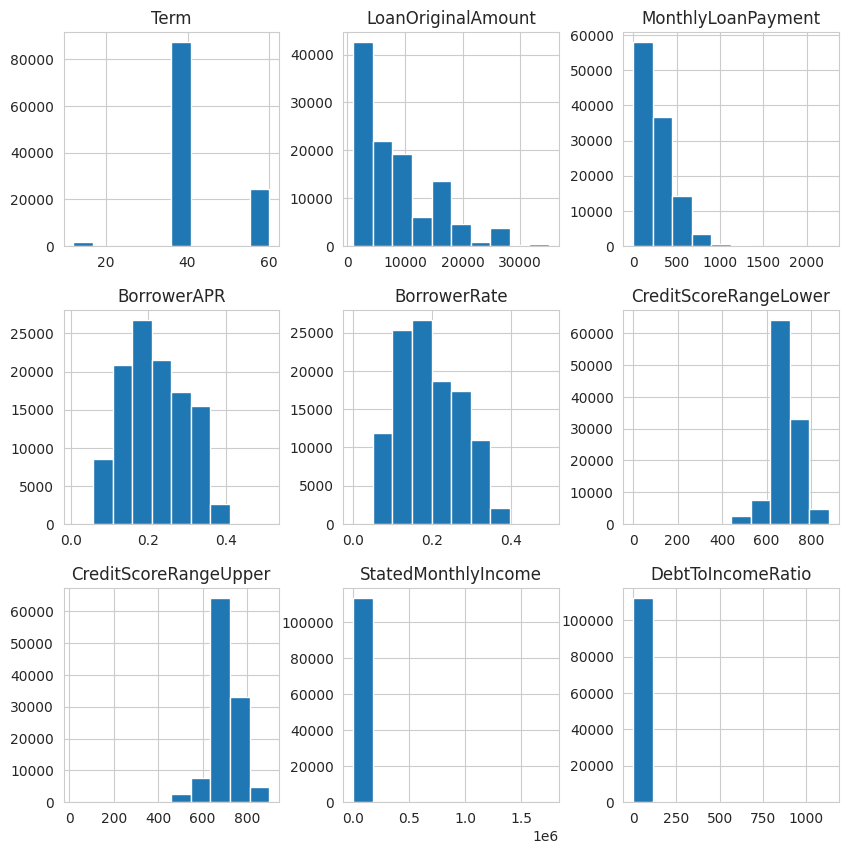

In [54]:
# all histograms in one place for a quick overview

# some vars are very skewed and will require transformations

df.hist(['Term', 'LoanOriginalAmount', 'MonthlyLoanPayment', 'ListingCategory', 'BorrowerAPR', 'BorrowerRate',\
         'CreditScoreRangeLower', 'CreditScoreRangeUpper', 'StatedMonthlyIncome', 'DebtToIncomeRatio'],\
        figsize=(10,10));

We will take look at all selected variables one by one to learn more details about their distributions.
### LoanOriginationDate

In [55]:
df.LoanOriginationDate.describe()

count                           113066
mean     2011-07-14 07:09:18.916031232
min                2005-11-15 00:00:00
25%                2008-09-26 00:00:00
50%                2012-06-20 00:00:00
75%                2013-09-11 00:00:00
max                2014-03-12 00:00:00
Name: LoanOriginationDate, dtype: object

In [56]:
df[df.LoanOriginationDate < '2009-01-01 00:00:00'].count()['LoanOriginationDate']

28940

Dataset includes loans from period 2005-2014.<br>
28,940 loans are from the period 2005-2008.

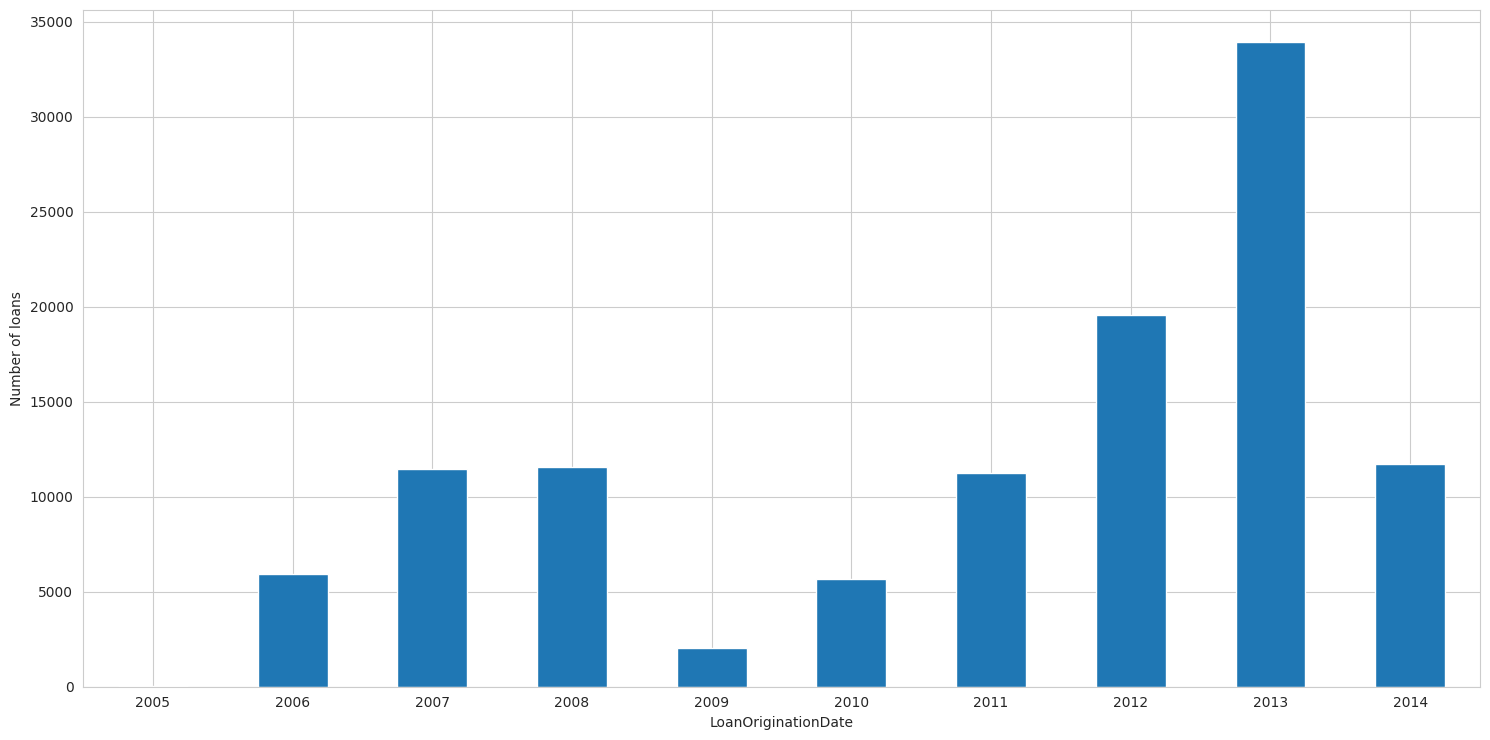

In [57]:
# 2009 was a critical year for Prosper
df.groupby(df.LoanOriginationDate.dt.year).count()['LoanOriginationDate'].plot(kind='bar')
plt.ylabel('Number of loans')
plt.xticks(rotation=0)
plt.tight_layout();

In [58]:
df['LoanYear'] = df['LoanOriginationDate'].dt.year
df.LoanYear.dtype

dtype('int32')

In [59]:
# let's look at the tails: 2005 and 2014 to know why there are fewer loans on those years
df[df.LoanOriginationDate.dt.year == 2005].count()['LoanOriginationDate']

22

In [60]:
# our data ends in March 2014
df.LoanOriginationDate.max()

Timestamp('2014-03-12 00:00:00')

Prosper started business in 2005, which is also the oldest loans which we have in the data set. However, there are only 22 loans from 2005.<br>
Prosper stopped their business between Nov 2008 - July 2009 due to a cease order by SEC, which is very much reflected in the low number of loans in 2009.<br>
Borrowers may come from 47 US states, bidders can come only from 28 US states since the relaunch. (source: https://en.wikipedia.org/wiki/Prosper_Marketplace)<br>
Since 2010, the number of new loans increases steadily, with a record number of new loans in 2013.<br>
We only have two months of full data for 2014.

### ClosedDate

In [61]:
# 55076 loans are already closed
df.ClosedDate.notnull().sum()

55056

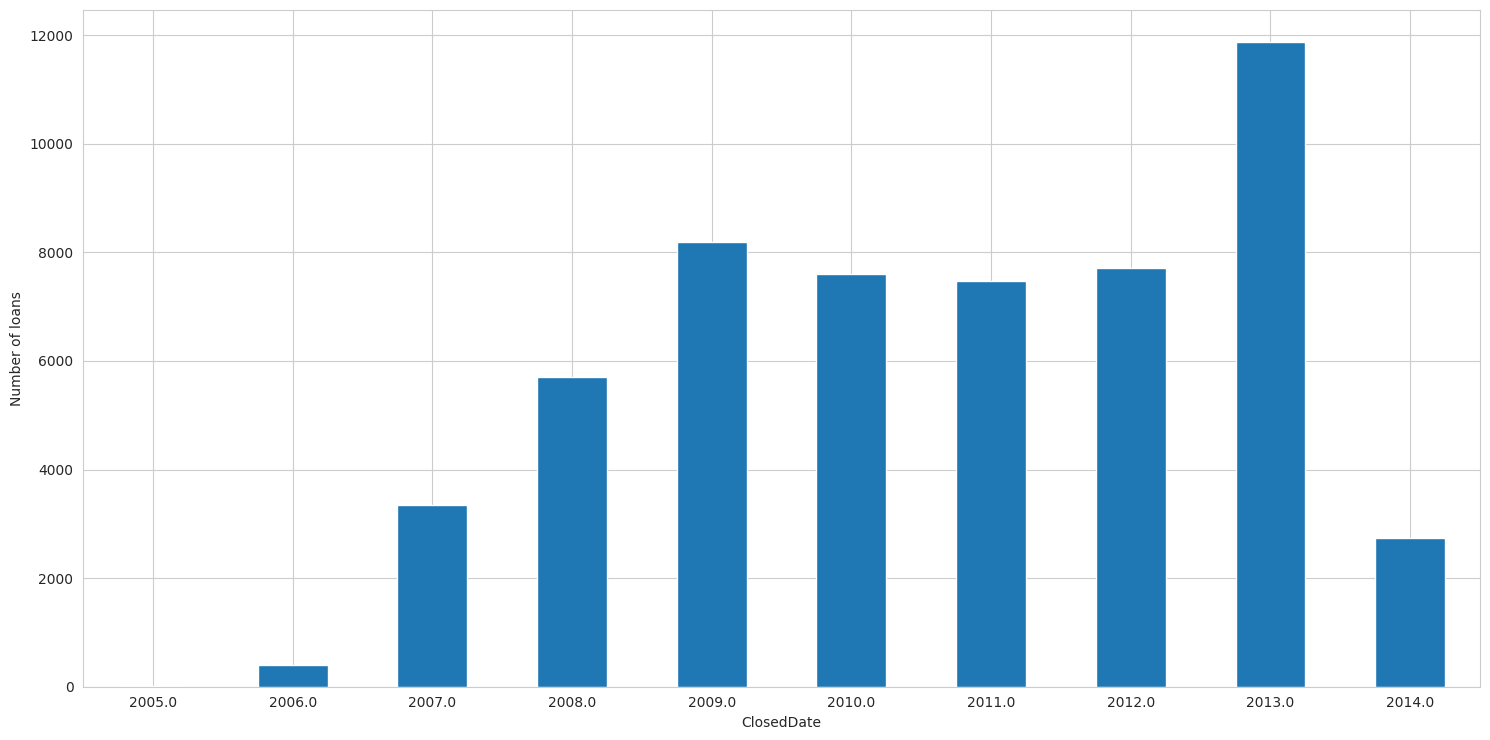

In [62]:
df.groupby(df.ClosedDate.dt.year).count()['ClosedDate'].plot(kind='bar')
plt.ylabel('Number of loans')
plt.xticks(rotation=0)
plt.tight_layout();

In [63]:
# months between loan origination and closing date
df['MonthsToClosed'] = ((df.ClosedDate - df.LoanOriginationDate) / np.timedelta64(1, 'M'))

In [64]:
df['MonthsToClosed'].describe()

count    55056.000000
mean        18.943528
std         11.405131
min        -44.709677
25%          9.064516
50%         16.741935
75%         30.451613
max         50.225806
Name: MonthsToClosed, dtype: float64

In [65]:
df[df['MonthsToClosed'] < 0]

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating,ListingCategory,BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanNumber,LoanOriginalAmount,LoanOriginationDate,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors,LoanYear,MonthsToClosed
LoanKey,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5BA53702830459166F4AD14,DEAA359893047281162F432,1099553,NaT,NaN,36,Defaulted,2010-03-16,0.14206,0.1139,0.1039,0.09989,0.0349,0.06499,6.0,A,1,CO,Professional,Self-employed,7.0,False,False,NaN,660.0,679.0,1983-01-01,6.0,5.0,33.0,4,96.0,0.0,3.0,1.0,330.0,36.0,1.0,0.0,491.0,0.00,3700.0,30.0,0.5,2.0,0.013167,"$75,000-99,999",False,6250.000000,1.0,30.0,14.0,7.0,9.0,1900.0,0.0,123,NaN,3,124070,2500,2013-12-31,Q4 2013,050B3418715458847641BA4,82.31,163.8399,119.1,44.7399,-3.99,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1,2013,-44.709677
BF6034334495990283E5285,E77E34330098056070F5C30,410006,NaT,A,36,Cancelled,2008-10-16,0.16219,0.1075,0.0975,0.08835,NaN,NaN,NaN,NaN,1,FL,Other,Full-time,30.0,False,False,NaN,720.0,739.0,1993-04-01,9.0,7.0,21.0,5,113.0,1.0,8.0,0.0,0.0,3.0,0.0,0.0,686.0,0.05,11500.0,15.0,0.6,0.0,0.340000,"$25,000-49,999",True,2444.666667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,65,37807,1000,2008-10-17,Q4 2008,D187343311025159191B2D8,32.62,0.0000,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,25,2008,-0.032258


There are 2 loans with closed date prior to loan origination date, which we will delete:

In [66]:
df.drop(df[df['MonthsToClosed'] < 0].index, inplace=True)
df.shape

(113064, 79)

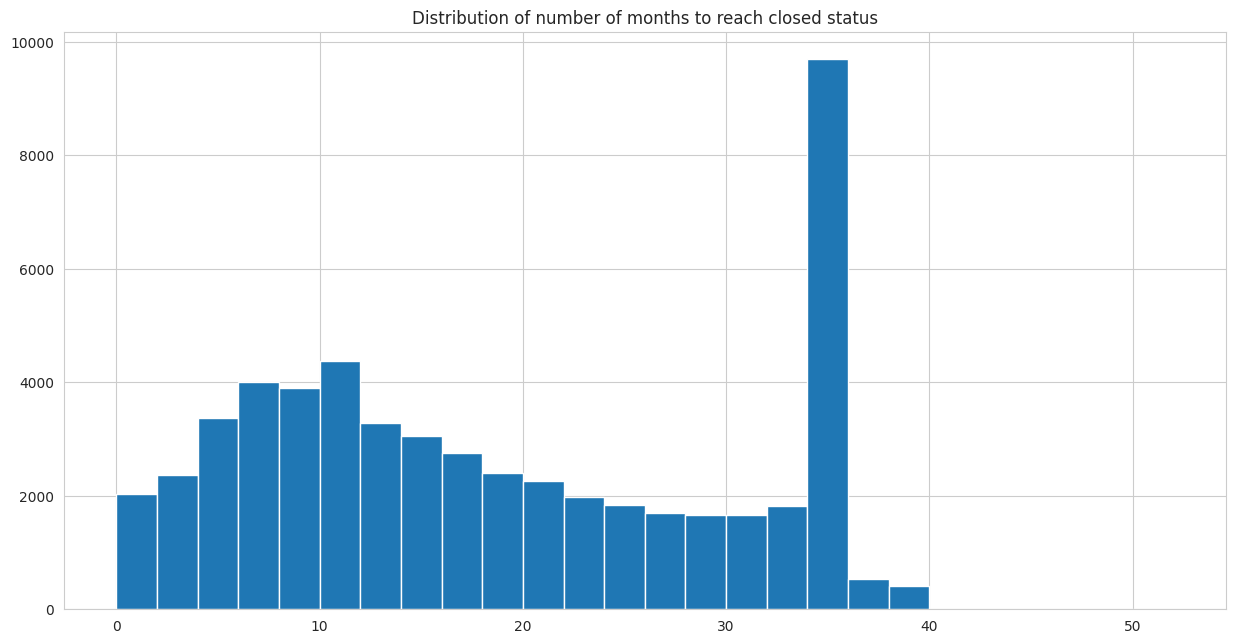

In [67]:
bins = np.arange(0, df['MonthsToClosed'].max()+2, 2)
plt.hist(data = df, x = 'MonthsToClosed', bins = bins)
plt.title('Distribution of number of months to reach closed status');

In [68]:
df[['LoanOriginationDate', 'ClosedDate', 'MonthsToClosed', 'Term', 'LoanStatus']].head()

,LoanOriginationDate,ClosedDate,MonthsToClosed,Term,LoanStatus
LoanKey,,,,,
E33A3400205839220442E84,2007-09-12,2009-08-14,22.645161,36,Completed
9E3B37071505919926B1D82,2014-03-03,NaT,NaN,36,Current
6954337960046817851BCB2,2007-01-17,2009-12-17,34.354839,36,Completed
A0393664465886295619C51,2012-11-01,NaT,NaN,36,Current
A180369302188889200689E,2013-09-20,NaT,NaN,36,Current


There are 55k of closed loans. Generated column MonthsToClosed looks at number of months between loan origination date and closed date.<br>
The distribution of MonthsToClosed is bimodal with one peak around 12 months and another peak around 36 months.<br>

### LoanStatus

In [69]:
df.LoanStatus.value_counts()

LoanStatus
Current                   55730
Completed                 38061
Chargedoff                11992
Defaulted                  5017
Past Due (1-15 days)        800
Past Due (31-60 days)       361
Past Due (61-90 days)       311
Past Due (91-120 days)      304
Past Due (16-30 days)       265
FinalPaymentInProgress      203
Past Due (>120 days)         16
Cancelled                     4
Name: count, dtype: int64

\It makes sense to divide loan status further into active and non-active loans because these are two distinct groups.<br>
ClosedDate can used for this.

In [70]:
df.loc[df['ClosedDate'].isnull(), 'LoanStatusActive'] = 1
df.loc[df['ClosedDate'].notnull(), 'LoanStatusActive'] = 0
df.LoanStatusActive.value_counts()

LoanStatusActive
1.0    58010
0.0    55054
Name: count, dtype: int64

In [71]:
df.LoanStatusActive = df['LoanStatusActive'].astype('bool')
df.LoanStatusActive.dtype

dtype('bool')

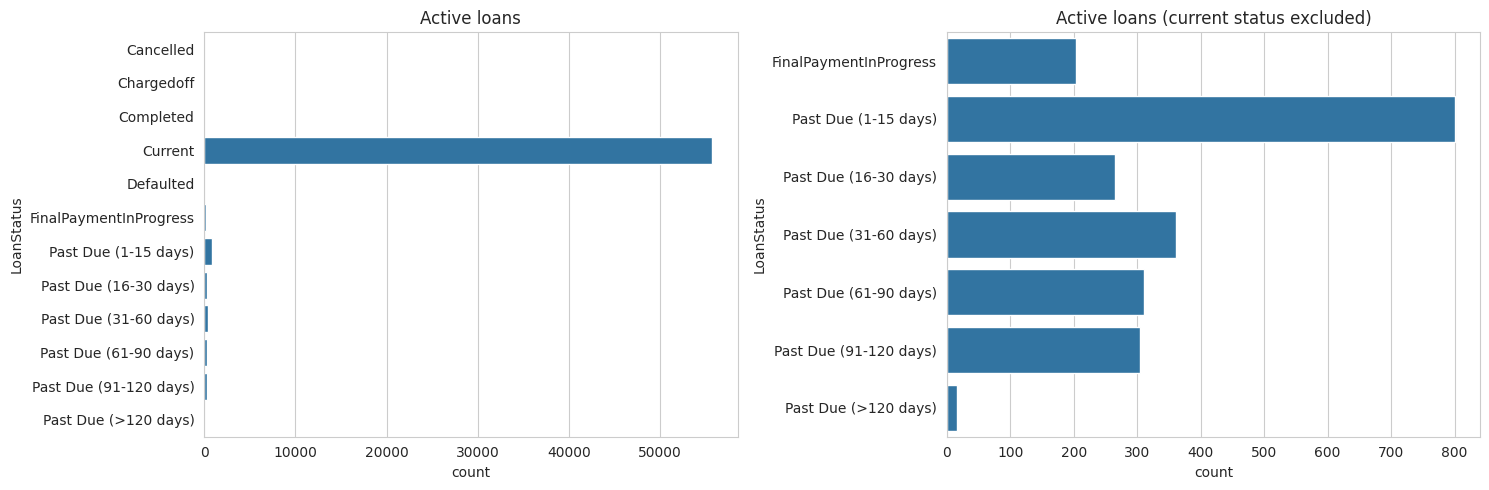

In [72]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)

# set base color for plots
base_color = sns.color_palette()[0]

sns.countplot(data = df[df.LoanStatusActive == 1], y = 'LoanStatus', color = base_color, orient = 'h')
plt.xticks(rotation = 0)
plt.title('Active loans')

plt.subplot(1,2,2)
order = ['FinalPaymentInProgress', 'Past Due (1-15 days)', 'Past Due (16-30 days)', \
         'Past Due (31-60 days)', 'Past Due (61-90 days)', 'Past Due (91-120 days)', 'Past Due (>120 days)']
sns.countplot(data = df[df.LoanStatus.isin(order)], y = 'LoanStatus', order = order, color = base_color, orient = 'h')
plt.xticks(rotation = 0)
plt.title('Active loans (current status excluded)')
plt.tight_layout();

Among active loans, the vast majority are loans without any issues, i.e. in the "current" status.<br>
Among active loans not in the current status, the highest amount is in default for 1-15 days.

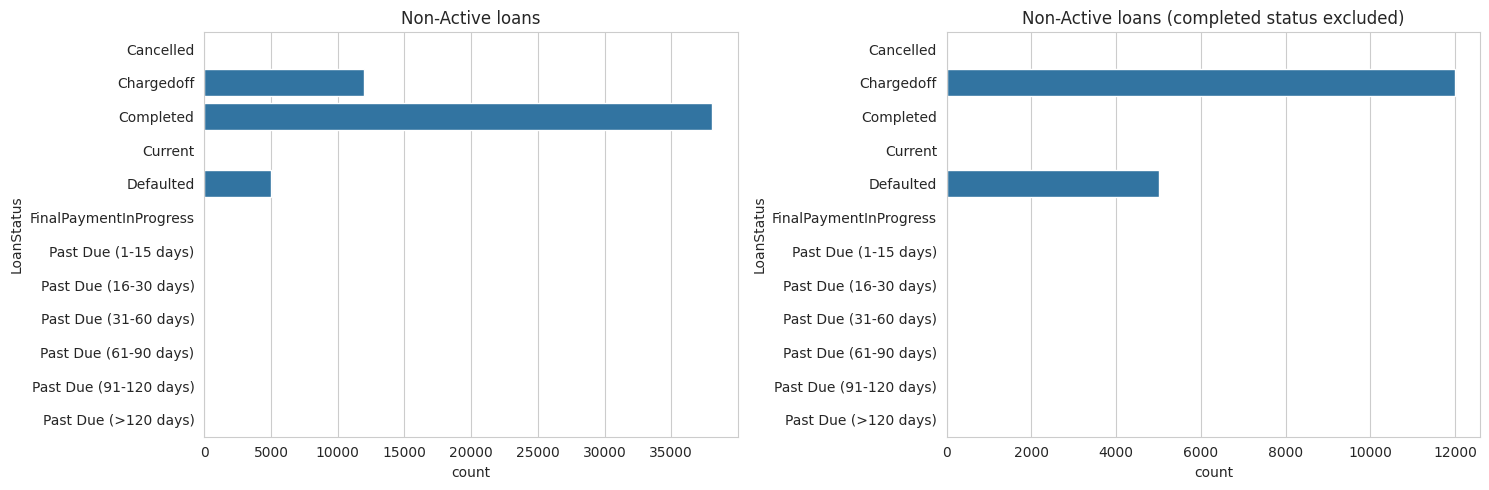

In [73]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.countplot(data = df[df.LoanStatusActive == 0], y = 'LoanStatus', color = base_color)
plt.xticks(rotation = 0)
plt.title('Non-Active loans')

plt.subplot(1,2,2)
sns.countplot(data = df[df.LoanStatus.isin(['Defaulted', 'Chargedoff', 'Cancelled'])], y = 'LoanStatus', \
             color = base_color)
plt.xticks(rotation = 0)
plt.title('Non-Active loans (completed status excluded)')
plt.tight_layout();

Most non-active loans are in "completed" status, i.e. fully repaid.<br>
In the not-repaid group of non-active loans, there are more charged off loans (i.e. those were the chance of repayment is minimal) than defaulted ones.

In [74]:
df[df.LoanStatus == 'Chargedoff'].count()['LoanStatus'] / len(df)

0.10606382225995896

Charged off loans make 10.6% of all loans.

In [75]:
# make status an ordered categorical var
ordered_var = pd.api.types.CategoricalDtype(ordered=True, categories = ['Current', 'FinalPaymentInProgress',
                                                                        'Past Due (1-15 days)', 'Past Due (16-30 days)',
                                                                        'Past Due (31-60 days)', 'Past Due (61-90 days)',
                                                                        'Past Due (91-120 days)', 'Past Due (>120 days)',
                                                                        'Completed', 'Defaulted', 'Chargedoff', 'Cancelled'])
df['LoanStatus'] = df['LoanStatus'].astype(ordered_var)

### Term

<ipython-input-76-81aadc9fcf4a>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'Term', palette = 'pastel');


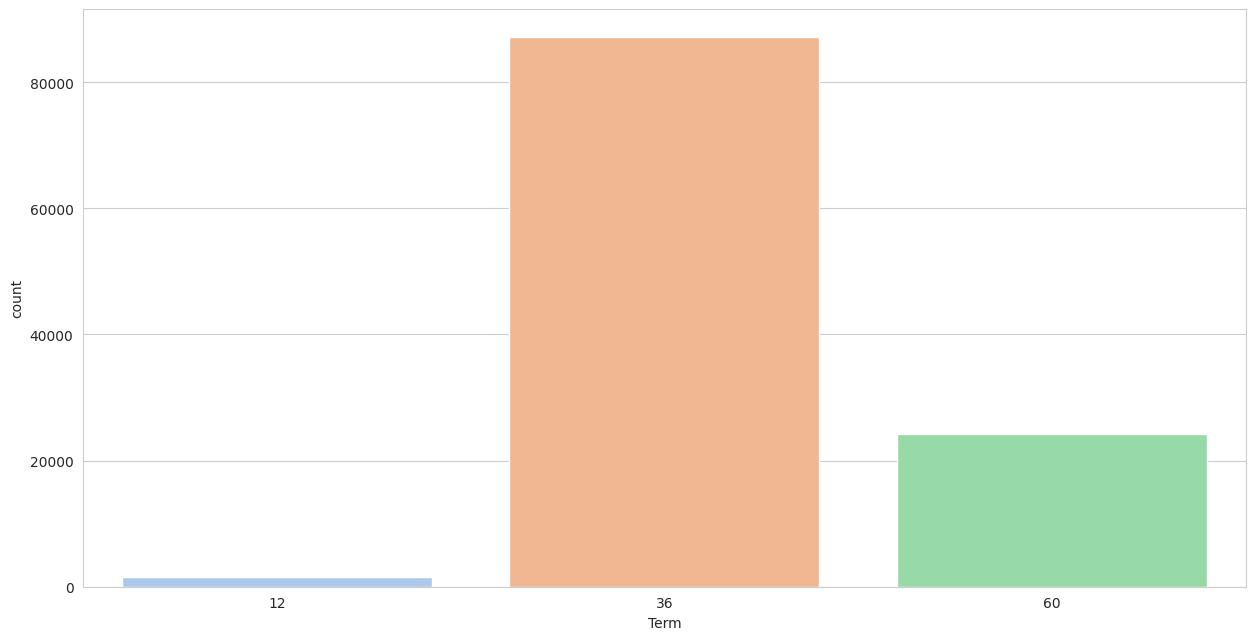

In [76]:
sns.countplot(data = df, x = 'Term', palette = 'pastel');

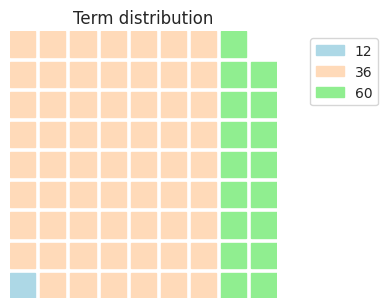

In [77]:
data = {'12': df[df['Term'] == 12].count()['Term'],
        '36': df[df['Term'] == 36].count()['Term'], '60': df[df['Term'] == 60].count()['Term']}
fig = plt.figure(
    FigureClass=Waffle,
    rows=9,
    columns=9,
    values=data,
    figsize=(4, 4),
    legend={'loc': 'upper left', 'bbox_to_anchor': (1.1, 1)},
    colors=("lightblue", "peachpuff", "lightgreen")
)
plt.title('Term distribution')
plt.show()

There are only 3 distinct loan terms:
1. 1 year (12 months)
2. 3 years (36 months)
3. 5 years (60 months)

The vast majority of loans is for 36 months.

### LoanOriginalAmount

<ipython-input-78-ca765e726b5b>:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['LoanOriginalAmount']);


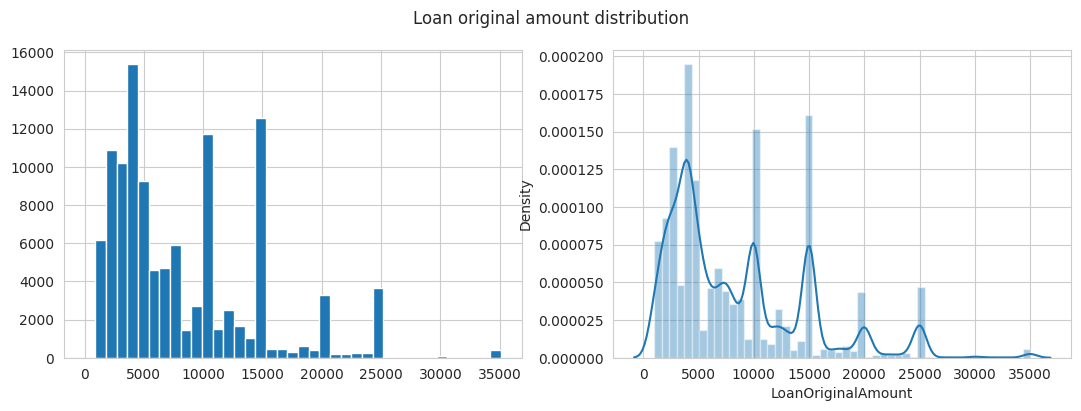

In [78]:
plt.figure(figsize=(13,4))
plt.suptitle('Loan original amount distribution')
plt.subplot(1,2,1)
bins = np.arange(0, df['LoanOriginalAmount'].max()+900, 900)
plt.hist(data = df, x = 'LoanOriginalAmount', bins = bins)

plt.subplot(1,2,2)
sns.distplot(df['LoanOriginalAmount']);

In [79]:
np.sort(df.LoanOriginalAmount.value_counts().nlargest(8).index)

array([ 2000,  3000,  4000,  5000, 10000, 15000, 20000, 25000])

In [80]:
df.LoanOriginalAmount.value_counts().nlargest(8)

LoanOriginalAmount
4000     14207
15000    12232
10000    10956
5000      6953
2000      6042
3000      5728
25000     3588
20000     3234
Name: count, dtype: int64

Loan amounts are right skewed with several peaks as shown in the histogram.<br>
The most frequently loaned amount is 4000.

### MonthlyLoanPayment

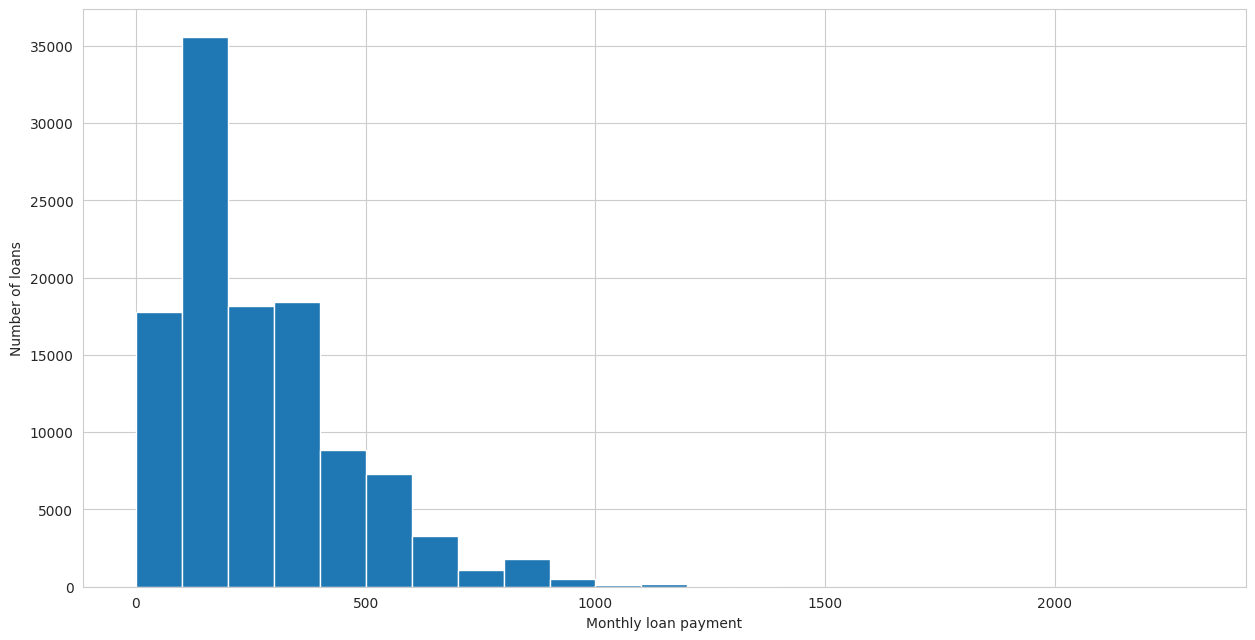

In [81]:
bins = np.arange(0, df['MonthlyLoanPayment'].max()+100, 100)
plt.hist(data = df, x = 'MonthlyLoanPayment', bins = bins)
plt.xlabel('Monthly loan payment')
plt.ylabel('Number of loans');

In [82]:
df.MonthlyLoanPayment.mode()

0    173.71
Name: MonthlyLoanPayment, dtype: float64

In [83]:
df.MonthlyLoanPayment.value_counts().nlargest(5)

MonthlyLoanPayment
173.71    2423
0.00       935
172.76     530
86.85      472
174.20     460
Name: count, dtype: int64

In [84]:
df.MonthlyLoanPayment.describe()

count    113064.000000
mean        271.936536
std         192.549541
min           0.000000
25%         130.950000
50%         217.370000
75%         370.570000
max        2251.510000
Name: MonthlyLoanPayment, dtype: float64

Monthly payment distribution is right skewed and has a long tail.<br>
Let's look at its log transformed distribution:

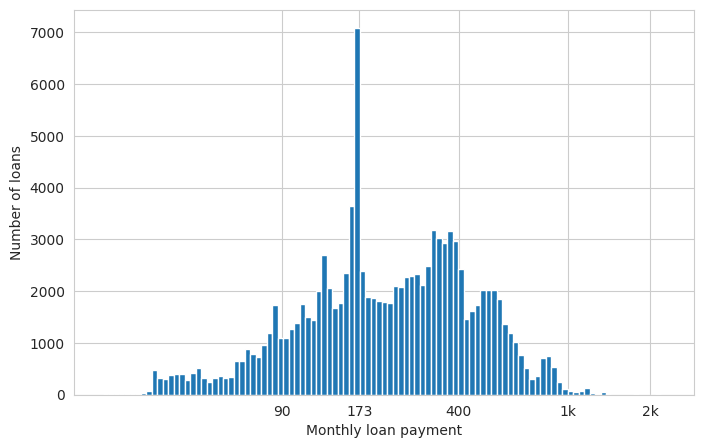

In [85]:
log_binsize = 0.02
bins = 10 ** np.arange(1.3, np.log10(df['MonthlyLoanPayment'].max())+log_binsize, log_binsize)

plt.figure(figsize=[8, 5])
plt.hist(data = df, x = 'MonthlyLoanPayment', bins = bins)
plt.xscale('log')
plt.xlabel('Monthly loan payment')
plt.ylabel('Number of loans')
plt.xticks([90, 173, 400, 1e3, 2e3], [90, 173, 400, '1k', '2k'])
plt.show()

Now we can see the distribution more clearly. Many loans have very low loan payments and the mode of 173 is clearly visible.

### ListingCategory

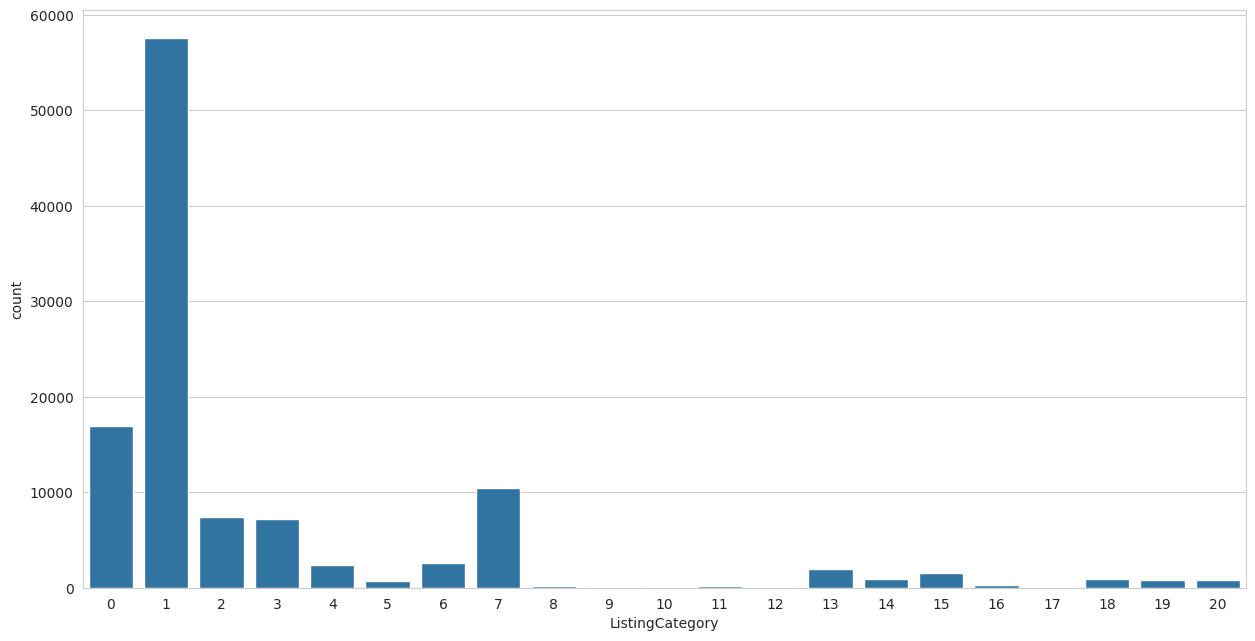

In [86]:
# keep ListingCategory as int to easily keep the same order in all plots and have legible axis labels
sns.countplot(data = df, x = 'ListingCategory', color = base_color);

The dictionary for listing categories is the following:
0. Not Available
1. Debt Consolidation
2. Home Improvement
3. Business
4. Personal Loan
5. Student Use
6. Auto
7. Other
8. Baby&Adoption
9. Boat
10. Cosmetic Procedure
11. Engagement Ring
12. Green Loans
13. Household Expenses
14. Large Purchases
15. Medical/Dental
16. Motorcycle
17. RV
18. Taxes
19. Vacation
20. Wedding Loans

By far the most loans are debt consolidation and many loans do not have a category defined.<br>
The distribution shows that ListingCategory might not be a very interesting variable for further analysis after all and if, then only in the top 5 categories. Below top 5 categories, there is a very small loan sample.

### BorrowerAPR and BorrowerRate

<ipython-input-87-1b6461344ccc>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['BorrowerAPR']);


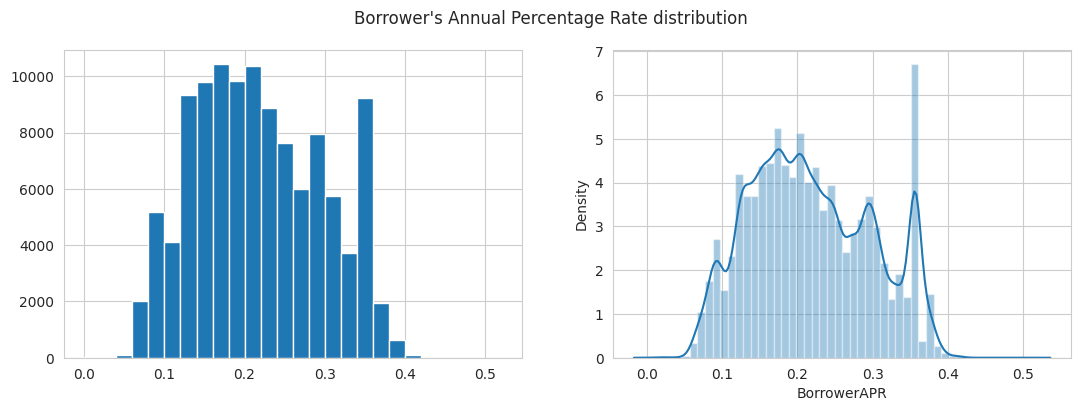

In [87]:
plt.figure(figsize=(13,4))
plt.suptitle("Borrower's Annual Percentage Rate distribution")
plt.subplot(1,2,1)
bins = np.arange(0, df.BorrowerAPR.max()+0.02, 0.02)
plt.hist(data = df, x = 'BorrowerAPR', bins = bins)
plt.subplot(1,2,2)
sns.distplot(df['BorrowerAPR']);

<ipython-input-88-50d5ea402f2a>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['BorrowerRate']);


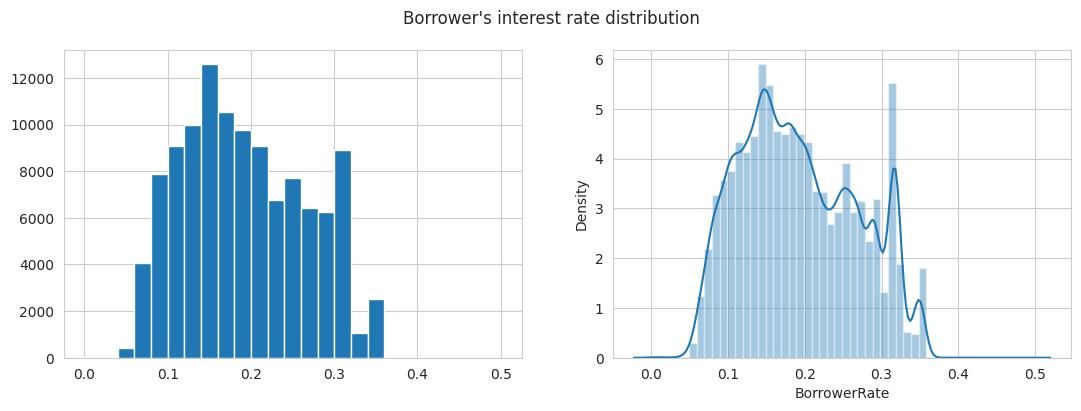

In [88]:
plt.figure(figsize=(13,4))
plt.suptitle("Borrower's interest rate distribution")
plt.subplot(1,2,1)
bins = np.arange(0, df.BorrowerRate.max()+0.02, 0.02)
plt.hist(data = df, x = 'BorrowerRate', bins = bins)
plt.subplot(1,2,2)
sns.distplot(df['BorrowerRate']);

<ipython-input-89-01c16df094f8>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  g = sns.distplot(df['BorrowerAPR'])
<ipython-input-89-01c16df094f8>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['BorrowerRate'])


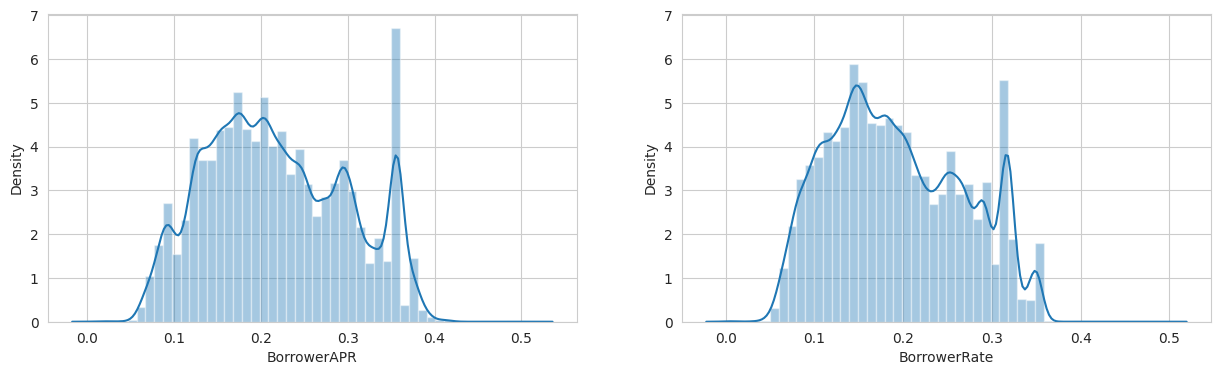

In [89]:
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
g = sns.distplot(df['BorrowerAPR'])
plt.subplot(1,2,2)
sns.distplot(df['BorrowerRate'])
plt.ylim(g.get_ylim());

In [90]:
df[['BorrowerAPR', 'BorrowerRate']].describe()

,BorrowerAPR,BorrowerRate
count,113064.000000,113064.000000
mean,0.218959,0.192947
std,0.080491,0.074916
min,0.006530,0.000000
25%,0.156290,0.134000
50%,0.209840,0.184000
75%,0.283860,0.250600
max,0.512290,0.497500


BorrowerAPR and BorrowerRate have very similar distributions.<br>
APR rate is somewhat larger because it includes fees.

In [91]:
# the most common rates are very high, as is also seen by the peak in the histogram
df['BorrowerAPR'].value_counts().nlargest(5)

BorrowerAPR
0.35797    3672
0.35643    1644
0.37453    1260
0.30532     902
0.29510     747
Name: count, dtype: int64

It is somewhat suprising that 25% of loans have APR larger than 28%, which seems very high.<br>
However, looking at the very extreme end of APR 0.4, there are 68 fully repaid loans and just 34 charged-off or defaulted in this category:

In [92]:
df[(df['BorrowerAPR']>= 0.4) & (df['LoanStatus'] == 'Completed')].count()['Term']

68

In [93]:
df[(df['BorrowerAPR']>= 0.4) & ((df['LoanStatus'] == 'Defaulted') | (df['LoanStatus'] == 'Chargedoff'))].count()['Term']

34

### CreditGrade and ProsperRating
These two columns belong together because they are mutually separated by age of loans. We can merge these two columns to get a rating for all loans.<br>
To prove this point and look at the final rating distribution, we have to do some bivariate plotting already at this point.<br>
Further, we will create another additional column which will group the ratings into risk categories.

<ipython-input-94-7f5b7d3ff800>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'CreditGrade', palette = 'RdYlBu_r')
<ipython-input-94-7f5b7d3ff800>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'ProsperRating', palette = 'RdYlBu_r');


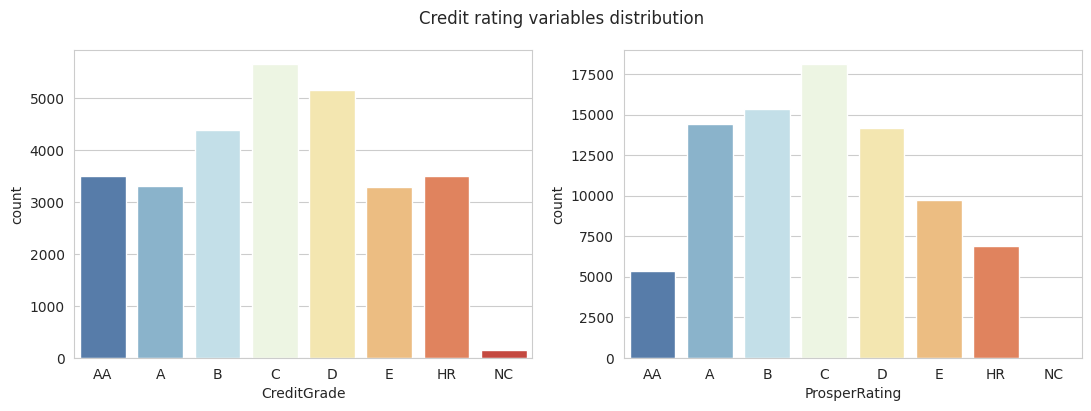

In [94]:
plt.figure(figsize=(13,4))
plt.suptitle("Credit rating variables distribution")
plt.subplot(1,2,1)
sns.countplot(data = df, x = 'CreditGrade', palette = 'RdYlBu_r')
plt.subplot(1,2,2)
sns.countplot(data = df, x = 'ProsperRating', palette = 'RdYlBu_r');

There are fewer loans with CreditGrade because it was only used until 2009 and since then, ProsperRating is used:

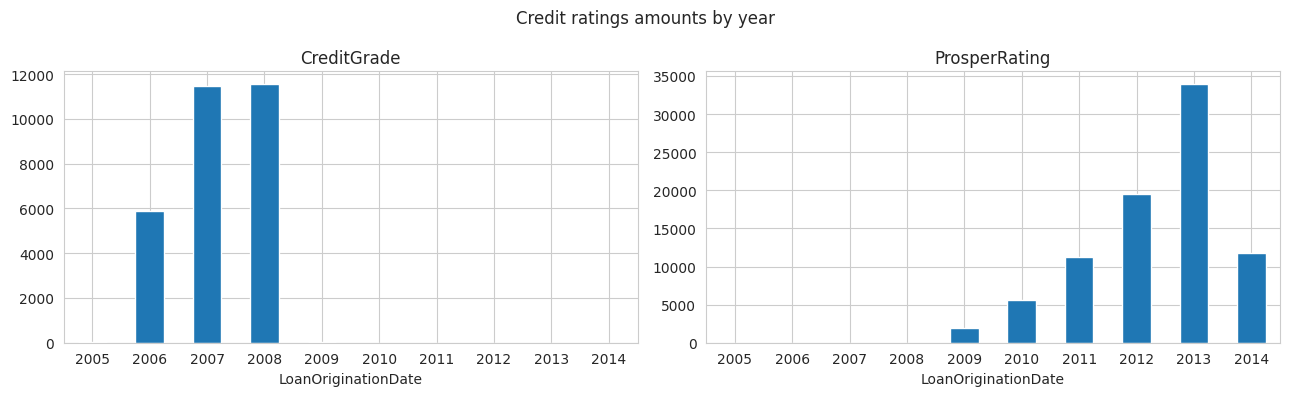

In [95]:
plt.figure(figsize=(13,4))
plt.suptitle("Credit ratings amounts by year")
plt.subplot(1,2,1)
df.groupby(df.LoanOriginationDate.dt.year).count()['CreditGrade'].plot(kind='bar')
plt.title('CreditGrade')
plt.xticks(rotation = 0)

plt.subplot(1,2,2)
df.groupby(df.LoanOriginationDate.dt.year).count()['ProsperRating'].plot(kind='bar')
plt.title('ProsperRating')
plt.xticks(rotation = 0)
plt.tight_layout();

In [96]:
# create new variable CreditRating which combines the two rating columns
df['CreditRating'] = np.where(df.CreditGrade.isnull(), df.ProsperRating, df.CreditGrade)

In [97]:
# test for correctness
df[['CreditGrade', 'ProsperRating', 'CreditRating']].sample(15)

,CreditGrade,ProsperRating,CreditRating
LoanKey,,,
8D9E34238849525005E167C,C,NaN,C
70BB37002950183633E0412,NaN,D,D
BAEF3621128414656F7CF3F,NaN,E,E
C7953697530854261D86775,NaN,B,B
010334128092582125AA386,A,NaN,A
137336996811137874034CB,NaN,C,C
4AA43648809860611C7FE47,NaN,HR,HR
14303390291388254FD1A8B,A,NaN,A
0DDC370614692358622208C,NaN,C,C


In [98]:
# make the new column CreditRating an ordinal categorical variable
df.CreditRating = df['CreditRating'].astype(pd.api.types.CategoricalDtype(ordered=True, categories = var_dict['CreditGrade']))

<ipython-input-99-8b664071f805>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'CreditRating', palette = 'RdYlBu_r')


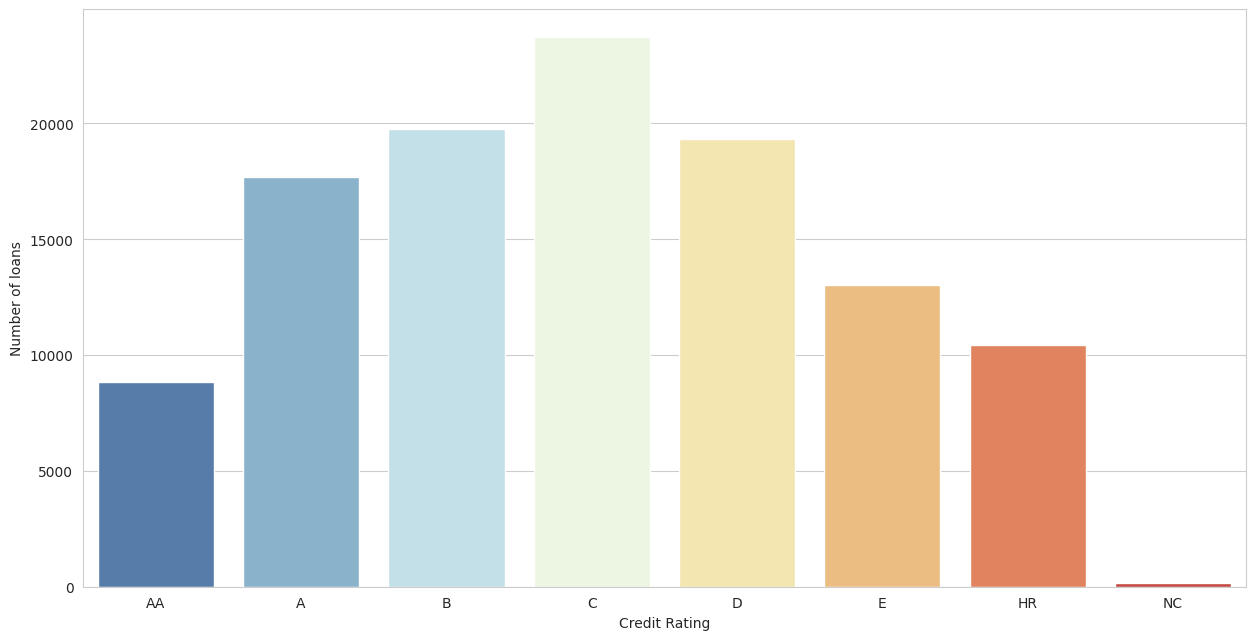

In [99]:
sns.countplot(data = df, x = 'CreditRating', palette = 'RdYlBu_r')
plt.xlabel('Credit Rating')
plt.ylabel('Number of loans');

In [100]:
# 131 loans are missing a rating
df.CreditRating.isnull().sum()

131

In [101]:
# because they did not have a rating in either CreditGrade or ProsperRating columns
df[df.CreditRating.isnull()][['LoanOriginationDate', 'CreditGrade', 'ProsperRating', 'CreditRating']].sample(5)

,LoanOriginationDate,CreditGrade,ProsperRating,CreditRating
LoanKey,,,,
2AA735726403333505E0763,2009-11-25,NaN,NaN,NaN
84EA3602813848912139C3D,2010-11-15,NaN,NaN,NaN
8DAB35725903159582444E8,2009-11-30,NaN,NaN,NaN
5AB33591066050660A8A65A,2010-06-30,NaN,NaN,NaN
A8F13577950848104DCAED1,2010-01-25,NaN,NaN,NaN


In [102]:
# these loans are from 2009-2010
df[df.CreditRating.isnull()][['LoanOriginationDate', 'CreditGrade', 'ProsperRating']].describe()

,LoanOriginationDate
count,131
mean,2010-03-11 14:28:23.816793856
min,2009-07-22 00:00:00
25%,2009-11-08 12:00:00
50%,2010-02-17 00:00:00
75%,2010-07-18 00:00:00
max,2010-12-30 00:00:00


It will also be useful to create another rating variable, which will group scores into a few riskiness categories.

In [103]:
# create new variable CreditRating which combines the two rating columns
df['CreditRisk'] = np.where(df.CreditRating.isin(['AA', 'A']), 'low',
                           np.where(df.CreditRating.isin(['B', 'C', 'D']), 'medium',
                                    np.where(df.CreditRating.isin(['E', 'HR', 'NC']), 'high', None)))

In [104]:
# test
df[['CreditRating', 'CreditRisk']].sample(5)

,CreditRating,CreditRisk
LoanKey,,
3A6A3583282136641FB22A7,HR,high
984436866659862962D4D4A,A,low
89713663102735949DA4237,C,medium
9E933706163645646A887A4,A,low
4CB7342372495174455B18A,B,medium


In [105]:
# test on NaN
df[df.CreditRating.isnull()][['CreditRating', 'CreditRisk']].sample(5)

,CreditRating,CreditRisk
LoanKey,,
73DA3588041005575E950A7,NaN,None
A4B43606349685079DD3BCD,NaN,None
E6C835964777916752781E8,NaN,None
97CE358298263115824E40D,NaN,None
3508359775713137232CD6C,NaN,None


In [106]:
df.CreditRisk.isnull().sum()

131

In [107]:
# CreditRisk as ordered categorical var
ordered_var = pd.api.types.CategoricalDtype(ordered=True, categories = ['low', 'medium', 'high'])
df['CreditRisk'] = df['CreditRisk'].astype(ordered_var)

<ipython-input-108-6346d48127b9>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'CreditRisk', palette = 'RdYlBu_r')


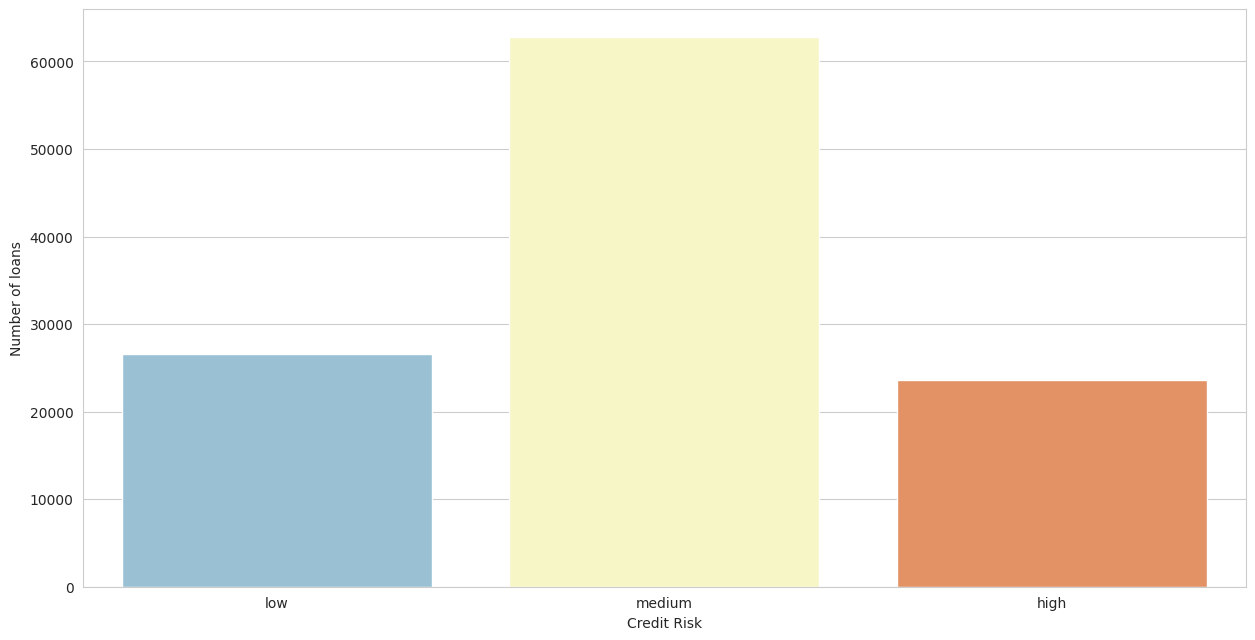

In [108]:
sns.countplot(data = df, x = 'CreditRisk', palette = 'RdYlBu_r')
plt.xlabel('Credit Risk')
plt.ylabel('Number of loans');

There are similar amounts of low and high risk loans with the majority if all loans being of medium risk.

### CreditScoreRangeLower and CreditScoreRangeUpper
We will look at these two variables together to compare the gap between them.

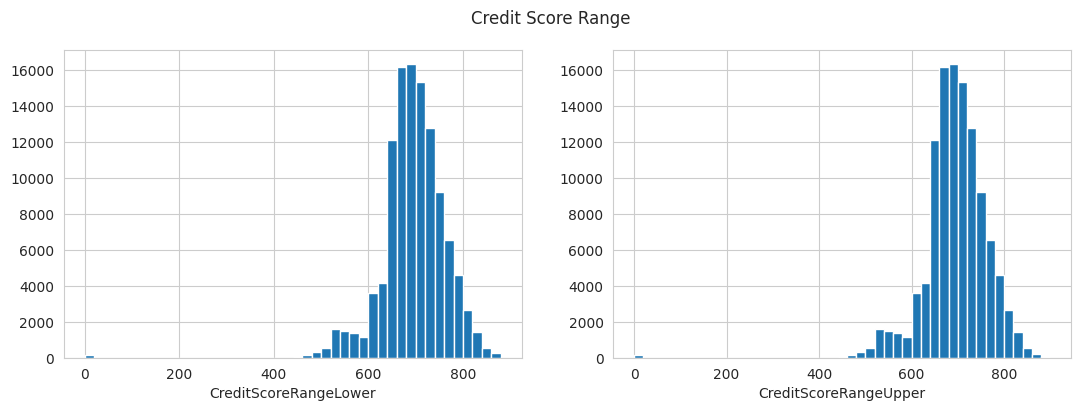

In [109]:
plt.figure(figsize=(13,4))
plt.suptitle("Credit Score Range")
plt.subplot(1,2,1)
bins_lower = np.arange(0, df.CreditScoreRangeLower.max()+20, 20)
plt.hist(data = df, x = 'CreditScoreRangeLower', bins = bins_lower)
plt.xlabel('CreditScoreRangeLower')
plt.subplot(1,2,2)
bins_upper = np.arange(0, df.CreditScoreRangeUpper.max()+20, 20)
plt.hist(data = df, x = 'CreditScoreRangeUpper', bins = bins_upper)
plt.xlabel('CreditScoreRangeUpper');

In [110]:
df[['CreditScoreRangeLower', 'CreditScoreRangeUpper']].describe()

,CreditScoreRangeLower,CreditScoreRangeUpper
count,112473.000000,112473.000000
mean,685.524882,704.524882
std,66.636364,66.636364
min,0.000000,19.000000
25%,660.000000,679.000000
50%,680.000000,699.000000
75%,720.000000,739.000000
max,880.000000,899.000000


The two distributions are very similar and this is because the range buckets are not large (they are of size 20) and here are all the existing buckets listed:

In [111]:
df.groupby(['CreditScoreRangeLower', 'CreditScoreRangeUpper'])['LoanOriginationDate'].count()

CreditScoreRangeLower  CreditScoreRangeUpper
0.0                    19.0                       133
360.0                  379.0                        1
420.0                  439.0                        5
440.0                  459.0                       36
460.0                  479.0                      141
480.0                  499.0                      346
500.0                  519.0                      554
520.0                  539.0                     1593
540.0                  559.0                     1474
560.0                  579.0                     1357
580.0                  599.0                     1125
600.0                  619.0                     3601
620.0                  639.0                     4172
640.0                  659.0                    12099
660.0                  679.0                    16176
680.0                  699.0                    16315
700.0                  719.0                    15315
720.0                  739.0         

### IncomeRange

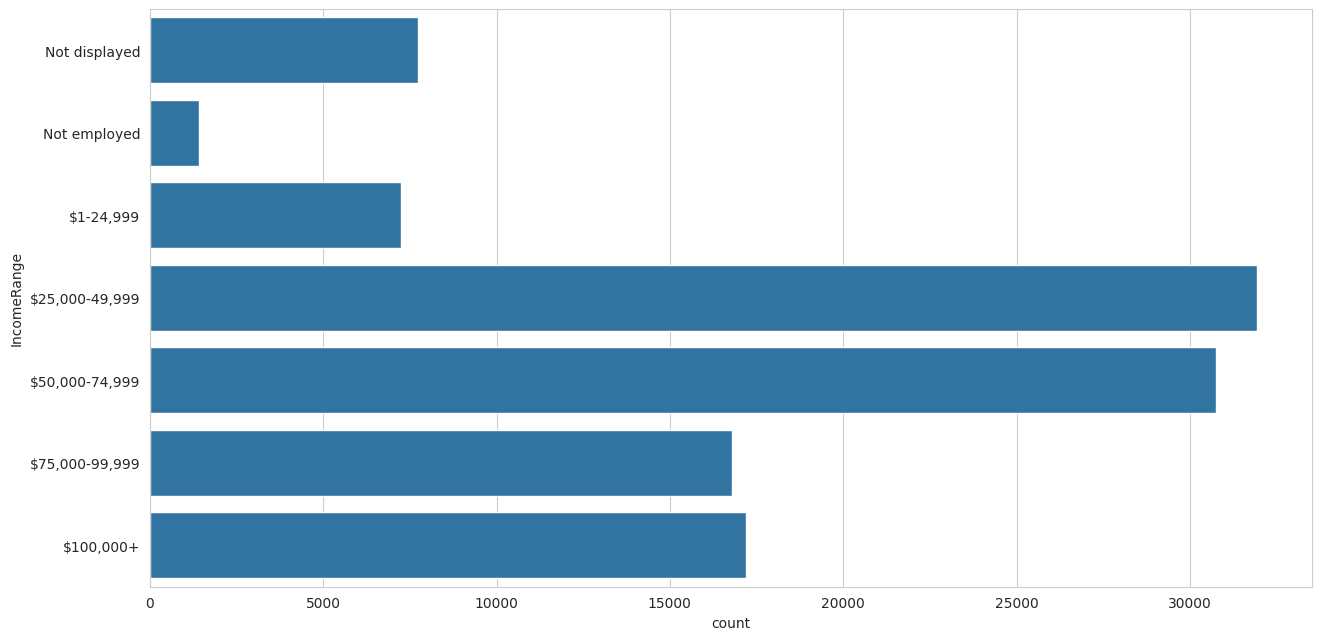

In [112]:
sns.countplot(data = df, y = 'IncomeRange', color = base_color)
plt.xticks(rotation = 0);

We can see two large groups in the loans: mid earners on the one hand (25k - 75k) making the majority of loans, and high earners group (75k+) on the other.

### IncomeVerifiable

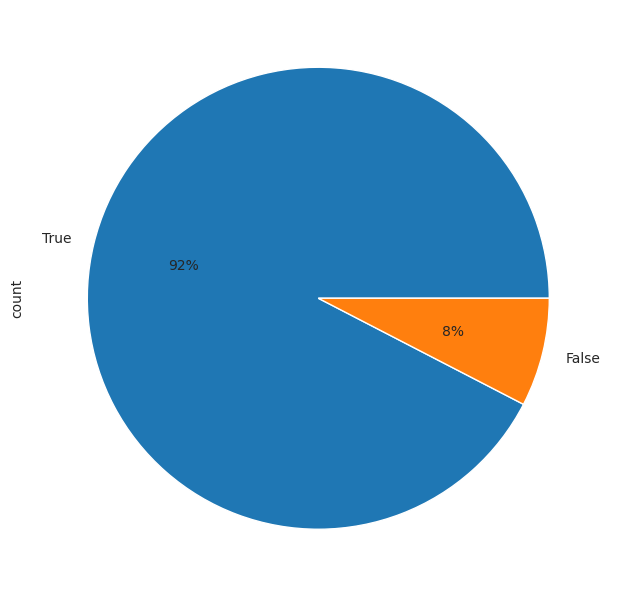

In [113]:
df.IncomeVerifiable.value_counts().plot(kind='pie', autopct='%1.0f%%');

Majority of loans have borrowers with a verifiable income.

### StatedMonthlyIncome

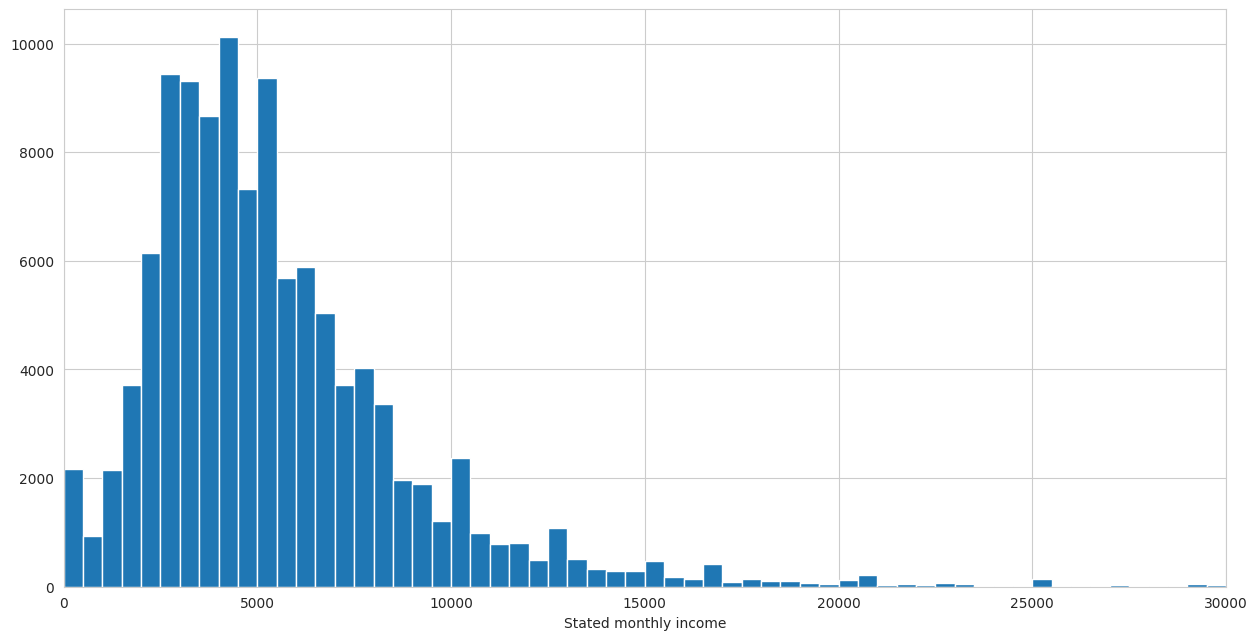

In [114]:
# monthly income is very right skewed
bins = np.arange(0, 30500, 500)
plt.hist(data = df, x = 'StatedMonthlyIncome', bins = bins)
plt.xlabel('Stated monthly income')
plt.xlim((0,30000));

<ipython-input-115-9806c635694e>:8: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim((0,80000))


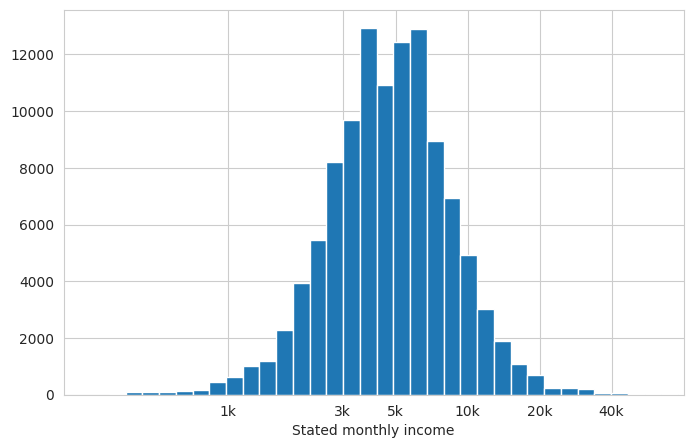

In [115]:
log_binsize = 0.07
bins = 10 ** np.arange(2.5, np.log10(df['StatedMonthlyIncome'].max())+log_binsize, log_binsize)

plt.figure(figsize=[8, 5])
plt.hist(data = df, x = 'StatedMonthlyIncome', bins = bins)
plt.xscale('log')
plt.xticks([1000, 3000, 5000, 10000, 20000, 40000], ['1k', '3k', '5k', '10k', '20k', '40k'])
plt.xlim((0,80000))
plt.xlabel('Stated monthly income')
plt.show()

Given the very skewed distribution of stated monthly income, we transformed the scale. The distribution looks normal after the transformation.

In [116]:
df.StatedMonthlyIncome.describe()

count    1.130640e+05
mean     5.605142e+03
std      7.495656e+03
min      0.000000e+00
25%      3.199521e+03
50%      4.666667e+03
75%      6.825000e+03
max      1.750003e+06
Name: StatedMonthlyIncome, dtype: float64

Some borrowers have very high stated monthly income of over 90k.<br>
These outliers might be errors, but we cannot be sure, so we don't delete them.

In [117]:
df[df.StatedMonthlyIncome > 90000][['IncomeVerifiable', 'CreditRisk', 'LoanStatus', 'EmploymentStatus', 'IncomeRange']].sample(5)

,IncomeVerifiable,CreditRisk,LoanStatus,EmploymentStatus,IncomeRange
LoanKey,,,,,
EF703676646898201ED52FE,True,low,Current,Employed,"$100,000+"
456B3381971458932656E4A,True,low,Completed,Not available,Not displayed
7FBE3611288193469713A0B,False,high,Completed,Self-employed,"$100,000+"
07DC3375769059207AD374E,True,low,Chargedoff,Not available,Not displayed
5D0136156133365609F840F,True,high,Current,Employed,"$100,000+"


In [118]:
df.StatedMonthlyIncome.value_counts().nlargest(5)

StatedMonthlyIncome
4166.666667    3486
5000.000000    3367
3333.333333    2889
3750.000000    2399
5416.666667    2351
Name: count, dtype: int64

### DebtToIncomeRatio

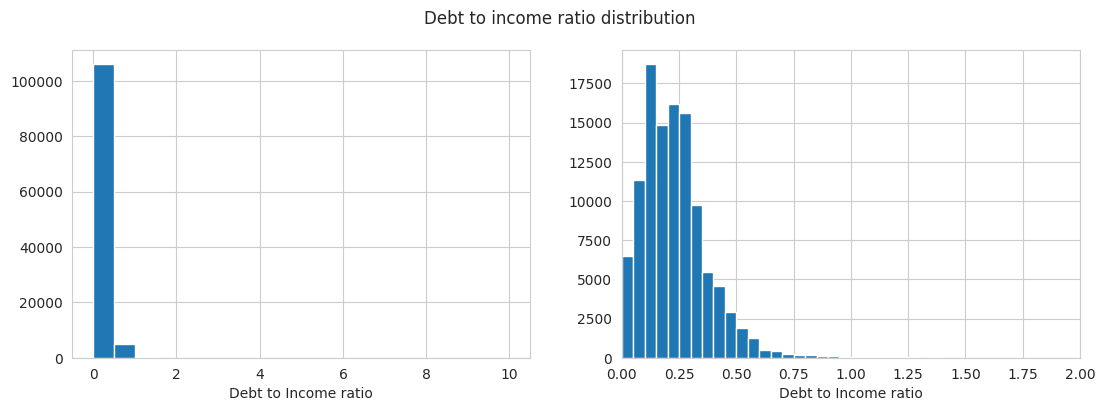

In [119]:
plt.figure(figsize=(13,4))
plt.suptitle('Debt to income ratio distribution')
plt.subplot(1,2,1)
bins = np.arange(0, 10.5, 0.5)
plt.hist(data = df, x = 'DebtToIncomeRatio', bins = bins)
plt.xlabel('Debt to Income ratio')

plt.subplot(1,2,2)
bins = np.arange(0, 2.05, 0.05)
plt.hist(data = df, x = 'DebtToIncomeRatio', bins = bins)
plt.xlim((0,2))
plt.xlabel('Debt to Income ratio');

In [120]:
df.DebtToIncomeRatio.describe()

count    113064.000000
mean          3.043781
std          33.664697
min           0.000000
25%           0.130000
50%           0.210000
75%           0.310000
max        1130.900000
Name: DebtToIncomeRatio, dtype: float64

Debt to income ratio is very right skewed with bulk of values around 0.2. Let's transform the scale to look at the distribution in detail:

<ipython-input-121-5f3fa34d21ff>:8: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim((0,5))


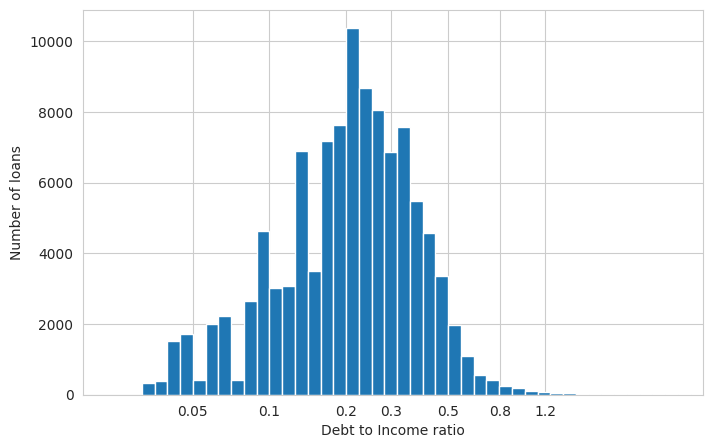

In [121]:
log_binsize = 0.05
bins = 10 ** np.arange(-1.5, np.log10(df['DebtToIncomeRatio'].max())+log_binsize, log_binsize)

plt.figure(figsize=[8, 5])
plt.hist(data = df, x = 'DebtToIncomeRatio', bins = bins)
plt.xscale('log')
plt.xticks([0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.2], [0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.2])
plt.xlim((0,5))
plt.xlabel('Debt to Income ratio')
plt.ylabel('Number of loans')
plt.show()

### EmploymentStatus

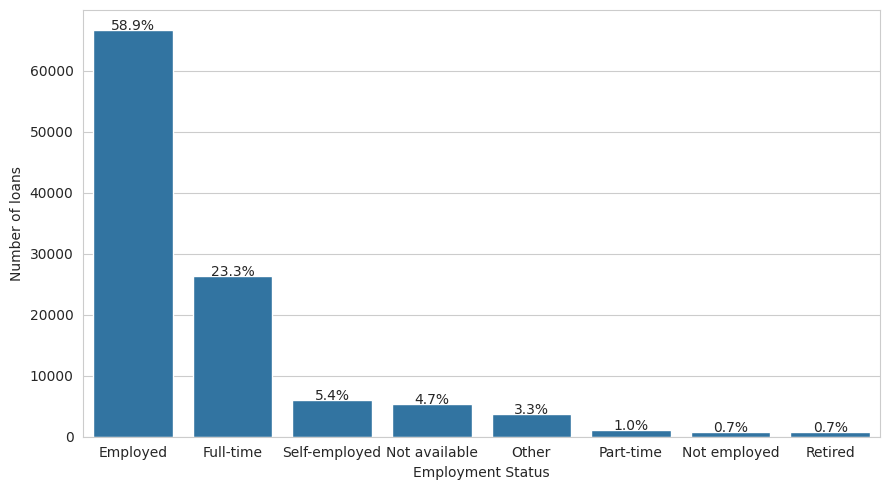

In [122]:
plt.figure(figsize=[9, 5])
status_counts = df['EmploymentStatus'].value_counts()
status_order = status_counts.index
max_count = status_counts[0]
max_prop = max_count / df.shape[0]
tick_props = np.arange(0, max_prop, 0.1)
tick_names = ['{:0.2f}'.format(v) for v in tick_props]

g = sns.countplot(data = df, x = 'EmploymentStatus', color = base_color, order = status_order)
plt.xticks(rotation = 0)
plt.xlabel('Employment Status')
plt.ylabel('Number of loans')


# values must be ordered from the largest for this to work
for i in range(status_counts.shape[0]):
    count = status_counts[i]
    pct_string = '{:0.1f}%'.format(100 * count / df.shape[0])
    plt.text(i, count+10, pct_string, ha = 'center')

plt.tight_layout();

Majority of borrowers are employed.

### IsBorrowerHomeowner

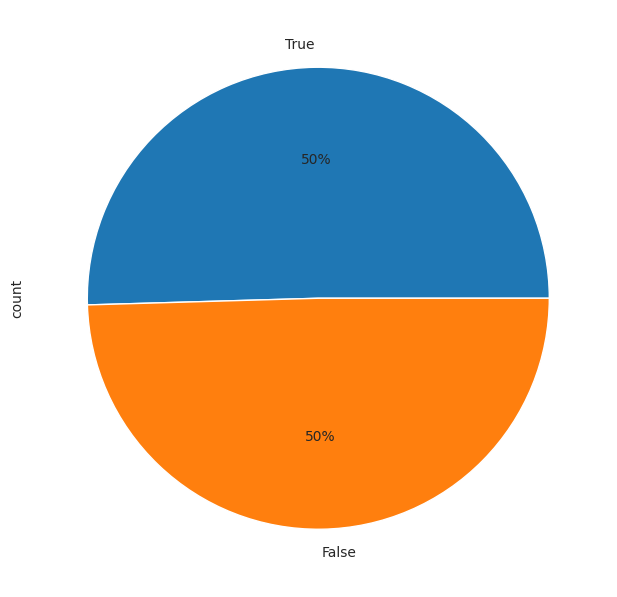

In [123]:
df.IsBorrowerHomeowner.value_counts().plot(kind='pie', autopct='%1.0f%%');

Exactly half of loans belongs to a borrower who is a home owner.

### Observations

**Variable Distribution and Data Operations:**

* I created a new credit rating variable by merging two existing rating variables, which were mutually exclusive by the loan origination date. I further created a credit risk variable, categorizing the rating into three groups: low, medium, or high risk.
* Loan original amount is multimodal, with the most popular loaned amounts being $4k, $15k, and $10k.
* From the two similar interest rates variables, I chose the borrower annual percentage rate.

**Unusual Distributions and Data Operations:**

* I deleted two loans with their closed date earlier than the loan origination date.
* I reduced the number of income ranges by one by merging USD 0 with Not Employed into the same category.
* I created an active loans dummy to quickly filter all active or non-active loan statuses from the data.
* I looked at a couple of right-skewed variables using a logarithmic scale to better see where the bulk of the data points lie.


## Bivariate Exploration

In [124]:
numeric_vars = ['BorrowerAPR', 'LoanOriginalAmount', 'MonthlyLoanPayment', 'CreditScoreRangeLower',
                'StatedMonthlyIncome', 'DebtToIncomeRatio', 'MonthsToClosed', 'Term']
bool_vars = ['LoanStatusActive', 'IncomeVerifiable', 'IsBorrowerHomeowner']
ordered_categoric_vars = ['IncomeRange', 'CreditRisk', 'CreditRating']

### Numeric variables

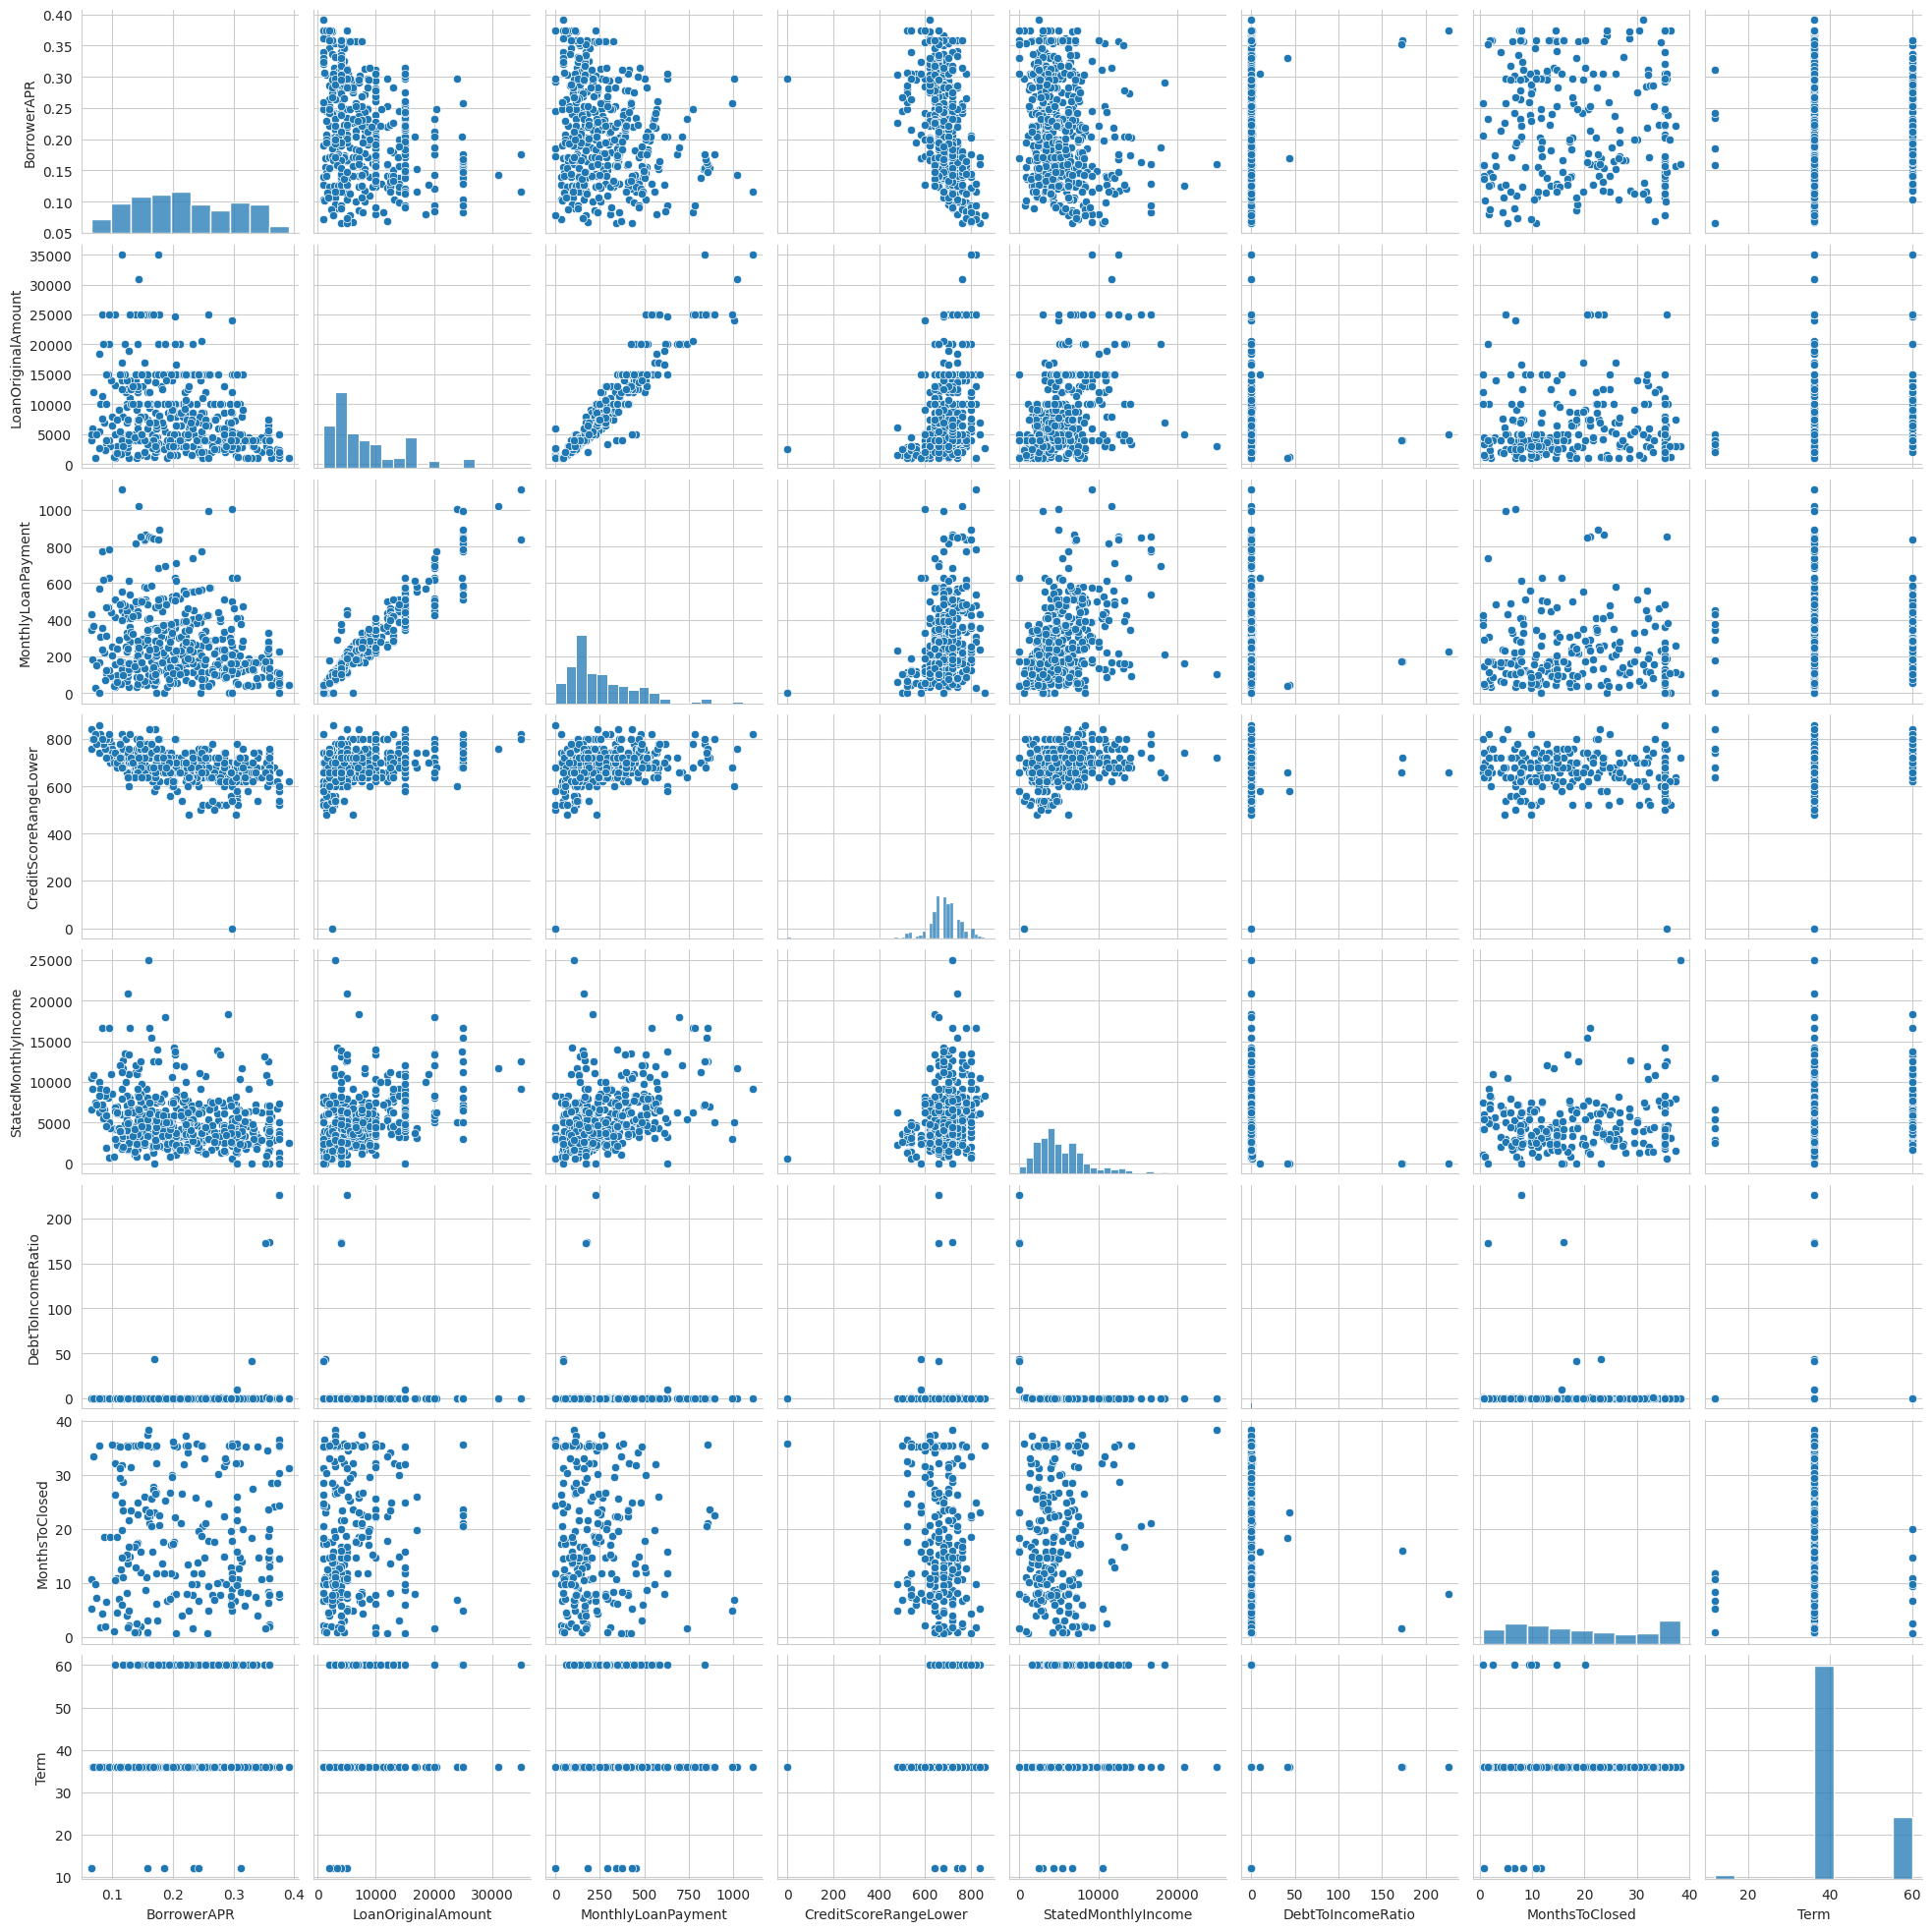

In [125]:
# pairplot of numeric vars to see relationships overview on a sample of data for faster rendering
sample = np.random.choice(df.shape[0], 500, replace = False)
df_samp = df.iloc[sample,:]
sns.pairplot(df_samp, vars = numeric_vars);

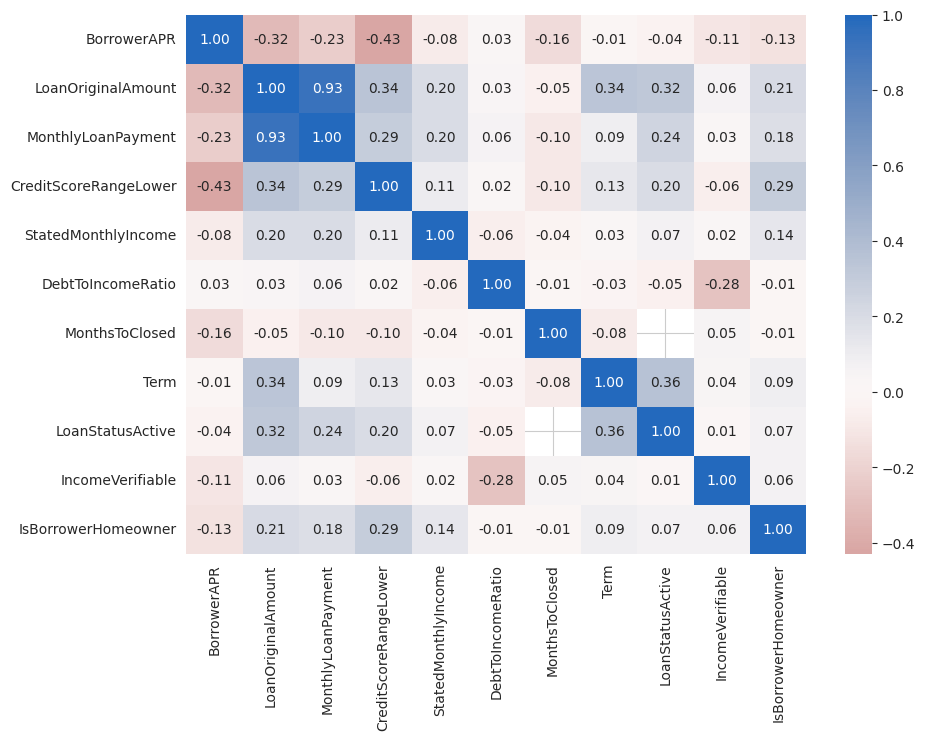

In [126]:
# correlations
plt.figure(figsize = [10, 7])
sns.heatmap(df[['BorrowerAPR', 'LoanOriginalAmount', 'MonthlyLoanPayment', 'CreditScoreRangeLower', 'StatedMonthlyIncome', \
              'DebtToIncomeRatio', 'MonthsToClosed', 'Term', 'LoanStatusActive', 'IncomeVerifiable', 'IsBorrowerHomeowner']]\
           .corr(), annot = True, fmt = '.2f',
           cmap = 'vlag_r', center = 0)
plt.show()

The dependent variables of our interest are **BorrowerAPR**, the borrower annual percentage rate, and **LoanOriginalAmount**, i.e. the borrowed amount.<br>
Based on the correlations, we will look into the following relationships of dependent variables:
* BorrowerAPR - LoanOriginalAmount
* BorrowerAPR - MonthlyLoanPayment
* BorrowerAPR - CreditScoreRangeLower
* LoanOriginalAmount - MonthlyLoanPayment
* LoanOriginalAmount - CreditScoreRangeLower

Further, we see that borrowers with a verifiable income tend to have a lower debt to income ratio and that active loans are on average for a longer period, higher amounts and higher monthly payments than non-active loans.

Relationships of interest:

<ipython-input-127-382ef15be018>:25: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim((0,2000))


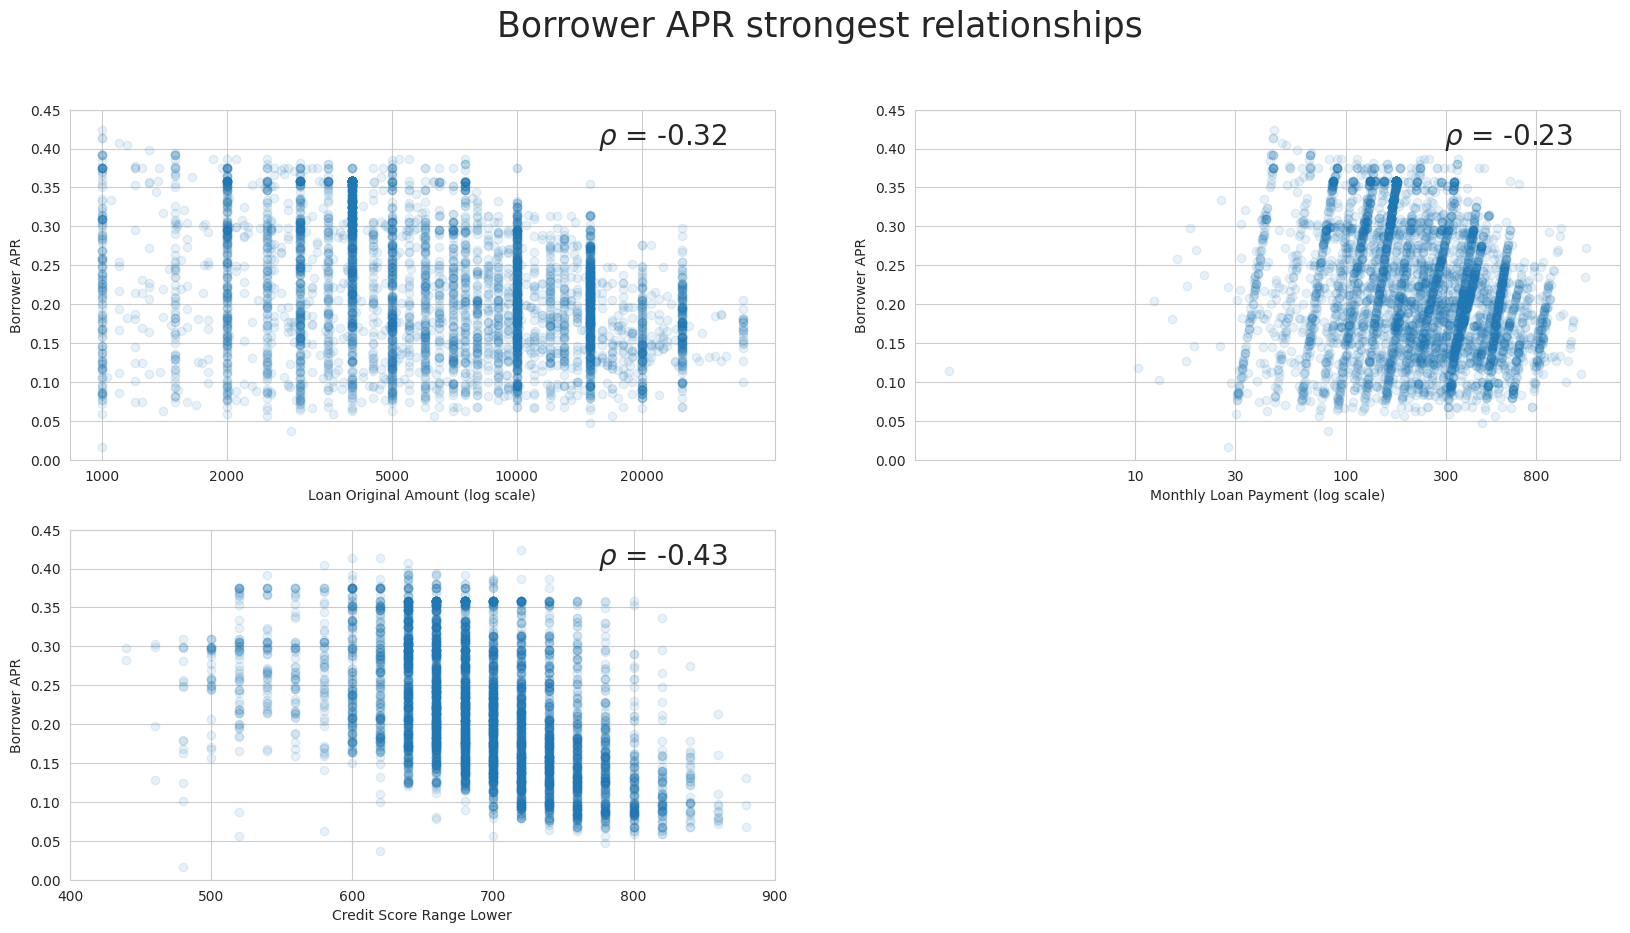

In [127]:
# a sample of 5000 from the data
sample = np.random.choice(df.shape[0], 5000, replace = False)
df_samp = df.iloc[sample,:]

plt.figure(figsize = (20,10))
plt.subplot(2,2,1)
g = plt.scatter(data = df_samp, x = 'LoanOriginalAmount', y = 'BorrowerAPR', alpha = 1/10)
plt.xscale('log')
plt.xlabel('Loan Original Amount (log scale)')
plt.ylabel('Borrower APR')
plt.ylim((0,0.45))
plt.xticks([1000, 2000, 5000, 10000, 20000], [1000, 2000, 5000, 10000, 20000])
# display the correlation
ax = plt.gca()
coef = df[['LoanOriginalAmount', 'BorrowerAPR']].corr().iloc[1,0]
label = r'$\rho$ = ' + str(round(coef, 2))
ax.annotate(label, xy = (0.75, 0.9), size = 20, xycoords = ax.transAxes)

plt.subplot(2,2,2)
plt.scatter(data = df_samp, x = 'MonthlyLoanPayment', y = 'BorrowerAPR', alpha = 1/10)
plt.xscale('log')
plt.xlabel('Monthly Loan Payment (log scale)')
plt.ylabel('Borrower APR')
plt.xticks([10, 30, 100, 300, 800], [10, 30, 100, 300, 800])
plt.xlim((0,2000))
plt.ylim((0,0.45))
# display the correlation
ax = plt.gca()
coef = df[['MonthlyLoanPayment', 'BorrowerAPR']].corr().iloc[1,0]
label = r'$\rho$ = ' + str(round(coef, 2))
ax.annotate(label, xy = (0.75, 0.9), size = 20, xycoords = ax.transAxes)

plt.subplot(2,2,3)
plt.scatter(data = df_samp, x = 'CreditScoreRangeLower', y = 'BorrowerAPR', alpha = 1/10)
plt.xlabel('Credit Score Range Lower')
plt.ylabel('Borrower APR')
plt.xlim((400, 900))
plt.ylim((0,0.45))
# display the correlation
ax = plt.gca()
coef = df[['CreditScoreRangeLower', 'BorrowerAPR']].corr().iloc[1,0]
label = r'$\rho$ = ' + str(round(coef, 2))
ax.annotate(label, xy = (0.75, 0.9), size = 20, xycoords = ax.transAxes)

plt.suptitle('Borrower APR strongest relationships', size = 25);

The negative correlations of BorrowerAPR and loan original amount, monthly loan payment and credit score range lower are somewhat visible from the scatter plots and they all make logical sense.

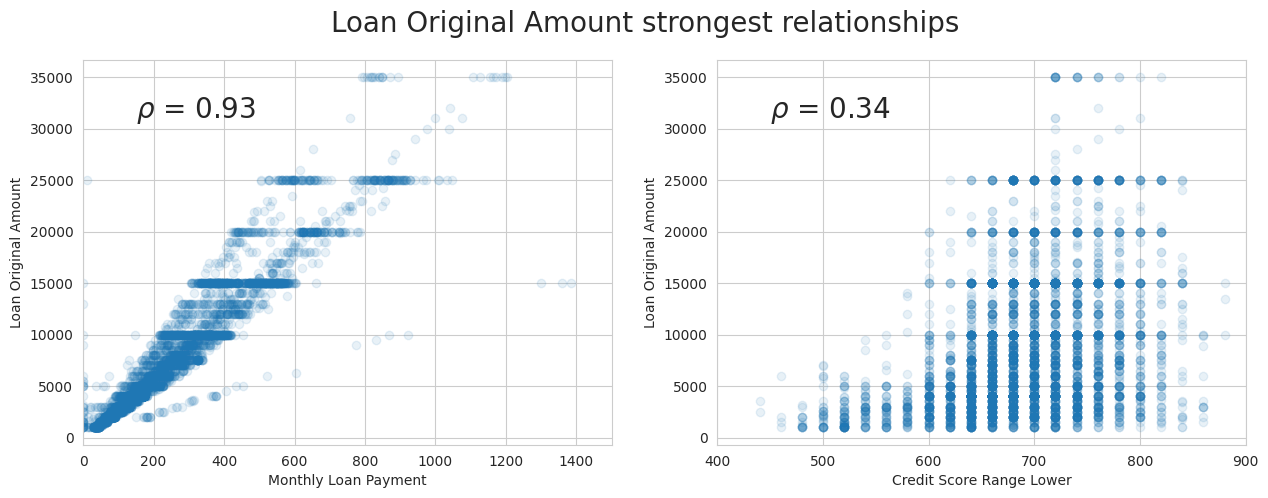

In [128]:
plt.figure(figsize = (15,5))
plt.subplot(1,2,1)
plt.scatter(data = df_samp, x = 'MonthlyLoanPayment', y = 'LoanOriginalAmount', alpha = 1/10)
plt.ylabel('Loan Original Amount')
plt.xlabel('Monthly Loan Payment')
plt.xlim((0,1500))
# display the correlation
ax = plt.gca()
coef = df[['MonthlyLoanPayment', 'LoanOriginalAmount']].corr().iloc[1,0]
label = r'$\rho$ = ' + str(round(coef, 2))
ax.annotate(label, xy = (0.1, 0.85), size = 20, xycoords = ax.transAxes)

plt.subplot(1,2,2)
plt.scatter(data = df_samp, x = 'CreditScoreRangeLower', y = 'LoanOriginalAmount', alpha = 1/10)
plt.xlabel('Credit Score Range Lower')
plt.ylabel('Loan Original Amount')
plt.xlim((400,900))
# display the correlation
ax = plt.gca()
coef = df[['CreditScoreRangeLower', 'LoanOriginalAmount']].corr().iloc[1,0]
label = r'$\rho$ = ' + str(round(coef, 2))
ax.annotate(label, xy = (0.1, 0.85), size = 20, xycoords = ax.transAxes)
plt.suptitle('Loan Original Amount strongest relationships', size = 20);

The positive correlation of loan original amount with monthly loan payment and credit score range lower is clear from the plots and makes logical sense, too.<br>
Displaying monthly payment on a logarithmic scale shows the quadratic relationship with loan original amount.

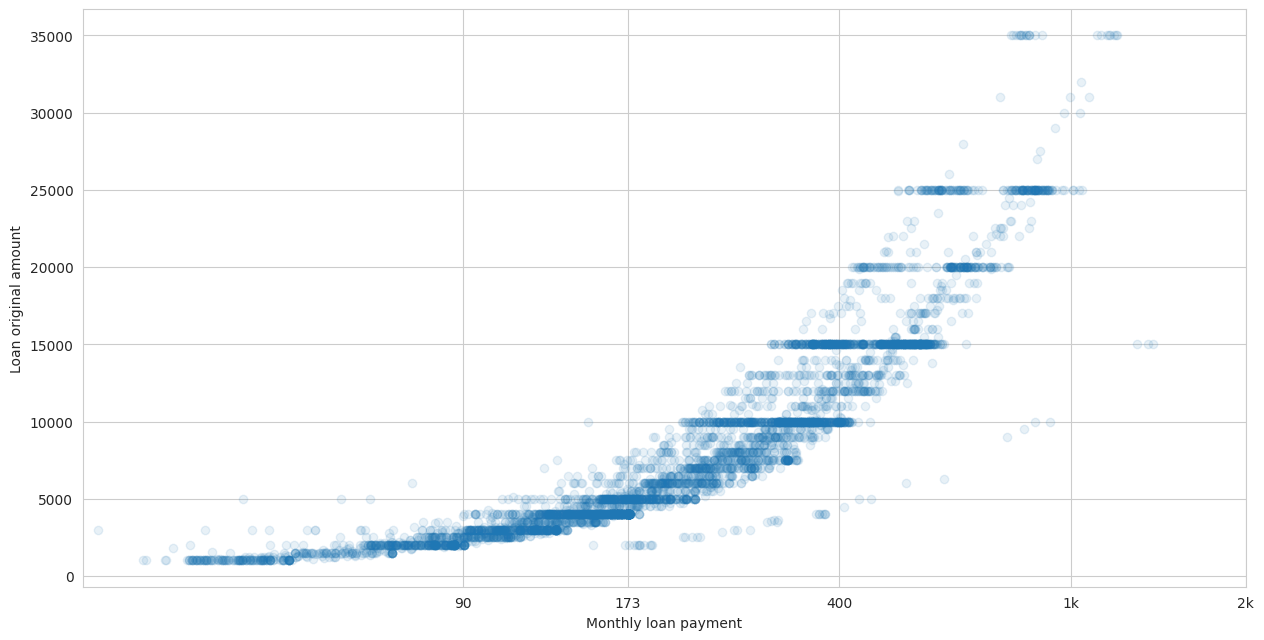

In [129]:
plt.scatter(data = df_samp, x = 'MonthlyLoanPayment', y = 'LoanOriginalAmount', alpha = 1/10)
plt.ylabel('Loan original amount')
plt.xlabel('Monthly loan payment')
plt.xlim((20,2000))
plt.xscale('log')
plt.xticks([90, 173, 400, 1e3, 2e3], [90, 173, 400, '1k', '2k']);

Next, let's look at relationships of categorical variables with the dependent variables.

### Categorical variables

<Figure size 1500x1000 with 0 Axes>

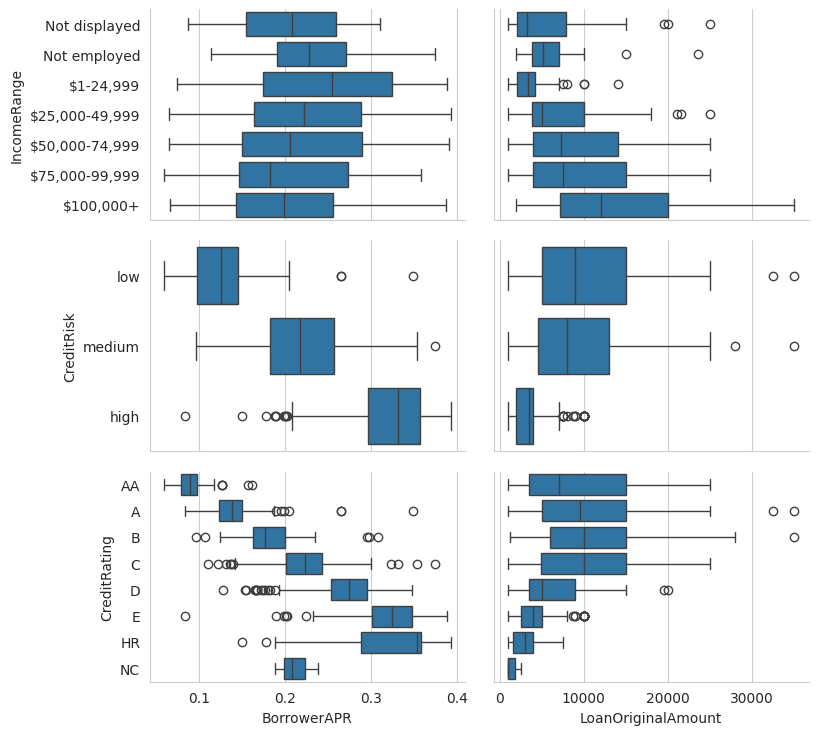

In [130]:
# sample of 2000
samples = np.random.choice(df.shape[0], 1000, replace = False)
df_samp = df.iloc[samples,:]

def boxgrid(x, y, **kwargs):
    """ Function for creating box plots with seaborn's PairGrid. """
    default_color = sns.color_palette()[0]
    sns.boxplot(x=x, y=y, color = default_color)

plt.figure(figsize = [15, 10])
g = sns.PairGrid(data = df_samp, x_vars = ['BorrowerAPR', 'LoanOriginalAmount'], y_vars = ordered_categoric_vars, aspect = 1.5)
g.map(boxgrid)
plt.show();

<ipython-input-131-0e3885b0ff74>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_samp, x="CreditRisk", y="BorrowerAPR", palette = 'RdYlBu_r')


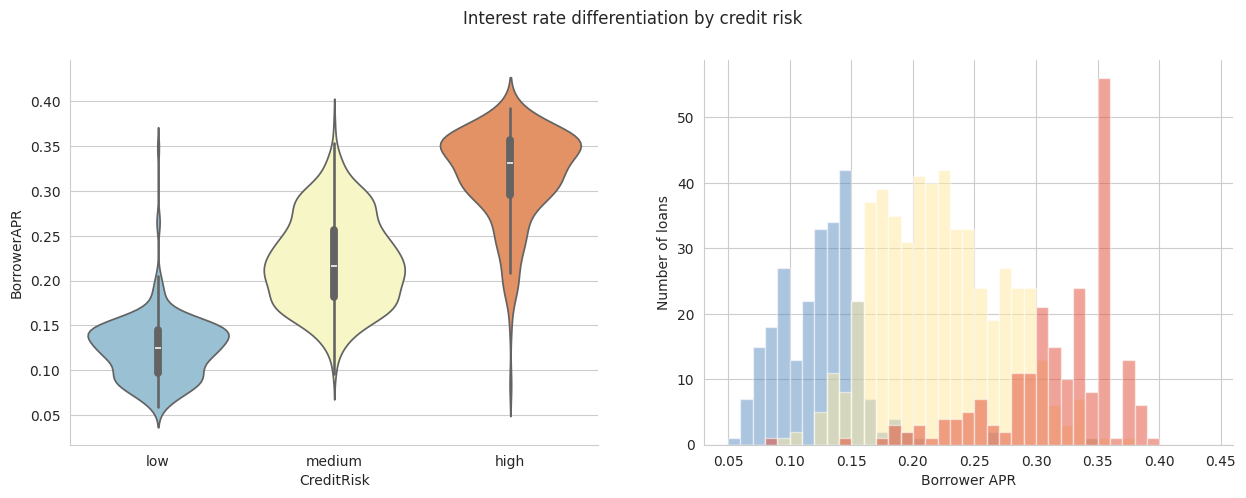

In [131]:
plt.figure(figsize = (15,5))
plt.suptitle('Interest rate differentiation by credit risk')

plt.subplot(1,2,1)
# subplots do not work when using catplot+violin kind
sns.violinplot(data=df_samp, x="CreditRisk", y="BorrowerAPR", palette = 'RdYlBu_r')
sns.despine()

plt.subplot(1,2,2)
bins = np.arange(0.05, 0.45,0.01)
plt.hist(df_samp[df_samp['CreditRisk']=='low']['BorrowerAPR'], alpha = 0.5, color = sns.color_palette('RdYlBu_r')[0], bins = bins)
plt.hist(df_samp[df_samp['CreditRisk']=='medium']['BorrowerAPR'], alpha = 0.5, color = sns.color_palette('RdYlBu_r')[3], bins = bins)
plt.hist(df_samp[df_samp['CreditRisk']=='high']['BorrowerAPR'], alpha = 0.5, color = sns.color_palette('RdYlBu_r')[5], bins = bins)
sns.despine()
plt.xlabel('Borrower APR')
plt.ylabel('Number of loans')

plt.show();

<Figure size 1000x2000 with 0 Axes>

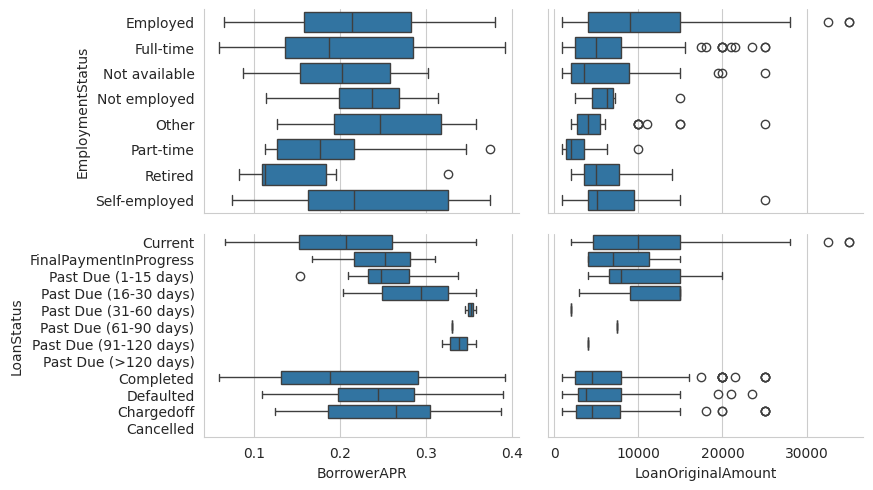

In [132]:
plt.figure(figsize = [10, 20])
g = sns.PairGrid(data = df_samp, x_vars = ['BorrowerAPR', 'LoanOriginalAmount'], y_vars = ['EmploymentStatus', 'LoanStatus'], aspect = 1.5)
g.map(boxgrid)
plt.show();

<Figure size 1000x1000 with 0 Axes>

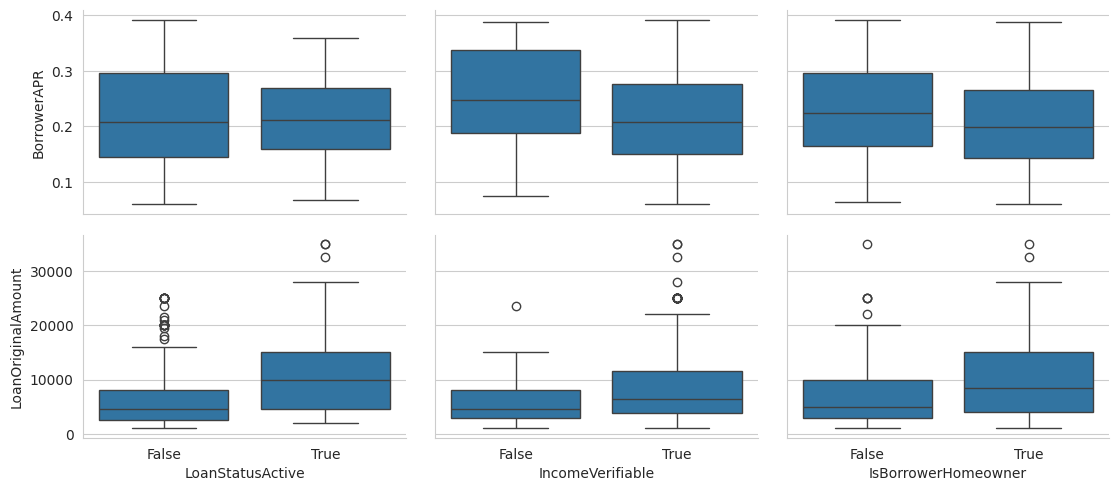

In [133]:
plt.figure(figsize = [10, 10])
g = sns.PairGrid(data = df_samp, y_vars = ['BorrowerAPR', 'LoanOriginalAmount'], x_vars = bool_vars, aspect = 1.5)
g.map(boxgrid)
plt.show();

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


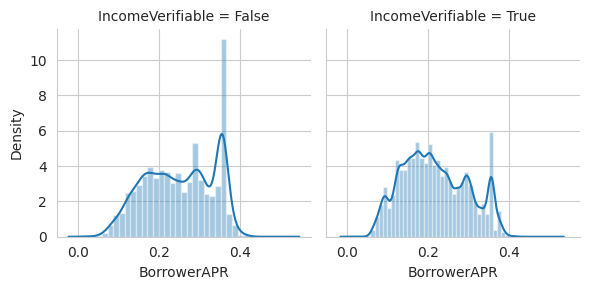

In [134]:
g = sns.FacetGrid(data = df, col = 'IncomeVerifiable')
g.map(sns.distplot, 'BorrowerAPR');

Borrowers with a verifiable income benefit from lower rate.

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


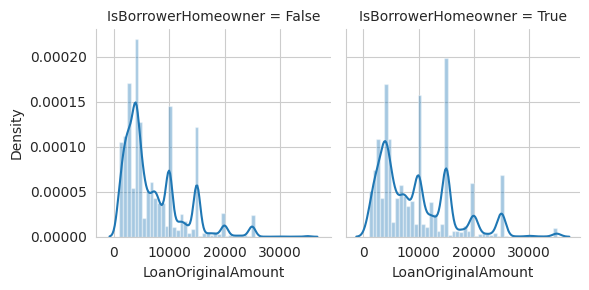

In [135]:
g = sns.FacetGrid(data = df, col = 'IsBorrowerHomeowner')
g.map(sns.distplot, 'LoanOriginalAmount');

Borrowers who own home get higher loan amounts.

<Figure size 1000x1000 with 0 Axes>

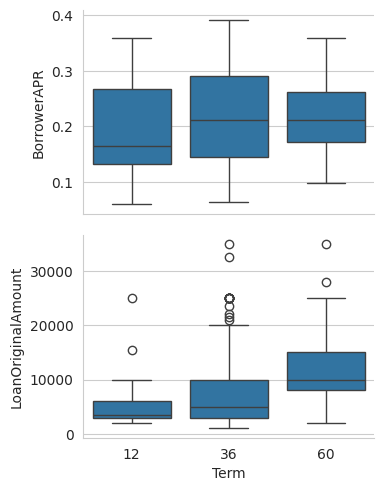

In [136]:
plt.figure(figsize = [10, 10])
g = sns.PairGrid(data = df_samp, y_vars = ['BorrowerAPR', 'LoanOriginalAmount'], x_vars = numeric_vars[-1:],aspect = 1.5)
g.map(boxgrid)
plt.show()

<ipython-input-137-51f2d893606a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g1 = sns.violinplot(data=df_samp, x="Term", y="LoanOriginalAmount", inner='stick', palette = 'pastel')
<ipython-input-137-51f2d893606a>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g2 = sns.barplot(data = df, x = 'Term', y = 'LoanOriginalAmount', palette = 'pastel')


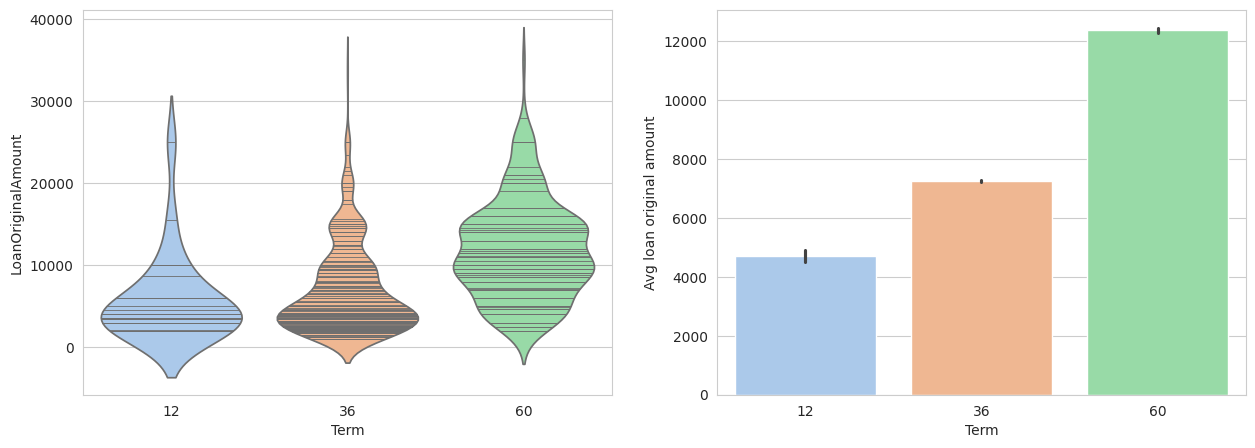

In [137]:
plt.figure(figsize = (15,5))
plt.subplot(1,2,1)
g1 = sns.violinplot(data=df_samp, x="Term", y="LoanOriginalAmount", inner='stick', palette = 'pastel')

plt.subplot(1,2,2)
g2 = sns.barplot(data = df, x = 'Term', y = 'LoanOriginalAmount', palette = 'pastel')
plt.ylabel('Avg loan original amount')
plt.show();

<ipython-input-138-02be872b5590>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x="Term", y="BorrowerAPR", kind="violin", inner='stick', data=df_samp, palette = 'pastel');


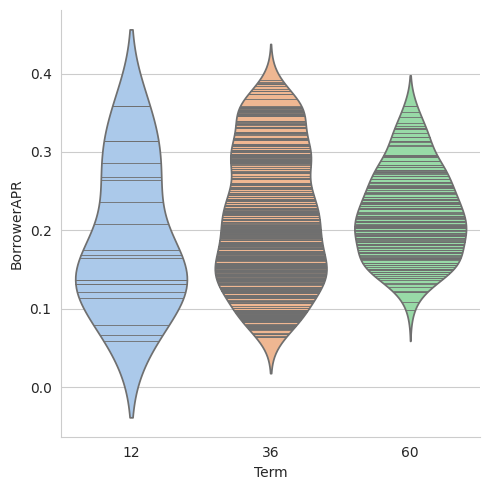

In [138]:
sns.catplot(x="Term", y="BorrowerAPR", kind="violin", inner='stick', data=df_samp, palette = 'pastel');

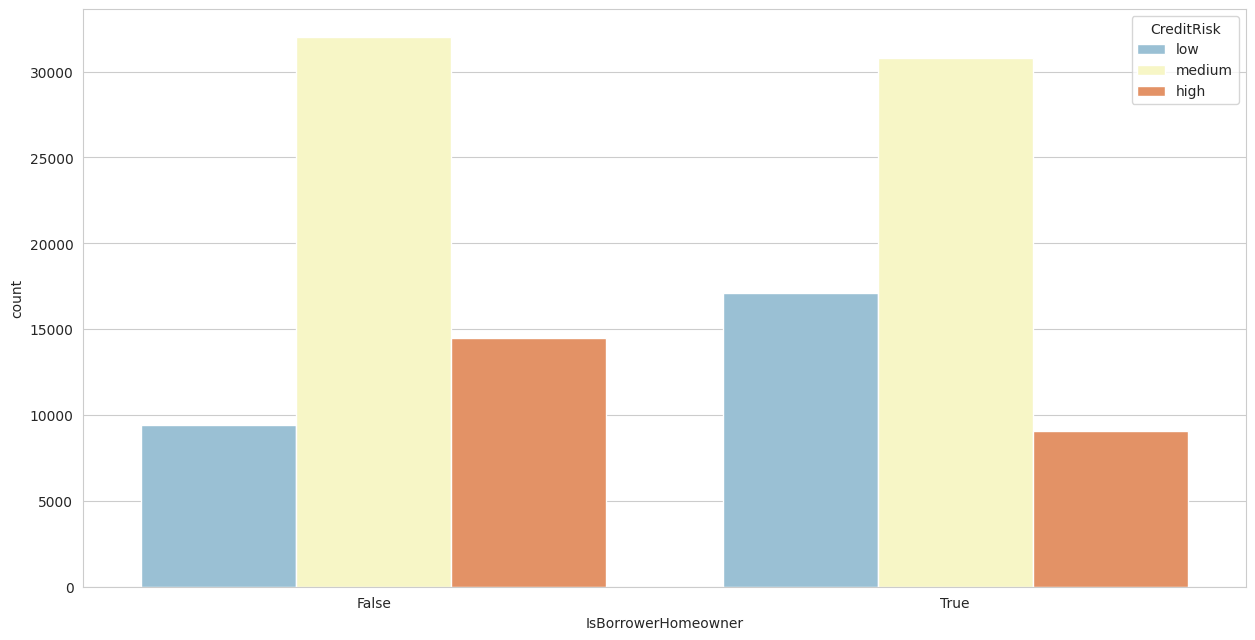

In [139]:
sns.countplot(data = df, x = 'IsBorrowerHomeowner', hue = 'CreditRisk', palette = 'RdYlBu_r');

There are more high risk borrowers among those who do not own a house.

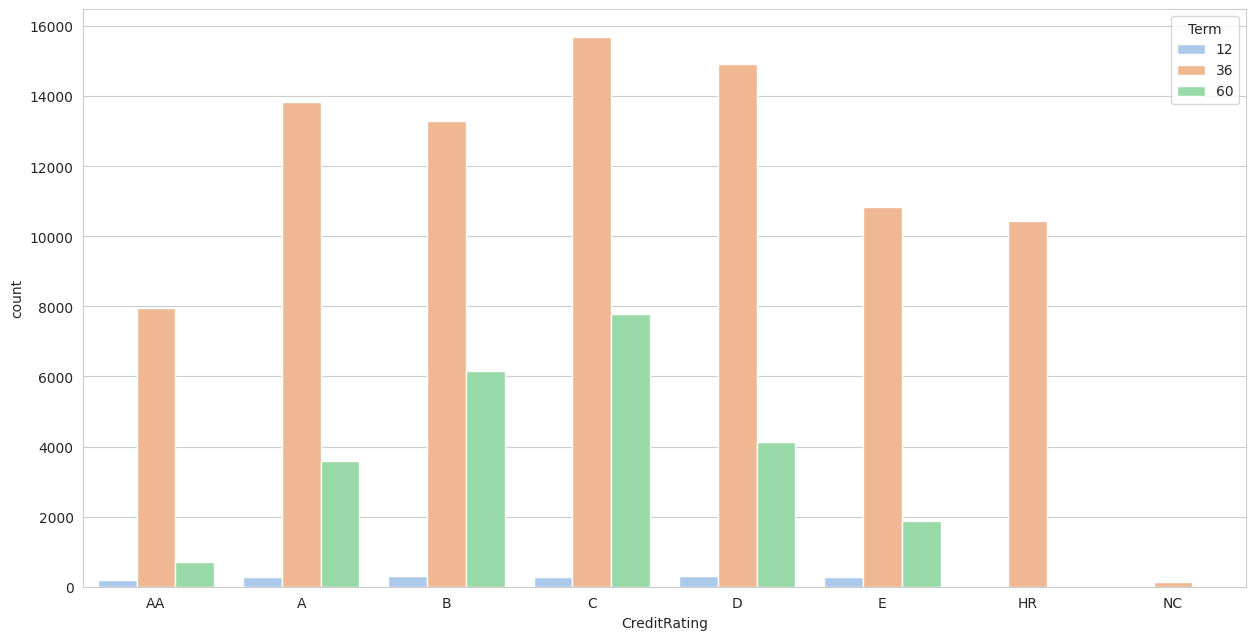

In [140]:
# most loans are for 36m and the most common rating is C
sns.countplot(data = df, x = 'CreditRating', hue = 'Term', palette = 'pastel');

The above box plots reveal the following (none of which is actually too surprising and it is what we would expect from a reasonable lending strategy):
* Interest rate decreases and borrowed amount increases with higher income of the borrower
* The more risky the loan, the higher the interest rate and the lower the borrowed amount
* Loans with a higher interest default more (active loans: past due statuses vs. current loans, non-active loans: defaulted/chargedoff vs. completed loans)
* Active loans are for larger loan amounts than non-active loans
* Home owners pay a lower interest and borrow higher amounts
* Unemployed borrowers pay the highest interest
* Employed borrowers borrow the highest amounts
* Higher loan amounts are borrowed for longer term

Let's very briefly also look at other numeric vars than BorrowerAPR and LoanOriginalAmount:

<Figure size 1000x1000 with 0 Axes>

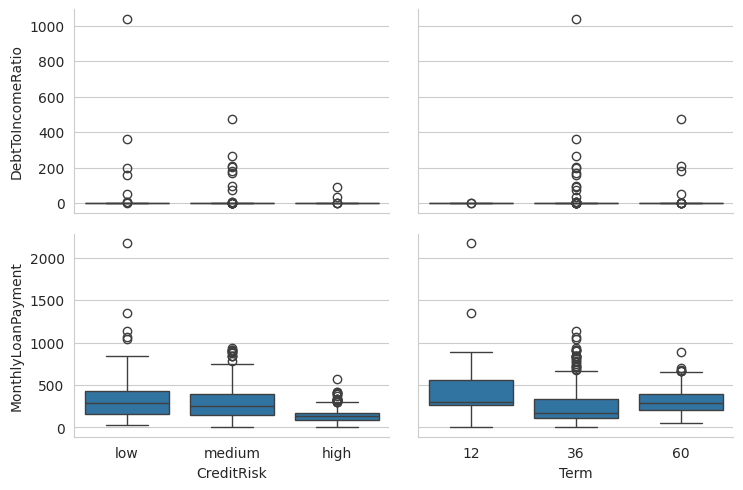

In [141]:
plt.figure(figsize = [10, 10])
g = sns.PairGrid(data = df_samp, y_vars = ['DebtToIncomeRatio', 'MonthlyLoanPayment'], x_vars = ['CreditRisk', 'Term'], aspect = 1.5)
g.map(boxgrid)
plt.show()

The squeezed debt to income ration box plots tell us that there are many outliers in the data with very high ratios.<br>
High risk borrowers have lower monthly payments compared to other risk categories.

### Other categorical variables

<Figure size 1000x1500 with 0 Axes>

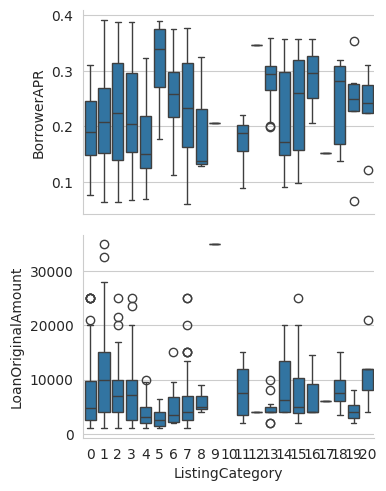

In [142]:
plt.figure(figsize = [10, 15])
g = sns.PairGrid(data = df_samp, y_vars = ['BorrowerAPR', 'LoanOriginalAmount'], x_vars = 'ListingCategory',aspect = 1.5)
g.map(boxgrid)
plt.xticks(rotation = 0)
plt.show();

Many of the listing category groups are small, hence the long whiskers.<br>

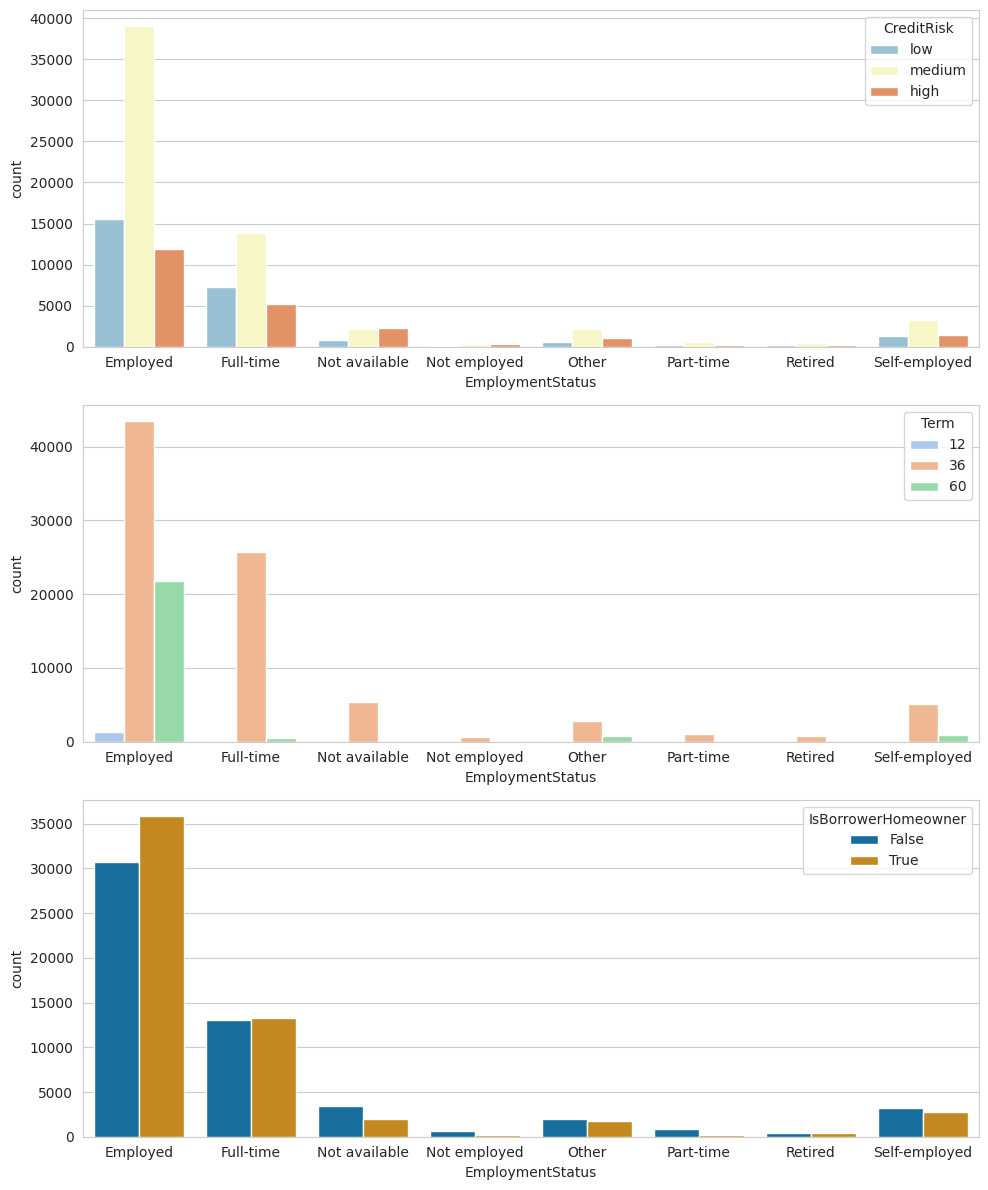

In [143]:
plt.figure(figsize = [10,12])

plt.subplot(3,1,1)
sns.countplot(data = df, x = 'EmploymentStatus', hue = 'CreditRisk', palette = 'RdYlBu_r')

plt.subplot(3,1,2)
sns.countplot(data = df, x = 'EmploymentStatus', hue = 'Term', palette = 'pastel')

plt.subplot(3,1,3)
sns.countplot(data = df, x = 'EmploymentStatus', hue = 'IsBorrowerHomeowner', palette = 'colorblind')

plt.tight_layout();

* employed borrowers get loans with term 60 much more frequently than other groups
* employed borrowers are the only group with strongly more home-owners among them

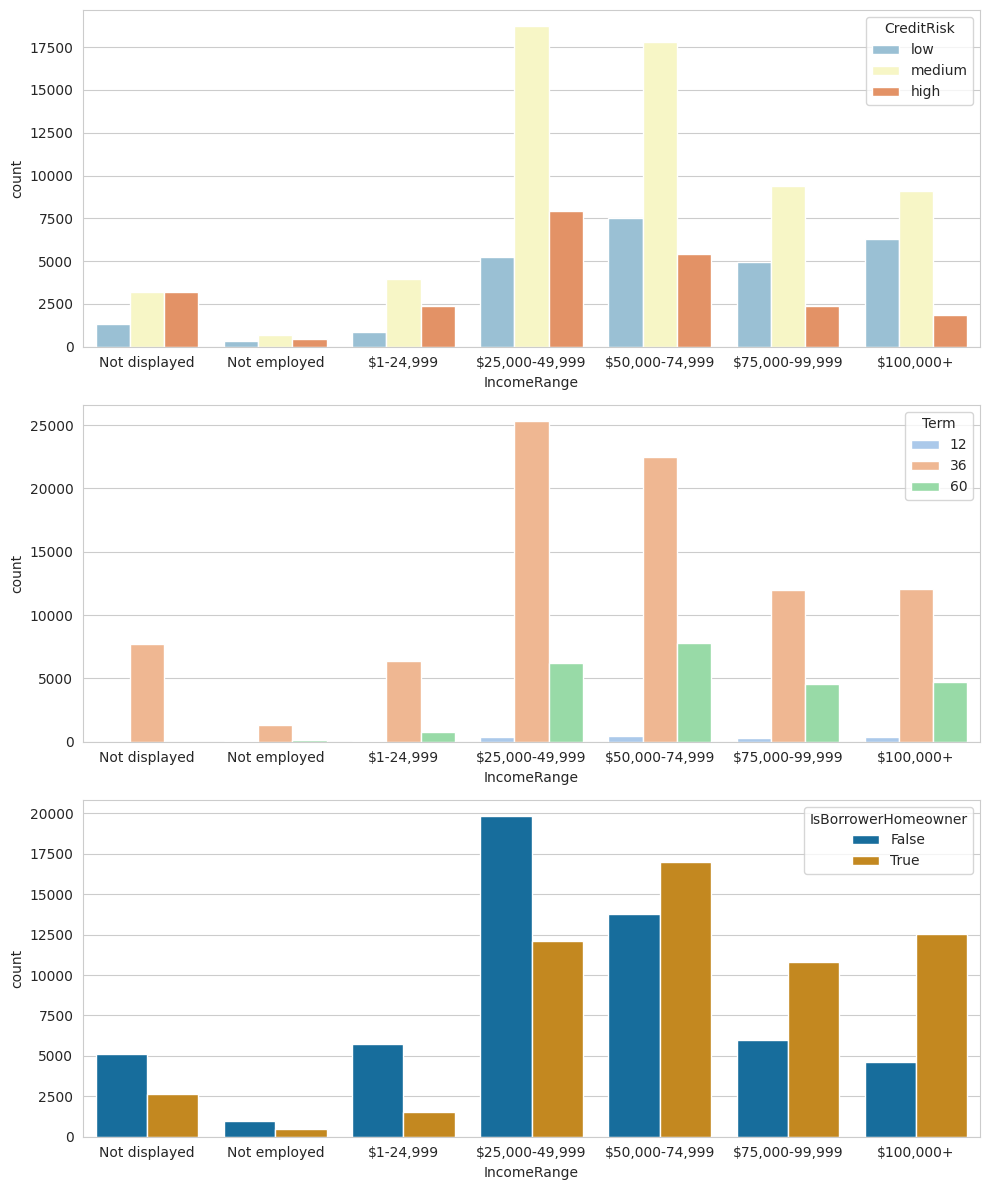

In [144]:
plt.figure(figsize = [10,12])

plt.subplot(3,1,1)
sns.countplot(data = df, x = 'IncomeRange', hue = 'CreditRisk', palette = 'RdYlBu_r')

plt.subplot(3,1,2)
sns.countplot(data = df, x = 'IncomeRange', hue = 'Term', palette = 'pastel')

plt.subplot(3,1,3)
sns.countplot(data = df, x = 'IncomeRange', hue = 'IsBorrowerHomeowner', palette = 'colorblind')

plt.tight_layout();

* there are high risk borrowers even among the high earners
* but the share of low risk borrowers among the top earners is of course higher than in other income groups

### Development in time

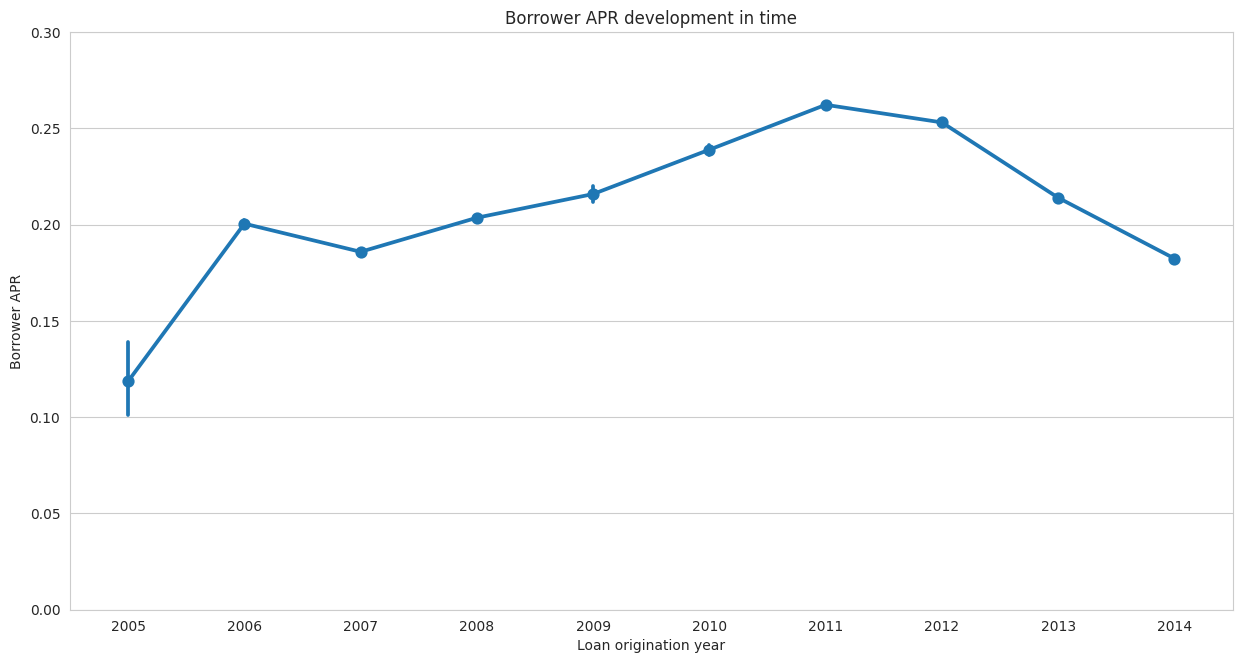

In [145]:
sns.pointplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'BorrowerAPR')
plt.title('Borrower APR development in time')
plt.ylabel('Borrower APR')
plt.xlabel('Loan origination year')
plt.ylim((0,0.3));

* average interest rate is in decline since 2012

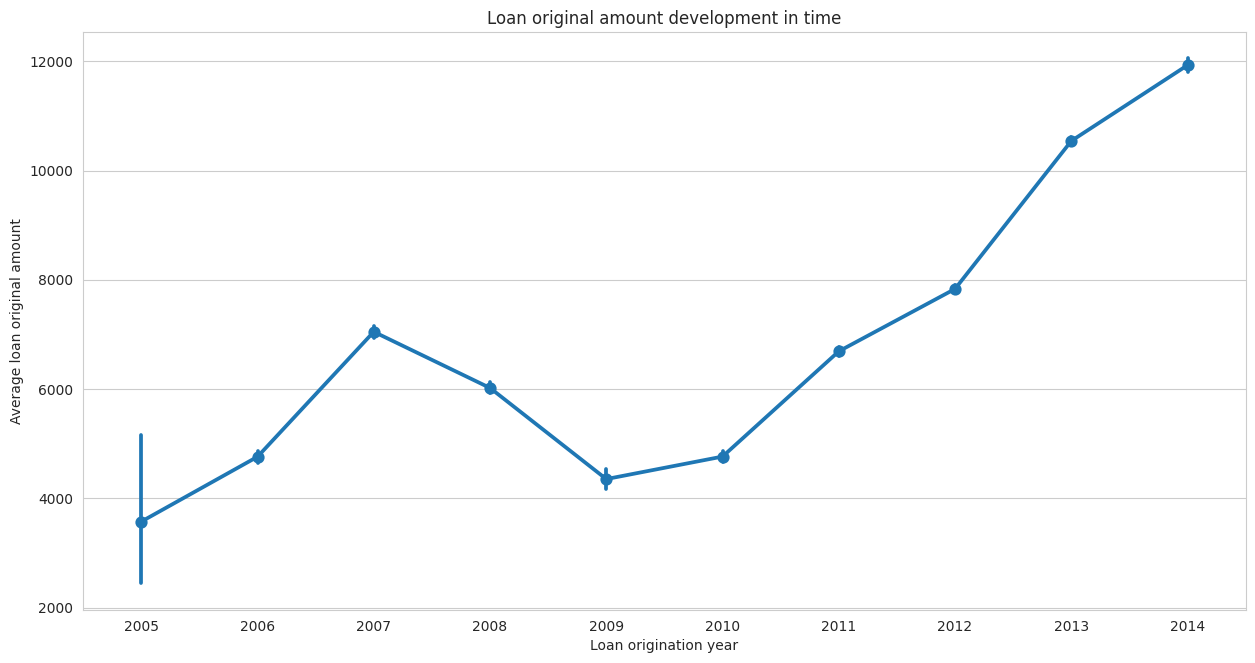

In [146]:
sns.pointplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'LoanOriginalAmount')
plt.title('Loan original amount development in time')
plt.ylabel('Average loan original amount')
plt.xlabel('Loan origination year');

* average loan amoounts are increasing since 2010

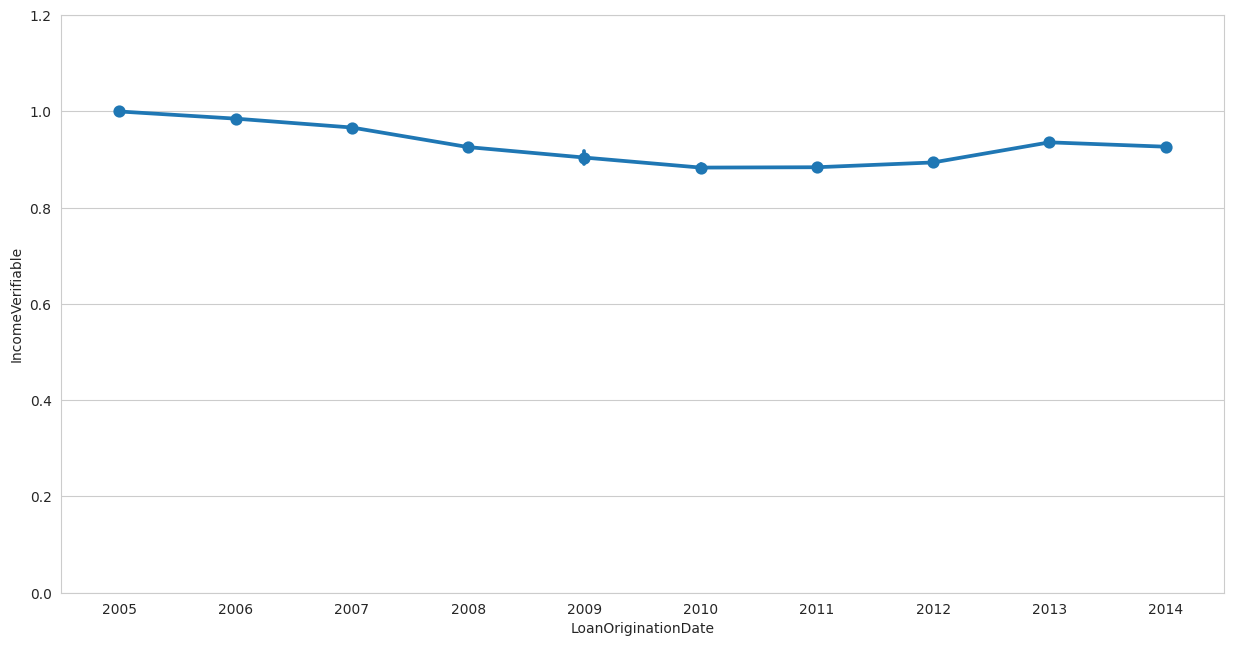

In [147]:
sns.pointplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'IncomeVerifiable')
plt.ylim((0,1.2));

* share of borrowers with verified income is slightly decreasing in time

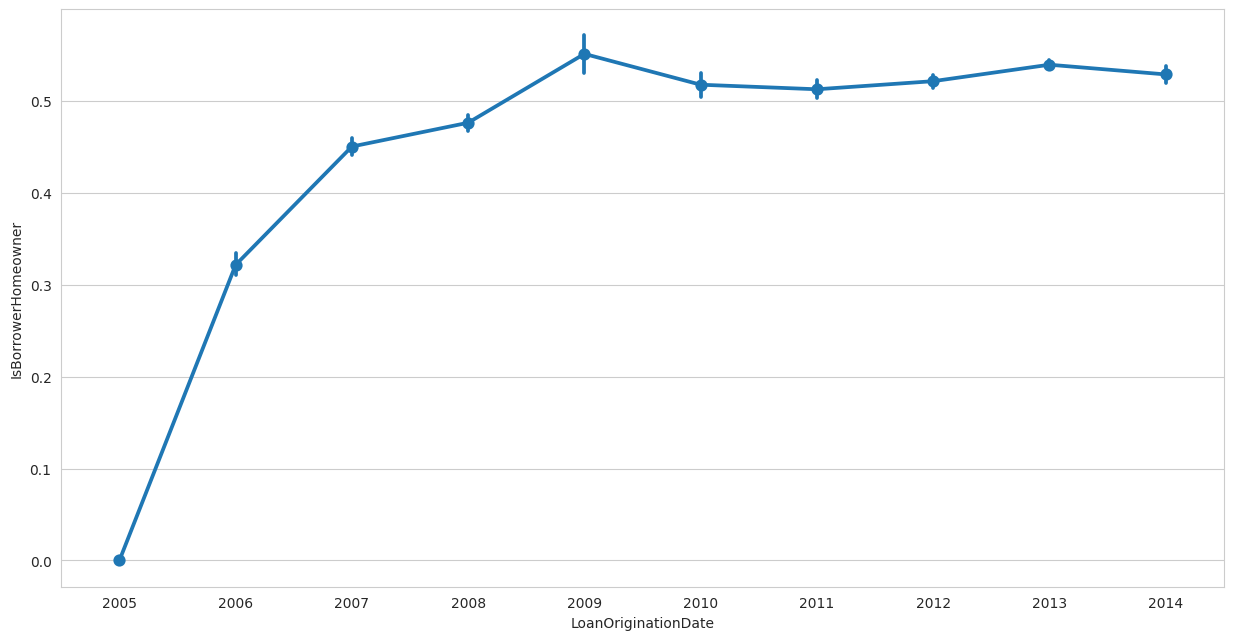

In [148]:
sns.pointplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'IsBorrowerHomeowner');

* share of borrowers who own a home is quite steady since 2010

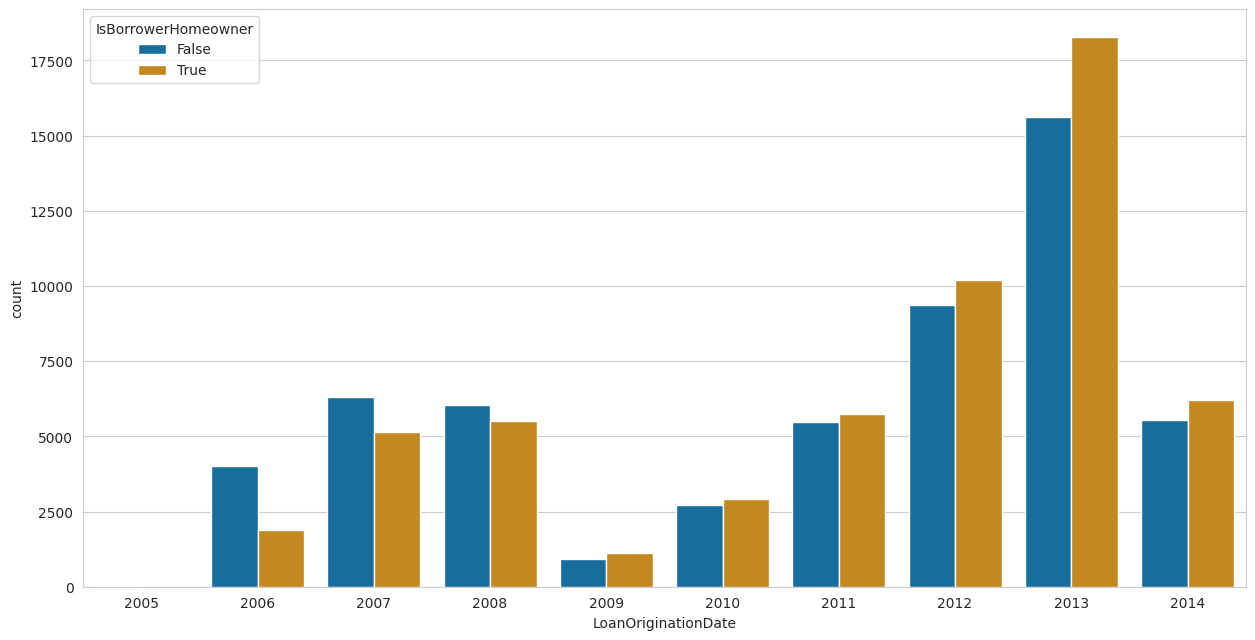

In [149]:
sns.countplot(data = df, x = df['LoanOriginationDate'].dt.year, hue = 'IsBorrowerHomeowner', palette = 'colorblind');

* the same information can be shown also this way

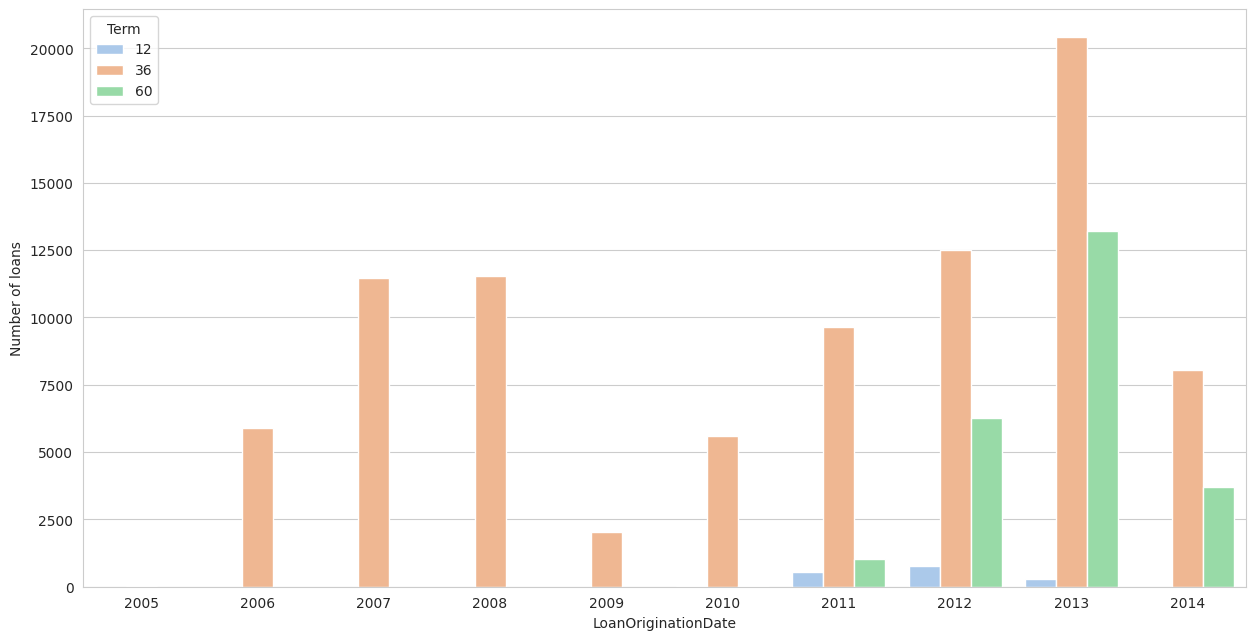

In [150]:
sns.countplot(data = df, x = df['LoanOriginationDate'].dt.year, hue = 'Term', palette = 'pastel')
plt.ylabel('Number of loans')
plt.legend(title = 'Term', loc = 'upper left');

* 60m term was introduced first in 2010

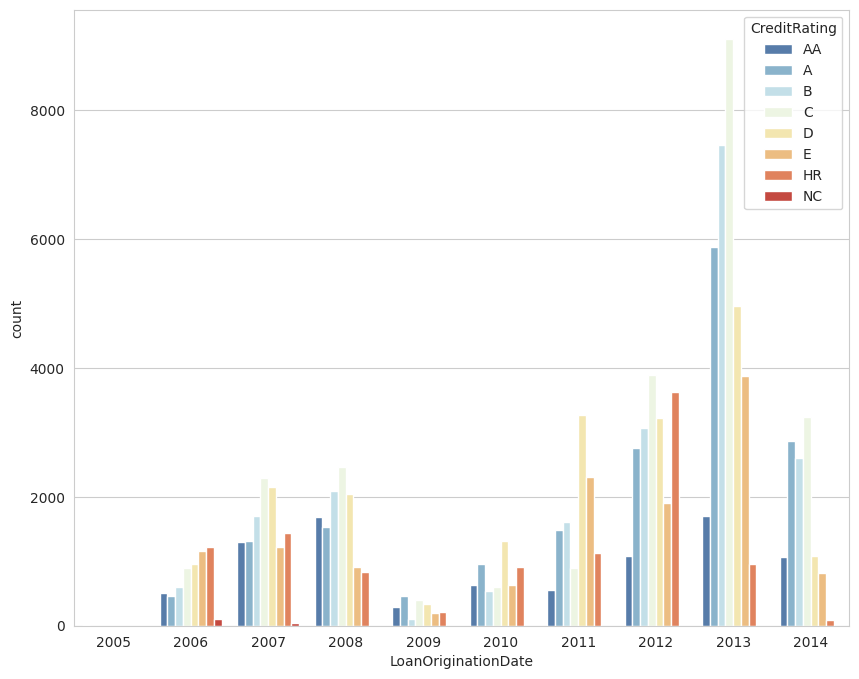

In [151]:
plt.figure(figsize = [10,8])
sns.countplot(data = df, x = df['LoanOriginationDate'].dt.year, hue = 'CreditRating', palette = 'RdYlBu_r');

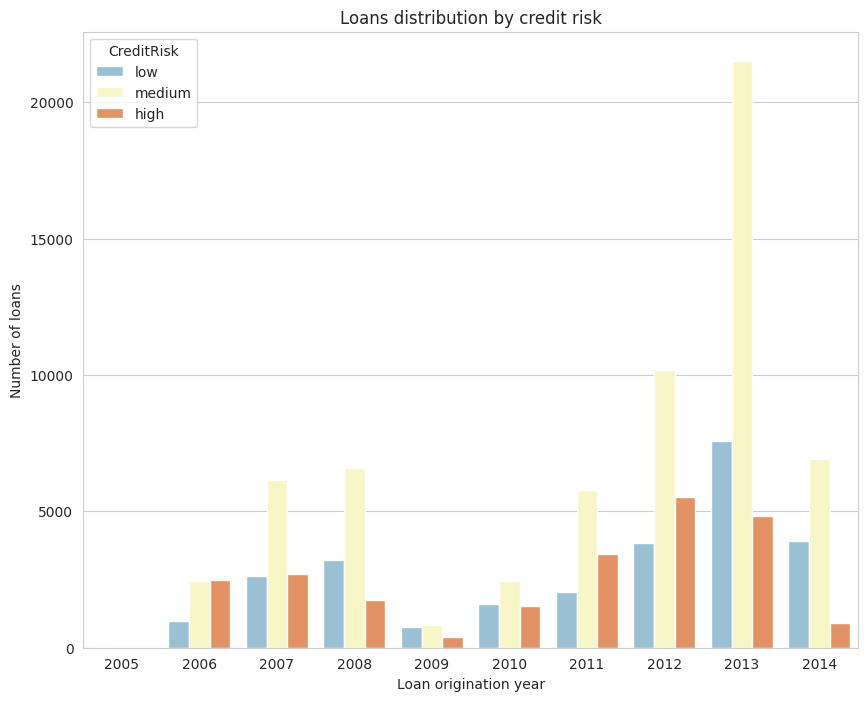

In [152]:
plt.figure(figsize = [10,8])
sns.countplot(data = df, x = df['LoanOriginationDate'].dt.year, hue = 'CreditRisk', palette = 'RdYlBu_r')
plt.xlabel('Loan origination year')
plt.ylabel('Number of loans')
plt.title('Loans distribution by credit risk');

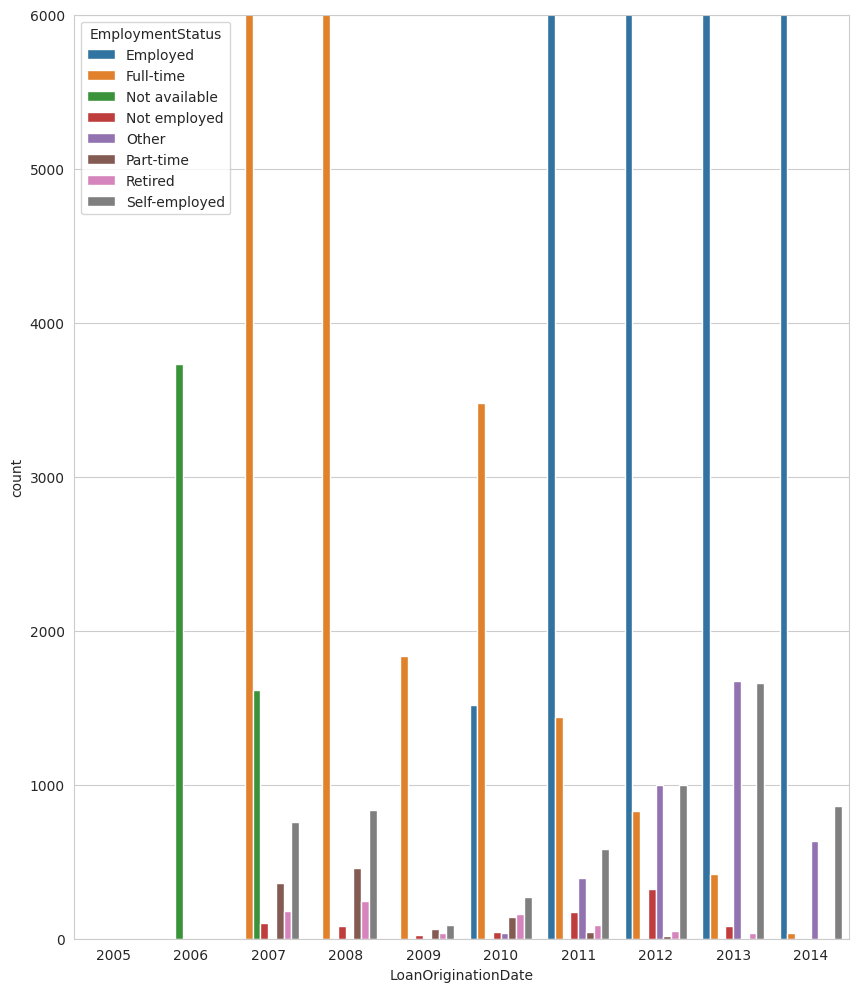

In [153]:
plt.figure(figsize = [10,12])
sns.countplot(data = df, x = df['LoanOriginationDate'].dt.year, hue = 'EmploymentStatus')
plt.ylim((0,6000));

* employed category was introduced in 2010, apparently as a successor of full-time category, but the full-time number is decreasing gradually in the following years
* not available category was only in 2006 and 2007

### Observations

**Relationships Observed:**

Borrower APR is negatively correlated with the loan original amount, monthly loan payment, and credit score range lower, which makes sense. Borrowers who can borrow larger amounts are likely more solvent, thus getting lower interest rates and having higher credit scores, allowing them to afford higher monthly payments. The interconnectedness of the main features is also shown by the positive correlation between loan original amount, monthly loan payment, and credit score.

The credit rating clearly separates borrowers into different interest rate groups, which is what we would expect from a reasonable lending business. High-risk borrowers, for example, get loans for much lower amounts than medium or low-risk borrowers.

**Interesting Relationships Between Other Features:**

- Higher income borrowers and homeowners borrow higher amounts for lower rates compared to lower-income borrowers.
- Loans with higher interest rates default more often.
- Unemployed borrowers pay the highest interest among all employment statuses.
- Higher loan amounts are borrowed for longer terms.


## Multivariate Exploration

This section will build on previous findings and combine multiple variables to see how they interact.<br>
A few sections will follow, each focusing on one variable and its relationship with others.
### Credit risk

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


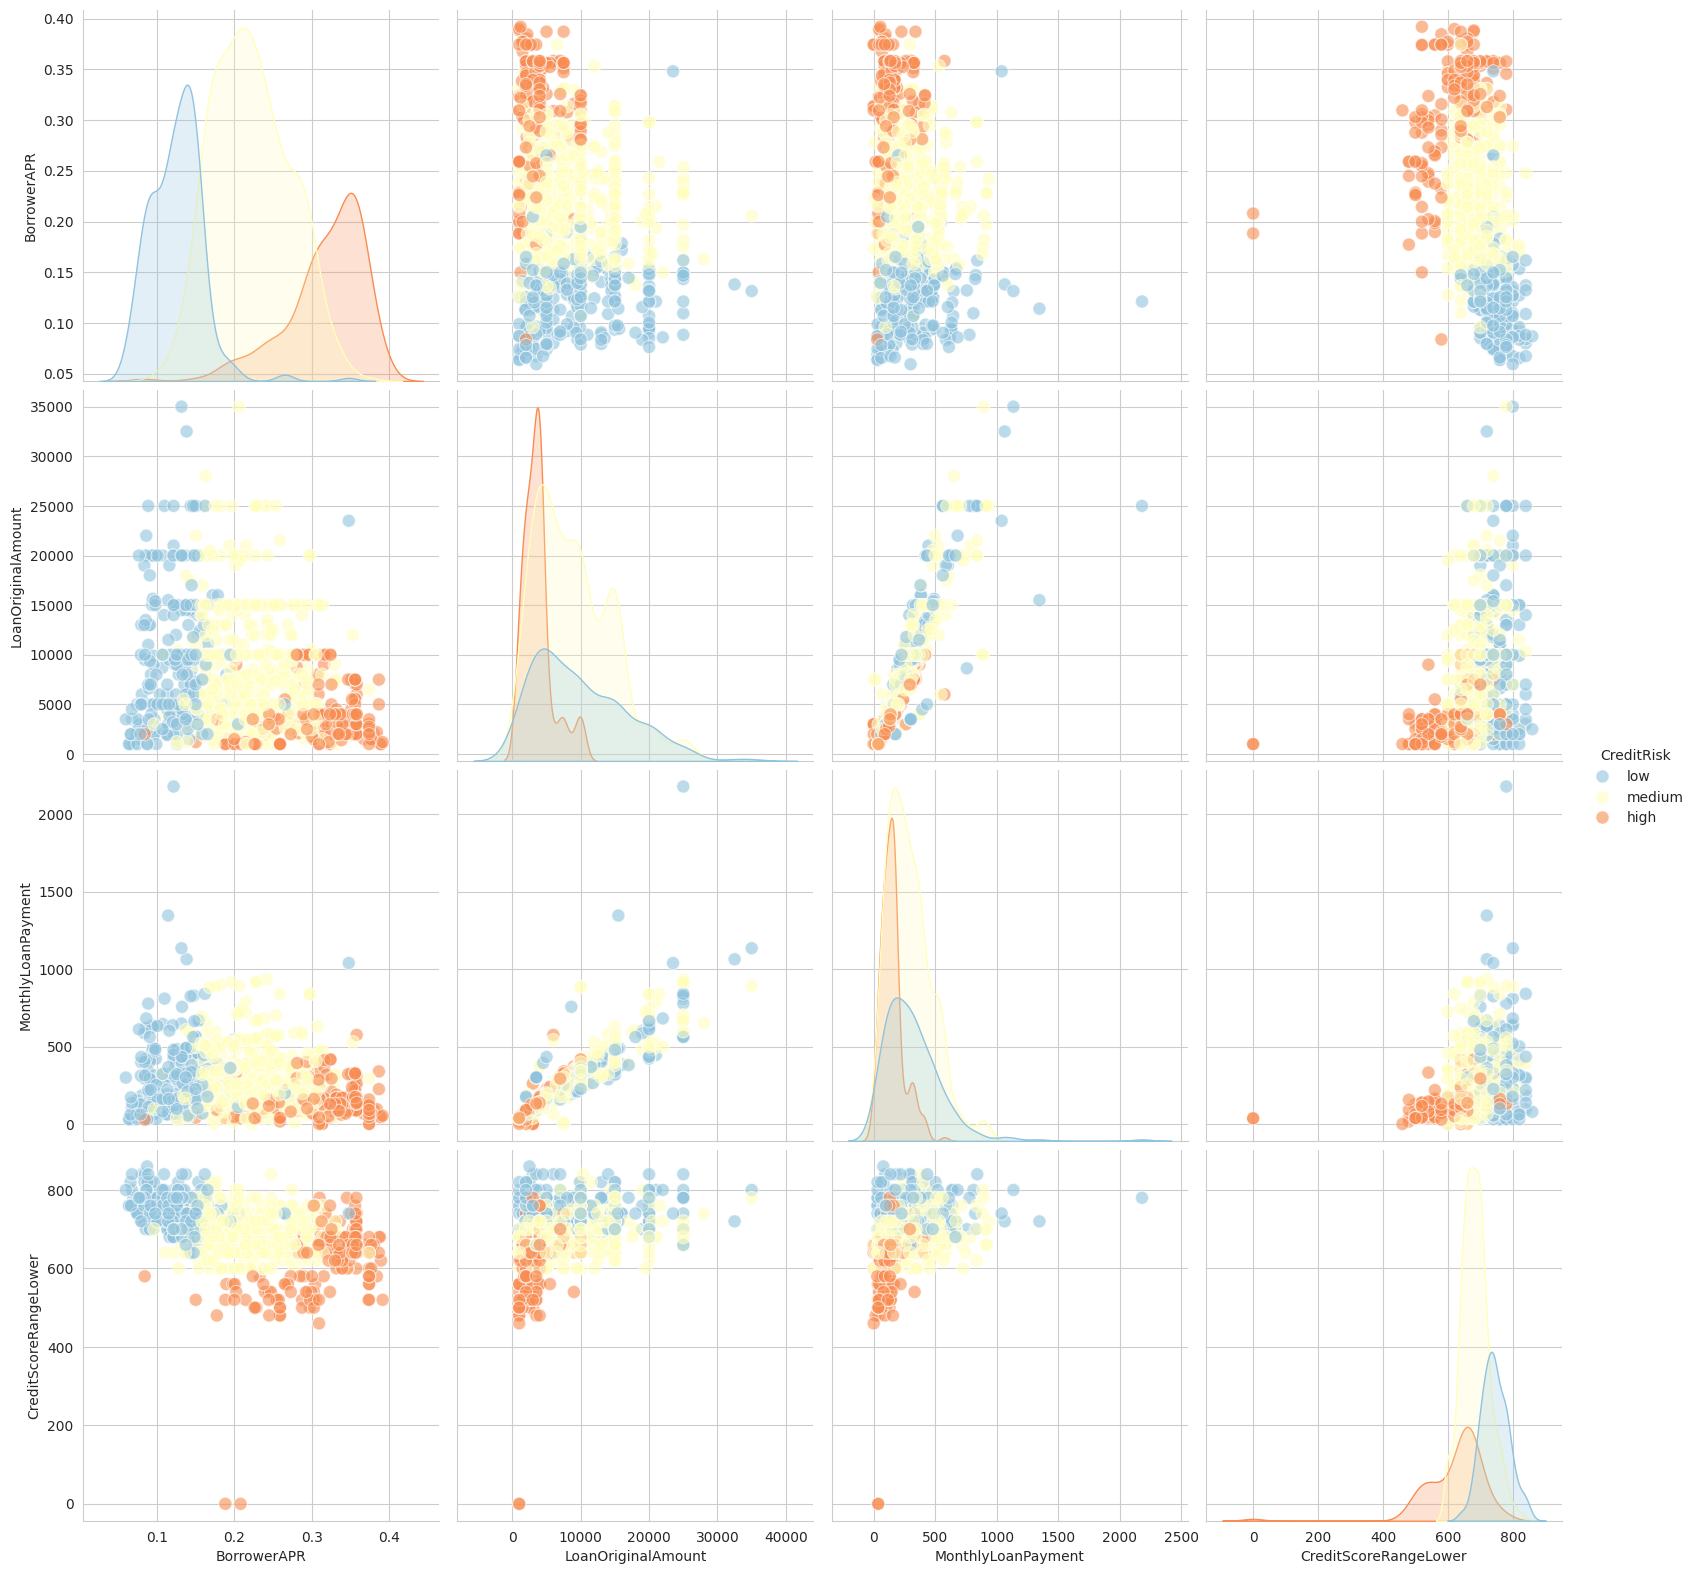

In [154]:
# Pair plot colored by credit risk
sns.pairplot(df_samp,
             vars = ['BorrowerAPR', 'LoanOriginalAmount', 'MonthlyLoanPayment', 'CreditScoreRangeLower'],
             hue = 'CreditRisk', diag_kind = 'kde', palette = 'RdYlBu_r',
             plot_kws = {'alpha': 0.6, 's': 90},
             size = 4);

Credit risk groups are clearly separated in our featured variables.

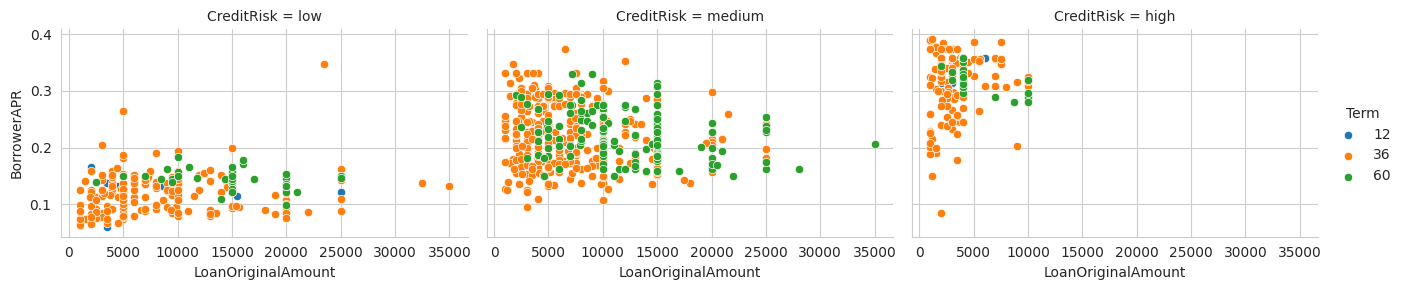

In [155]:
g = sns.FacetGrid(data = df_samp, col = 'CreditRisk', hue = 'Term',aspect = 1.5)
g.map(sns.scatterplot, 'LoanOriginalAmount', 'BorrowerAPR')
g.add_legend()
plt.show();

The rising interest rate among risk groups is visible, as well as the 60m loans having a rather higher interest rate than 36m loans on average in all risk groups.

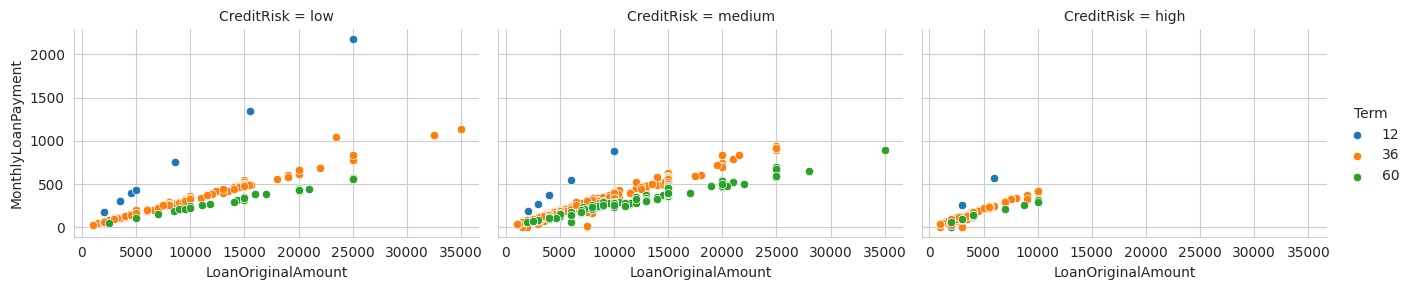

In [156]:
g = sns.FacetGrid(data = df_samp, col = 'CreditRisk', hue = 'Term', aspect = 1.5)
g.map(sns.scatterplot, 'LoanOriginalAmount', 'MonthlyLoanPayment')
g.add_legend()
plt.show()

It is clear that for the same loan amount, the monthly payments differ mostly by the term of the loan.<br>
It shows also that we have most borrowers in the medium risk category and that high risk borrowers cannot borrow very high loan amounts.

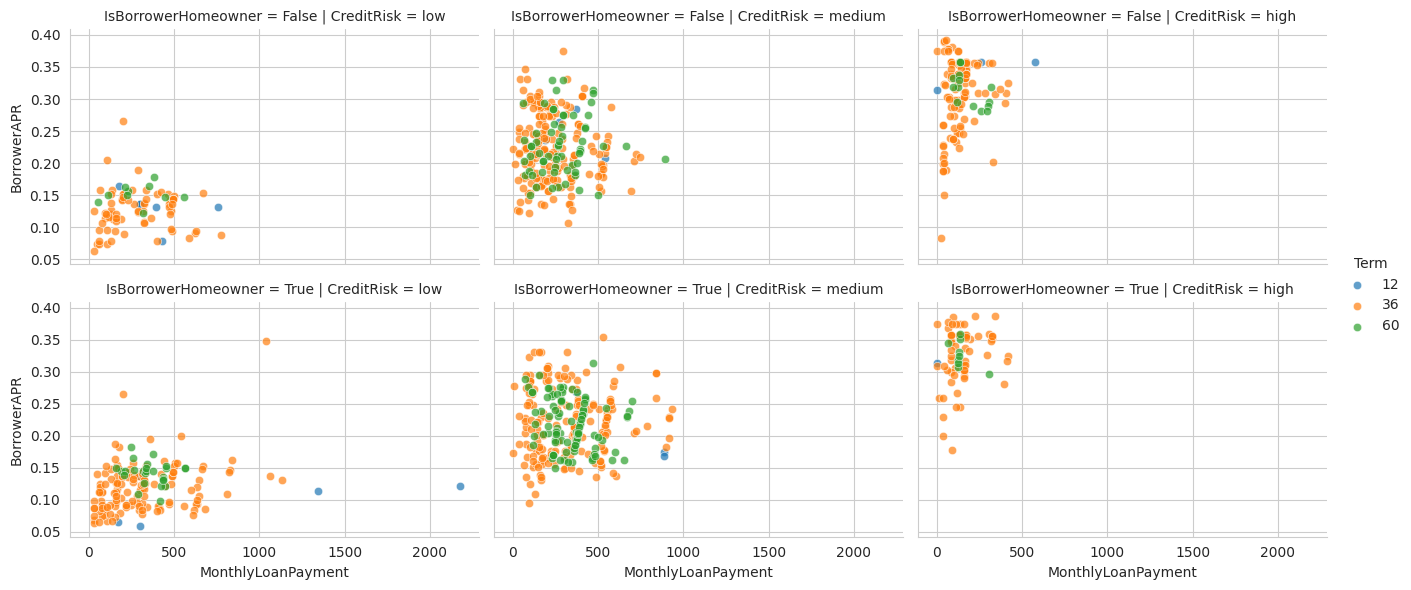

In [157]:
g = sns.FacetGrid(data = df_samp, col = 'CreditRisk', row = 'IsBorrowerHomeowner', hue = 'Term', aspect = 1.5)
g.map(sns.scatterplot, 'MonthlyLoanPayment', 'BorrowerAPR', alpha = 0.7)
g.add_legend()
plt.show();

Owning a home does not seem to make a huge difference in interest rate and monthly payments when separating by both credit risk and loan term.<br>
However, we can see that in low risk group, there are more homeowners that non-home owners, whereas the opposite is true for the high risk group.

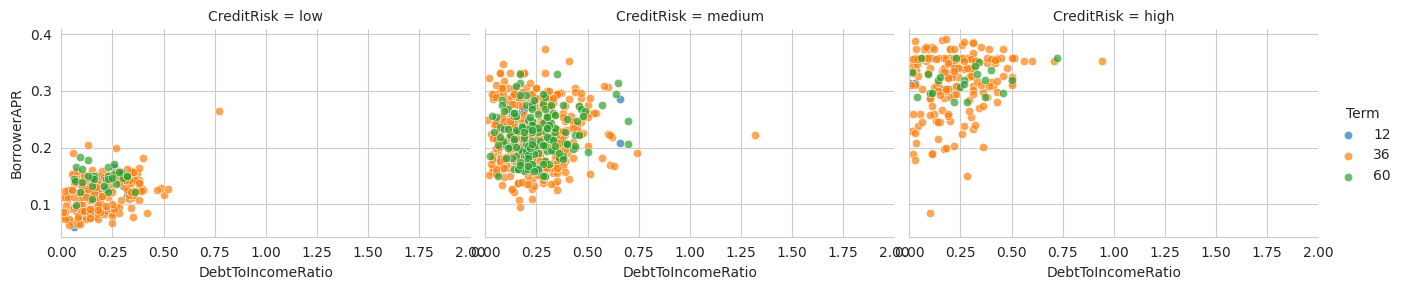

In [158]:
# it is interesting how the 60m loans appear in the center of distributions
g = sns.FacetGrid(data = df_samp, col = 'CreditRisk', hue = 'Term', aspect = 1.5)
g.map(sns.scatterplot, 'DebtToIncomeRatio', 'BorrowerAPR', alpha = 0.7)
plt.xlim((0,2))
g.add_legend()
plt.show();

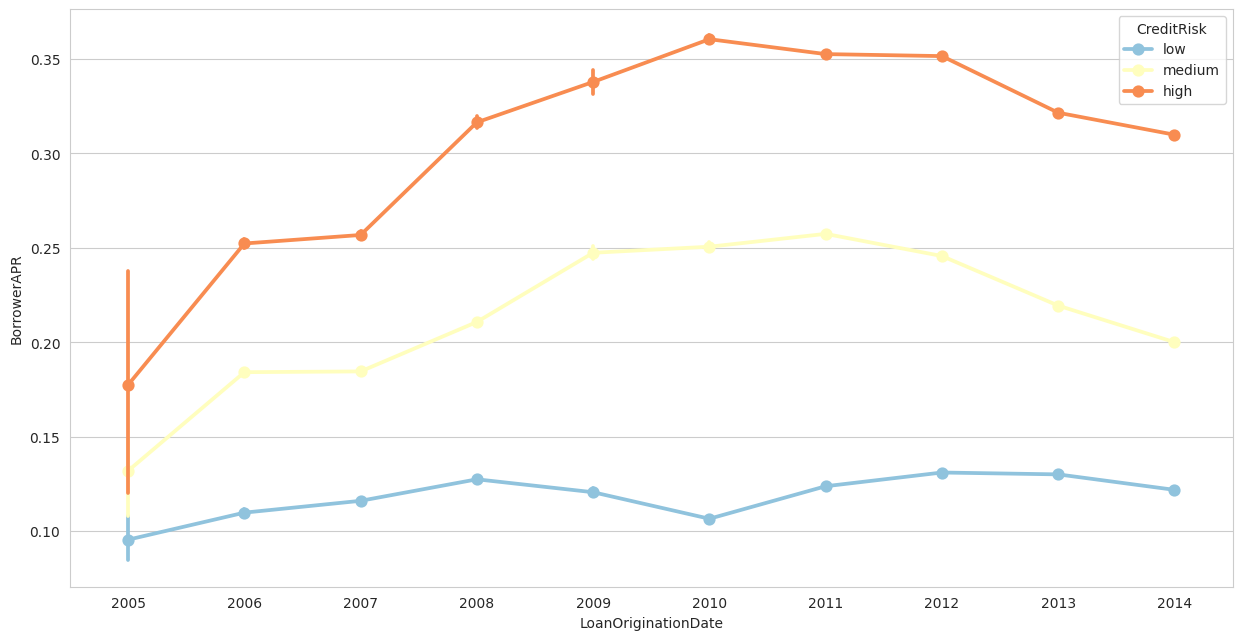

In [159]:
sns.pointplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'BorrowerAPR', hue = 'CreditRisk', palette = 'RdYlBu_r');

In [160]:
df_rate_dev = df.groupby(['LoanYear', 'CreditRisk'])['BorrowerAPR'].mean()
df_rate_dev = pd.DataFrame(df_rate_dev) # created with multiindex
df_rate_dev.reset_index(inplace=True)

In [161]:
fig = px.bar(df_rate_dev,
             y="CreditRisk",
             x="BorrowerAPR",
             animation_frame="LoanYear",
             animation_group="BorrowerAPR",
             orientation='h',
             color="CreditRisk",
             range_x=[0, df_rate_dev.BorrowerAPR.max()+0.05],
             color_continuous_scale=px.colors.diverging.RdYlBu)
# improve aesthetics (size, grids etc.)
fig.update_layout(width=700,
                  height=500,
                  xaxis_showgrid=False,
                  yaxis_showgrid=False,
                  title_text='Evolution of Borrower APR by credit risk',
                  showlegend=False)

fig.update_xaxes(title_text='Average Borrower APR')
fig.update_yaxes(title_text='Credit Risk')
fig.show()

The interest rate differentiation for the risk group is very clear and quite large.<br>
The average interest rate is declining for high and medium risk groups in the last couple of years, but this is not the case for low risk group.

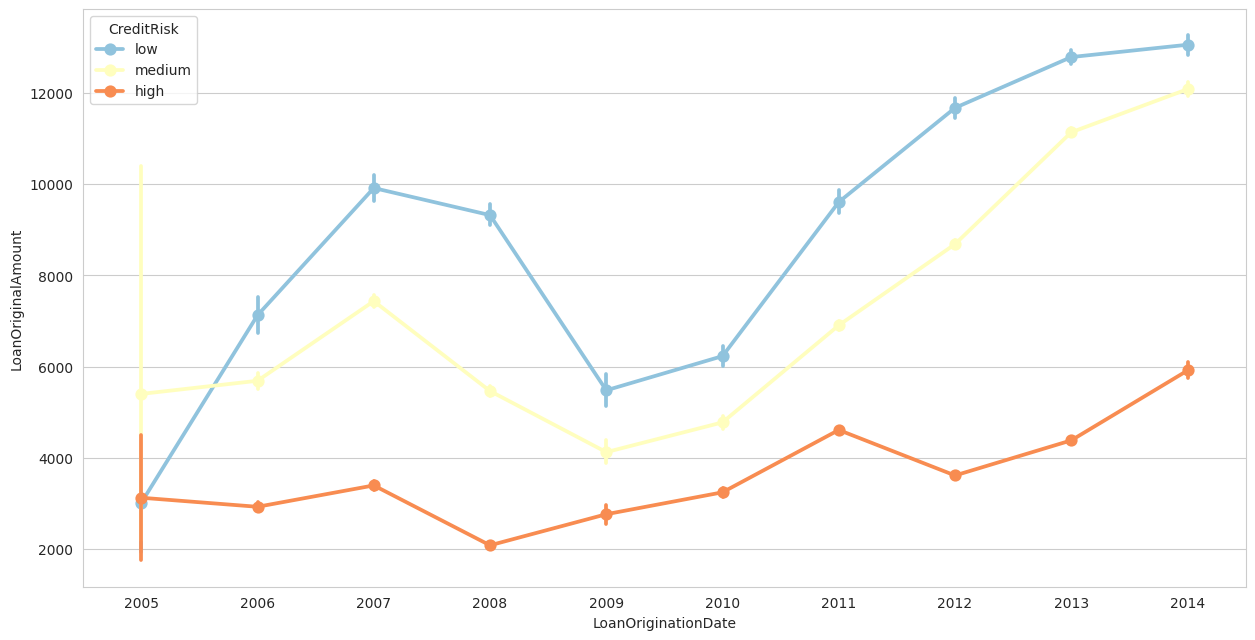

In [162]:
sns.pointplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'LoanOriginalAmount', hue = 'CreditRisk', palette = 'RdYlBu_r');

* the riskier the borrower, the lower the amount which he can borrow and this holds true over time

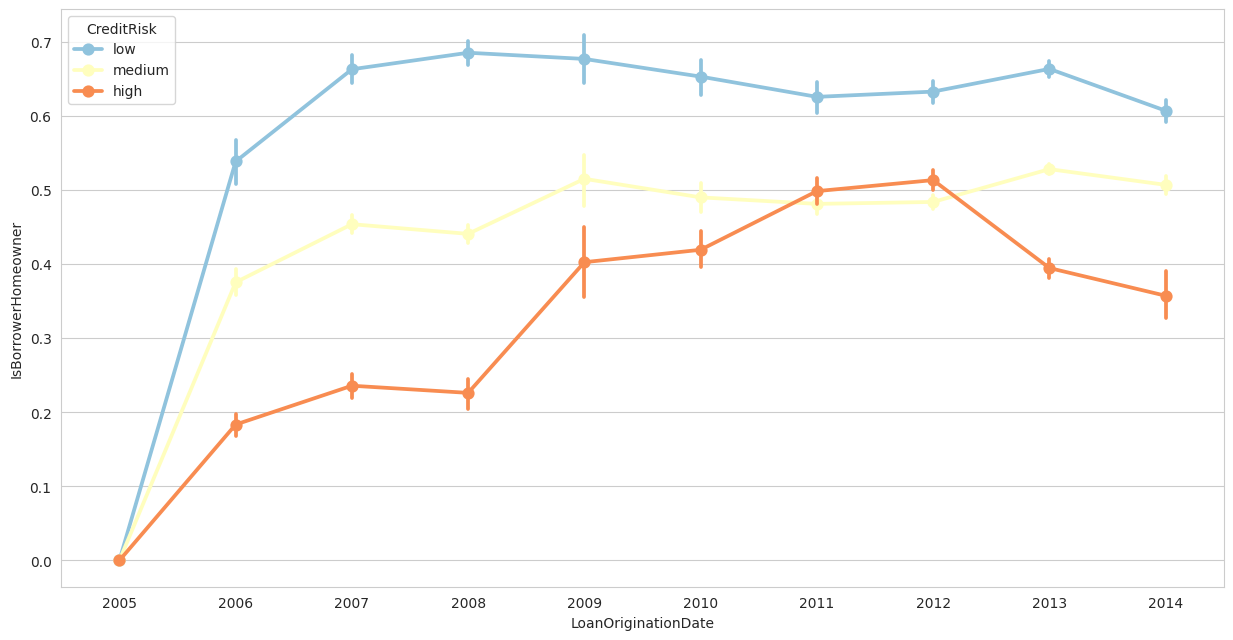

In [163]:
sns.pointplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'IsBorrowerHomeowner', hue = 'CreditRisk', palette = 'RdYlBu_r');

* the riskier the borrower, the less likely he is to own a house in general and this holds true over the years

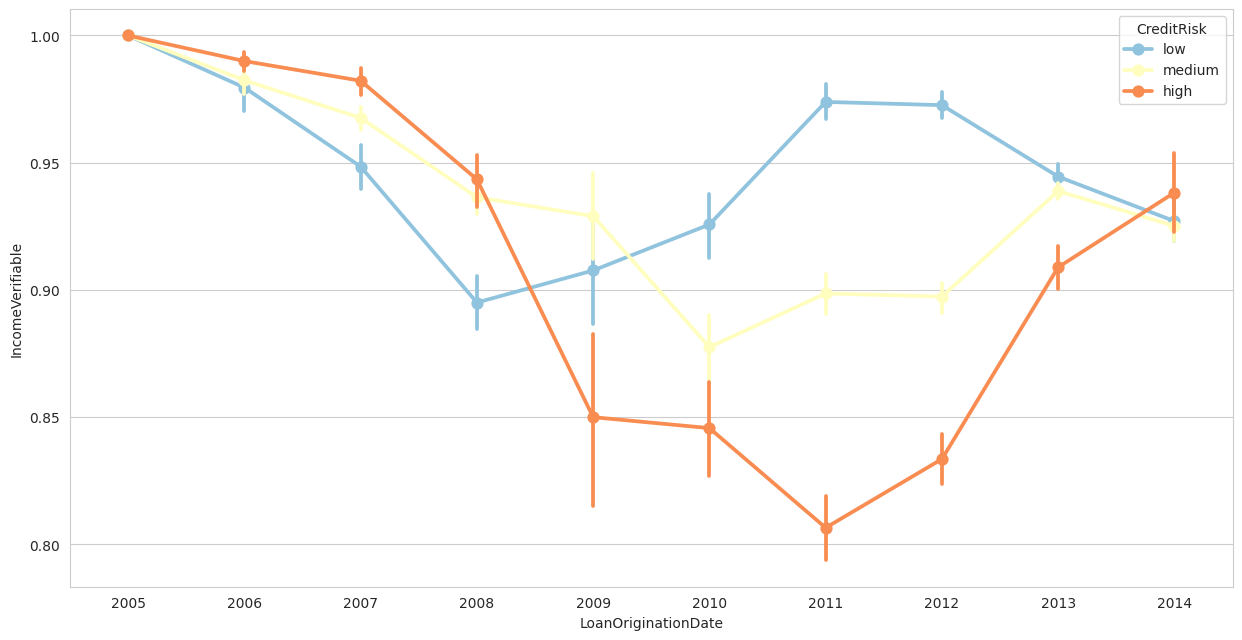

In [164]:
sns.pointplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'IncomeVerifiable', hue = 'CreditRisk', palette = 'RdYlBu_r');

There is an interesting shift where in the beginning of business, the riskiest borrowers apparently had to have a verified income more often than the safer borrower groups, but this is no longer the case since 2009 and the high risk group also has the lowest share of verifiable income.<br>
<br>
There are very clear differences among the credit risk groups, which is a good sign. Let's follow with looking if this still holds as clearly in the more detailed credit rating variable.
### Credit rating

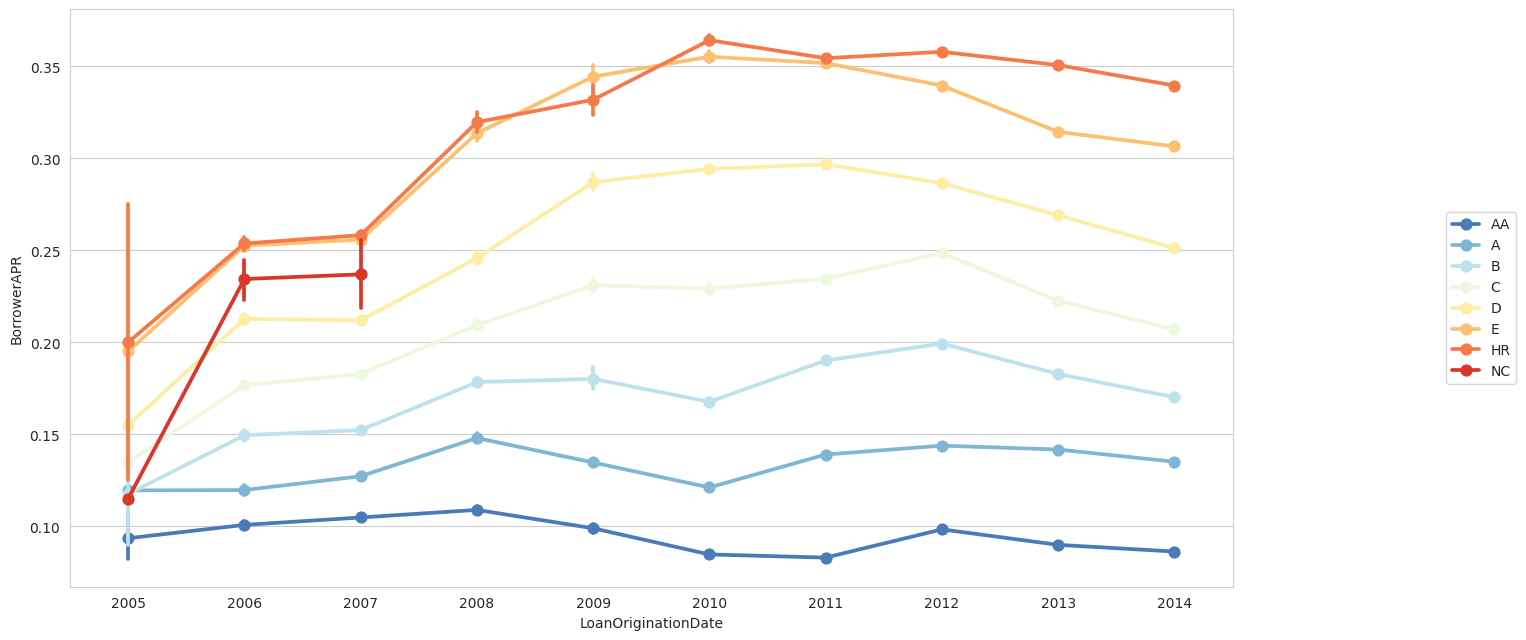

In [165]:
sns.pointplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'BorrowerAPR', hue = 'CreditRating', palette = 'RdYlBu_r')
plt.legend(loc = 'right', bbox_to_anchor=(1.25, 0.5), ncol=1);

* the difference in average interest rate in the worst ratings E and HR seems to be notable only in the last 3 years

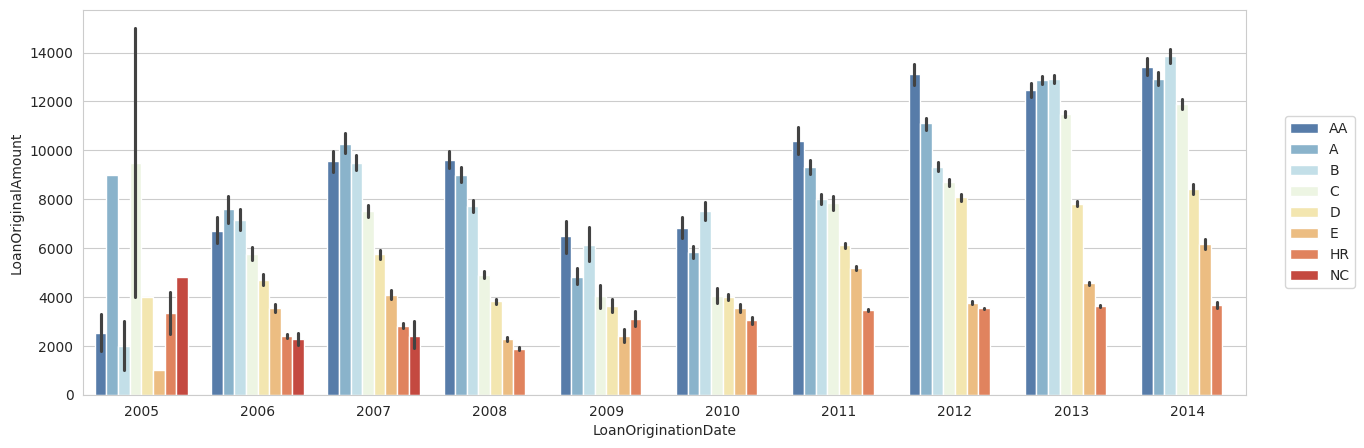

In [166]:
plt.figure(figsize=(15,5))
sns.barplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'LoanOriginalAmount', hue = 'CreditRating', palette = 'RdYlBu_r')
plt.legend(loc = 'right', bbox_to_anchor=(1.1, 0.5), ncol=1);

* loan amounts increase in time across categories, most notably the loan original amounts in C rating are getting closer to those of higher ratings

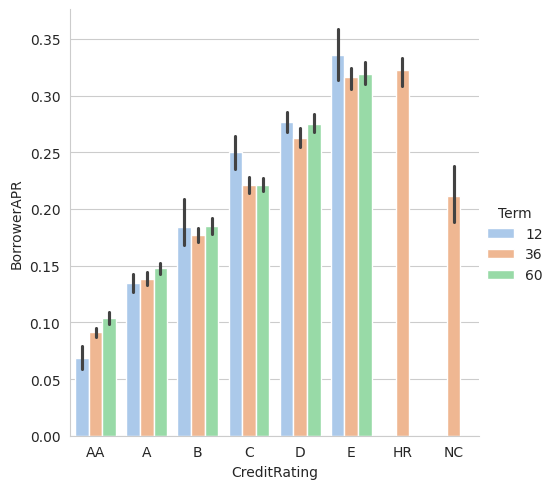

In [167]:
sns.catplot(x = 'CreditRating', y = 'BorrowerAPR', hue = 'Term', kind = 'bar', data = df_samp, palette = 'pastel');

* for AA and A ratings, 60m loans have the highest interest rate
* for B ratings, 12m and 60m bear a very similar interest rate
* for worse than B ratings, 12m loan is actually more expensive than 60m loan
* the worst rating can only borrow for 36 months

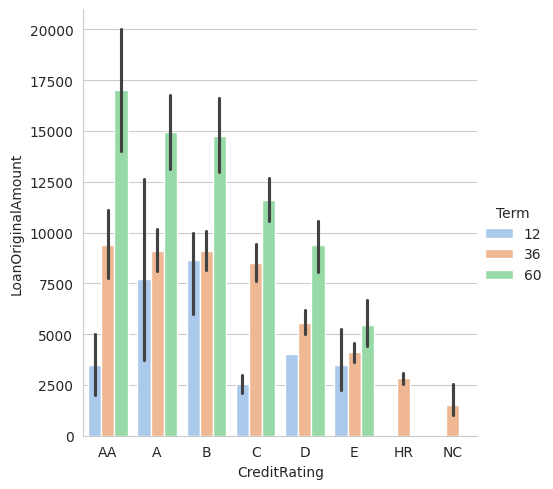

In [168]:
sns.catplot(x = 'CreditRating', y = 'LoanOriginalAmount', hue = 'Term', kind = 'bar', data = df_samp,palette = 'pastel');

* for 36m loan, the most common term, it is very clear that the worse the rating, the lower the borrowed amount

### Is Borrower a Homeowner

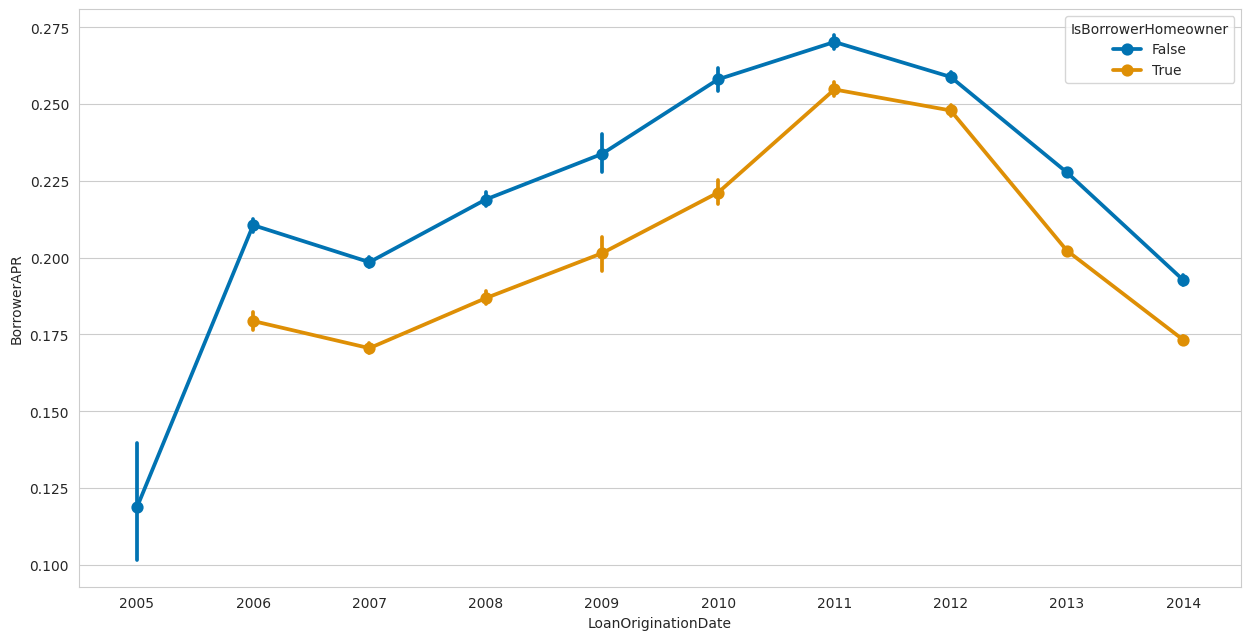

In [169]:
sns.pointplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'BorrowerAPR', hue = 'IsBorrowerHomeowner', \
             palette = 'colorblind');

* borrowers who do not own a house pay a higher interest and this holds throughout the years

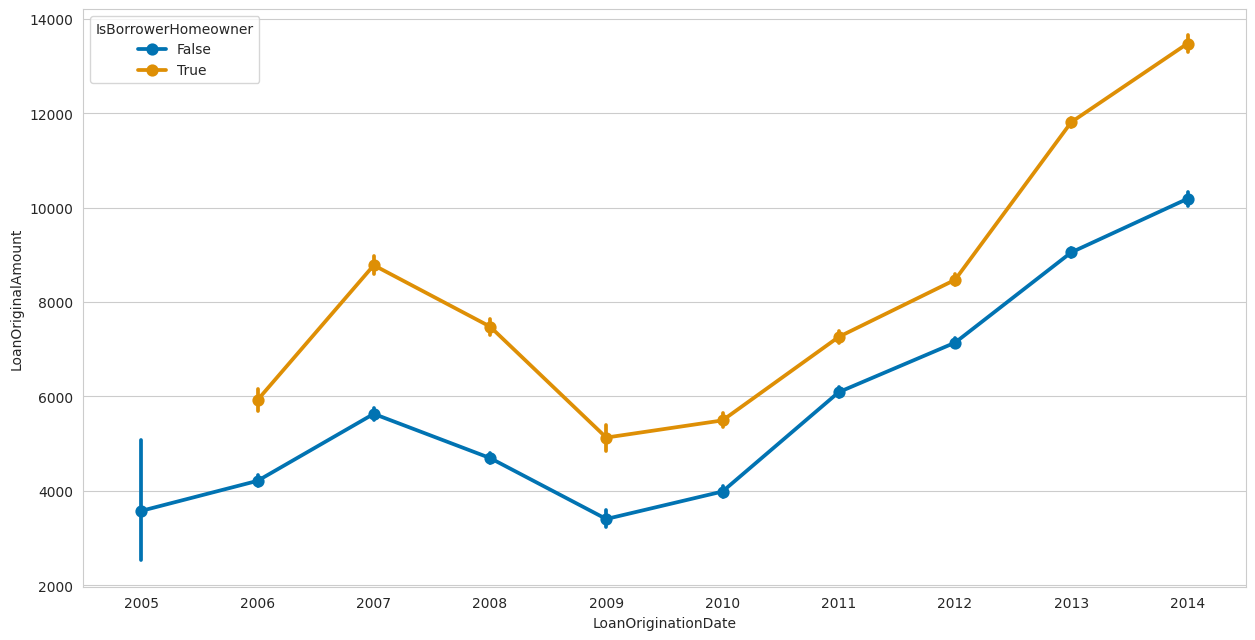

In [170]:
sns.pointplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'LoanOriginalAmount', hue = 'IsBorrowerHomeowner', \
             palette = 'colorblind');

* borrowers with a house borrow more money on average and this is true in all years

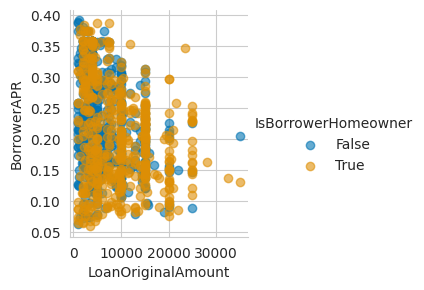

In [171]:
g = sns.FacetGrid(data = df_samp, hue = 'IsBorrowerHomeowner',palette = 'colorblind')
g.map(plt.scatter, 'LoanOriginalAmount', 'BorrowerAPR', alpha = 0.6)
g.add_legend()
plt.show()

* home owners more frequently borrow higher amounts

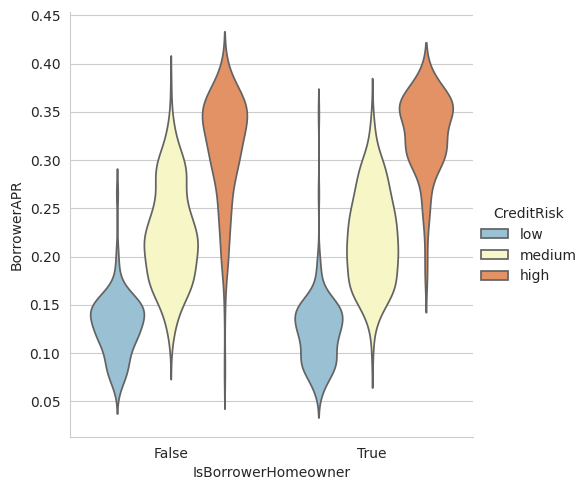

In [172]:
sns.catplot(x="IsBorrowerHomeowner", y="BorrowerAPR", hue="CreditRisk",
            kind="violin", inner=None,
            palette="RdYlBu_r", data=df_samp);

* once assigned a risk level, a home ownership does not make too much difference in the average interest rate in that risk group

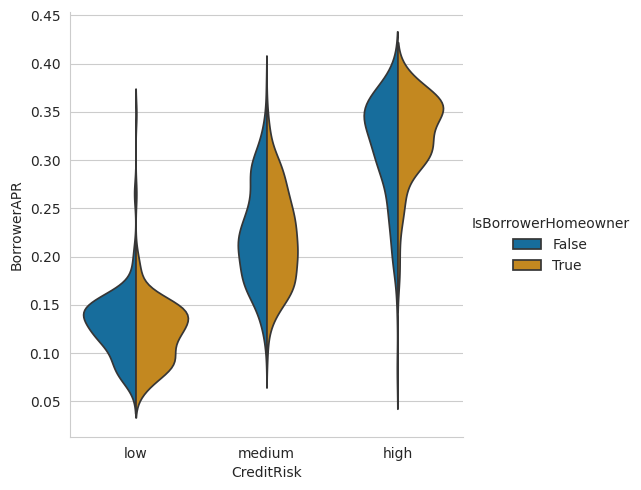

In [173]:
# the same is also visible here
sns.catplot(x="CreditRisk", y="BorrowerAPR", hue="IsBorrowerHomeowner",
            kind="violin", inner=None, split=True,
            palette="colorblind", data=df_samp);

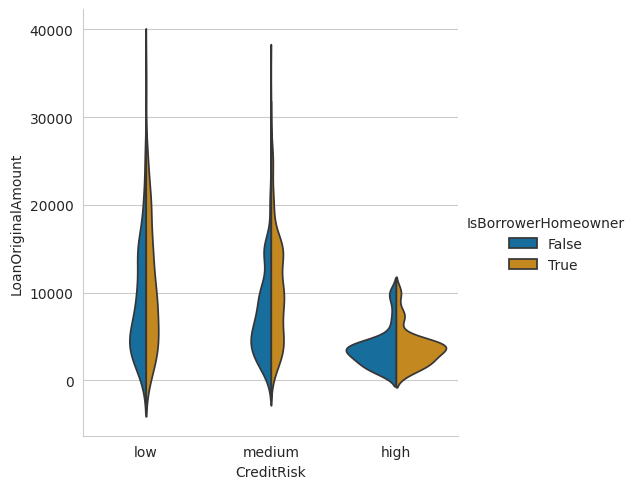

In [174]:
sns.catplot(x="CreditRisk", y="LoanOriginalAmount", hue="IsBorrowerHomeowner",
            kind="violin", inner=None, split=True,
            palette="colorblind", data=df_samp);

* there are more non-home owners borrowing lower amounts (< 10k) in low and medium risk groups than home-owners

### Income range

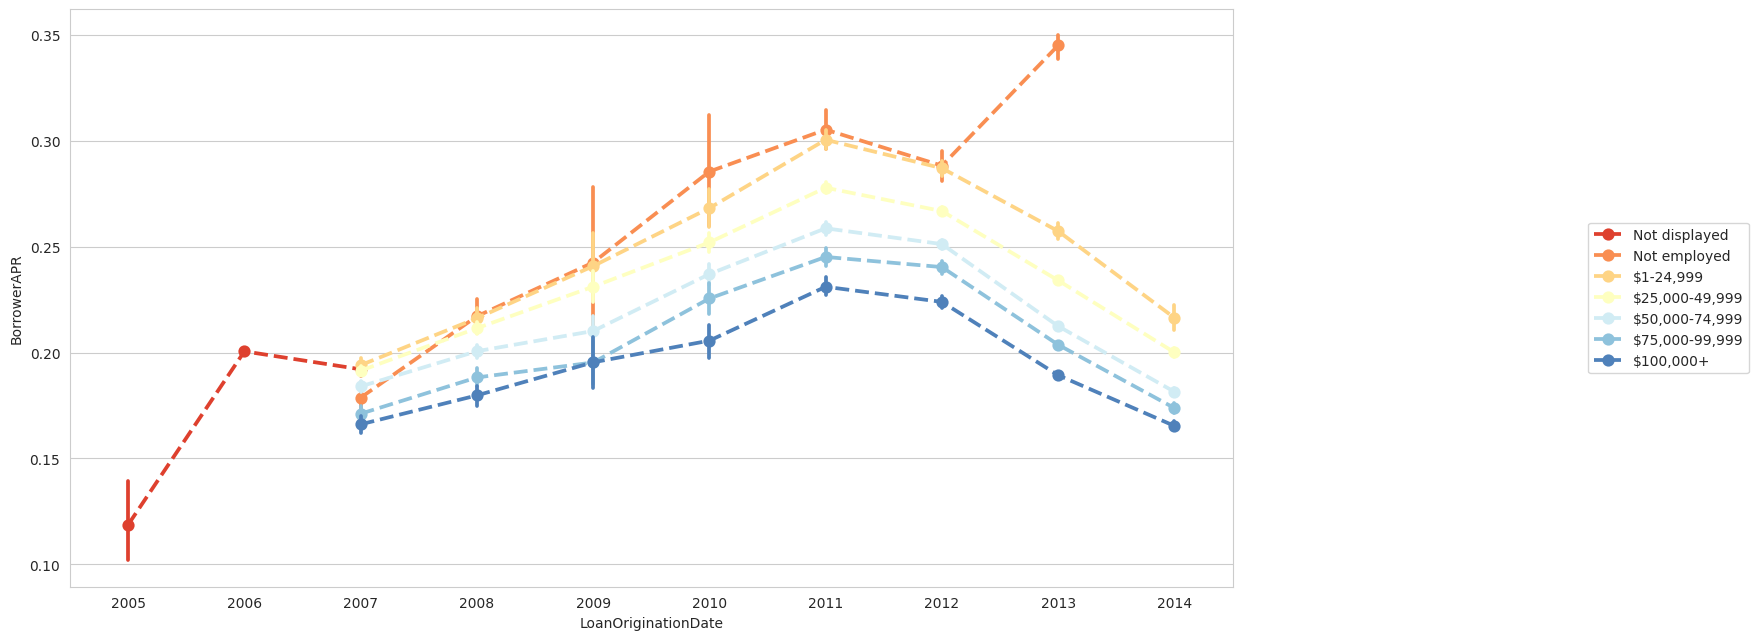

In [175]:
sns.pointplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'BorrowerAPR', hue = 'IncomeRange', palette = 'RdYlBu',\
             linestyles = '--')
plt.legend(loc = 'right', bbox_to_anchor=(1.45, 0.5), ncol=1);

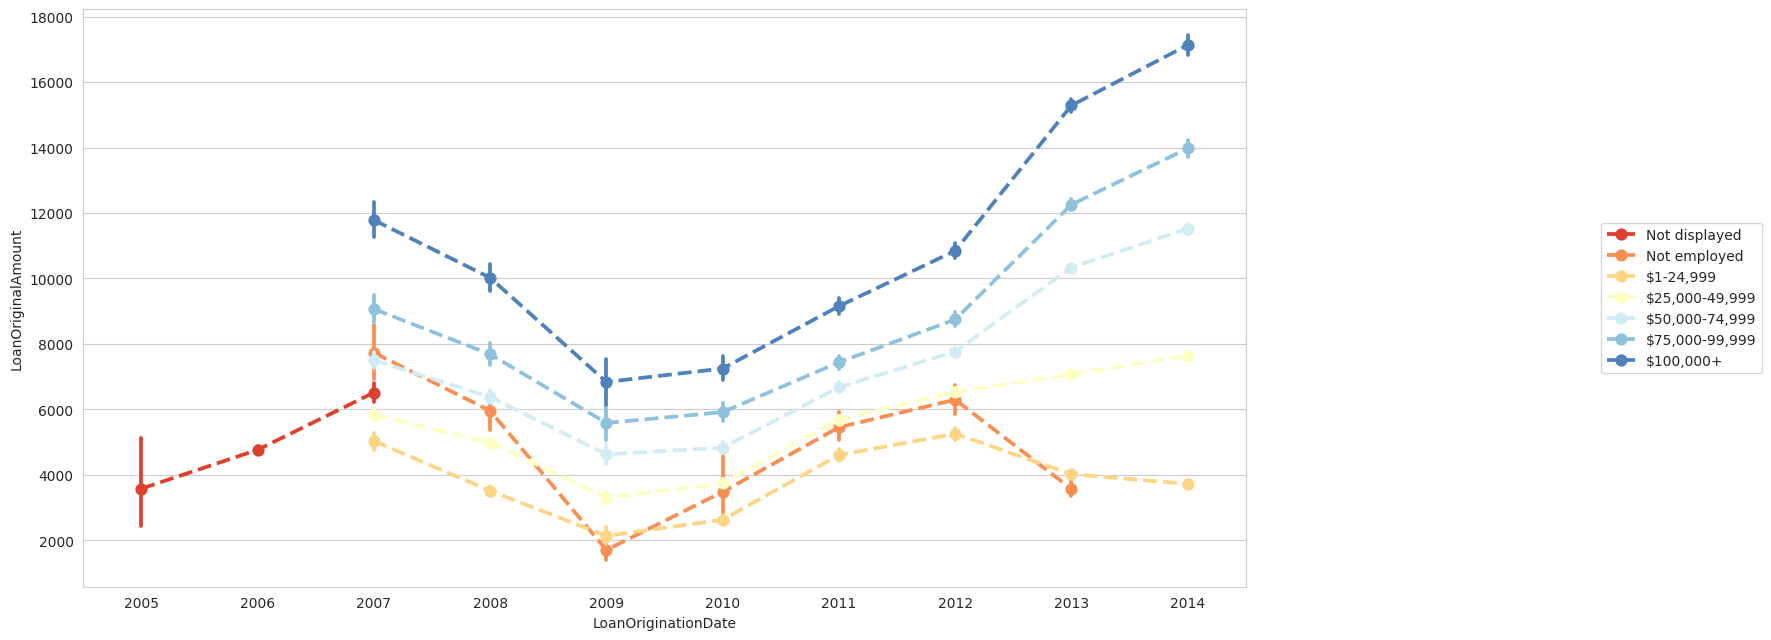

In [176]:
sns.pointplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'LoanOriginalAmount', hue = 'IncomeRange', \
             palette = 'RdYlBu', linestyles = '--')
plt.legend(loc = 'right', bbox_to_anchor=(1.45, 0.5), ncol=1);

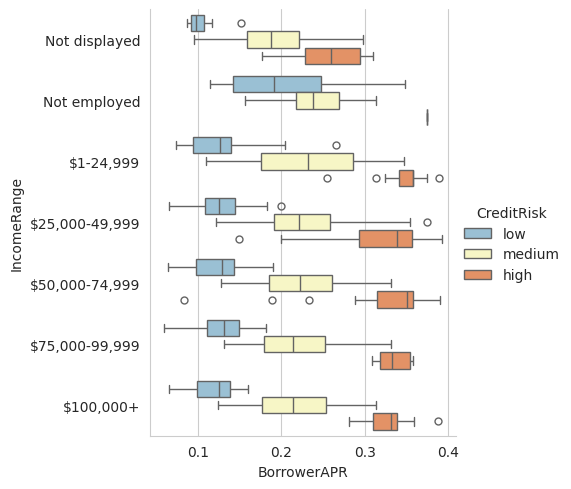

In [177]:
sns.catplot(y = 'IncomeRange', x = 'BorrowerAPR', hue = 'CreditRisk', kind = 'box', data = df_samp, palette = 'RdYlBu_r');

* once assigned into a risk category, income range does not seem to matter much (it was one of the inputs for deciding about the the risk category, so if someone is high risk even with 100k+ income, then this income does not give him lower rates anymore)

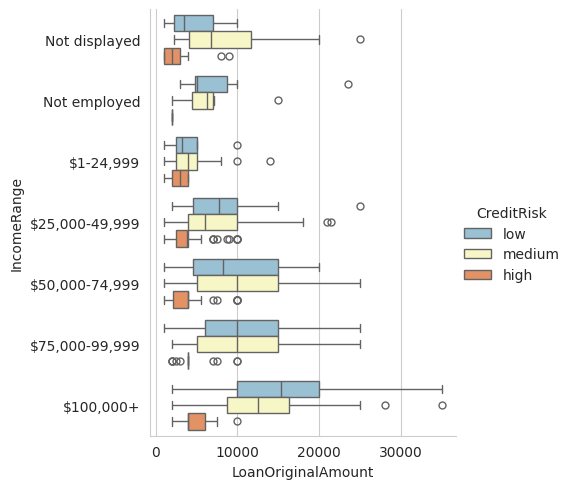

In [178]:
sns.catplot(y = 'IncomeRange', x = 'LoanOriginalAmount', hue = 'CreditRisk', kind = 'box', data = df_samp, palette = 'RdYlBu_r');

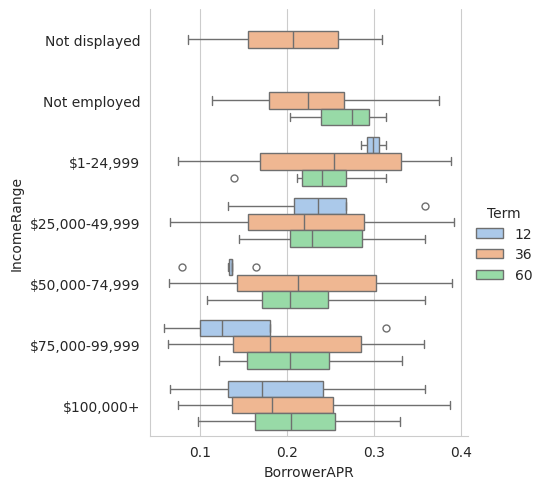

In [179]:
sns.catplot(y = 'IncomeRange', x = 'BorrowerAPR', hue = 'Term', kind = 'box', data = df_samp, palette = 'pastel');

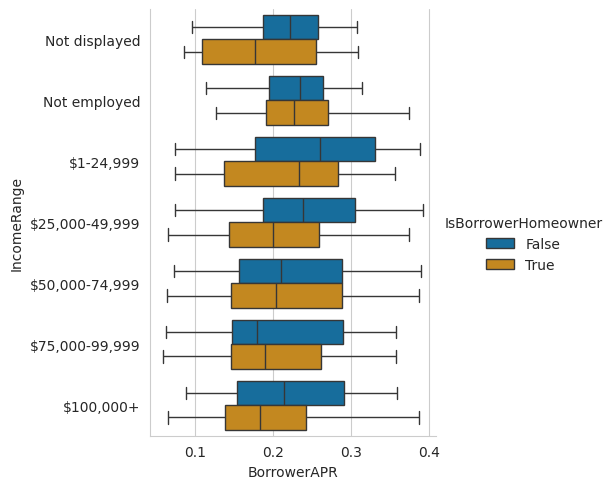

In [180]:
sns.catplot(y = 'IncomeRange', x = 'BorrowerAPR', hue = 'IsBorrowerHomeowner', kind = 'box', data = df_samp, palette = 'colorblind');

### Borrower APR and Loan Original Amount

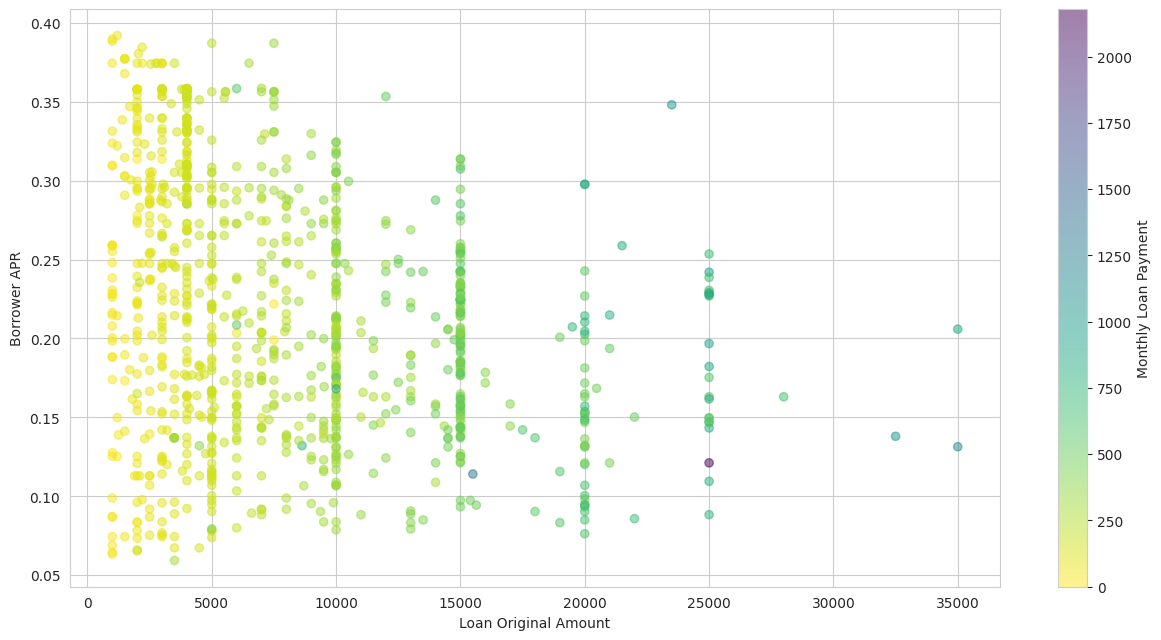

In [181]:
plt.scatter(data = df_samp, x = 'LoanOriginalAmount', y = 'BorrowerAPR', alpha = 1/2, c = 'MonthlyLoanPayment', \
            cmap = 'viridis_r')
plt.colorbar(label = 'Monthly Loan Payment')
plt.ylabel('Borrower APR')
plt.xlabel('Loan Original Amount')
plt.show()

* higher loan amounts have lower interest rate and higher monthly payments

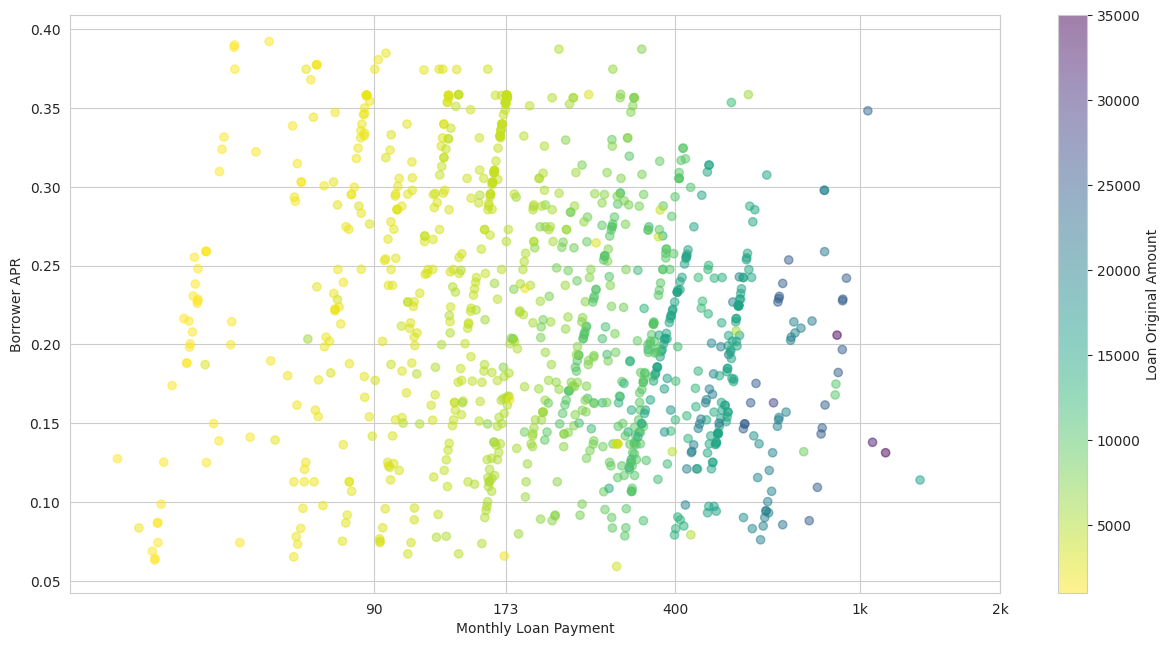

In [182]:
plt.scatter(data = df_samp, x = 'MonthlyLoanPayment', y = 'BorrowerAPR', alpha = 1/2, c = 'LoanOriginalAmount', \
            cmap = 'viridis_r')
plt.colorbar(label = 'Loan Original Amount')
plt.ylabel('Borrower APR')
plt.xlabel('Monthly Loan Payment')
plt.xlim((20,2000))
plt.xscale('log')
plt.xticks([90, 173, 400, 1e3, 2e3], [90, 173, 400, '1k', '2k'])
plt.show()

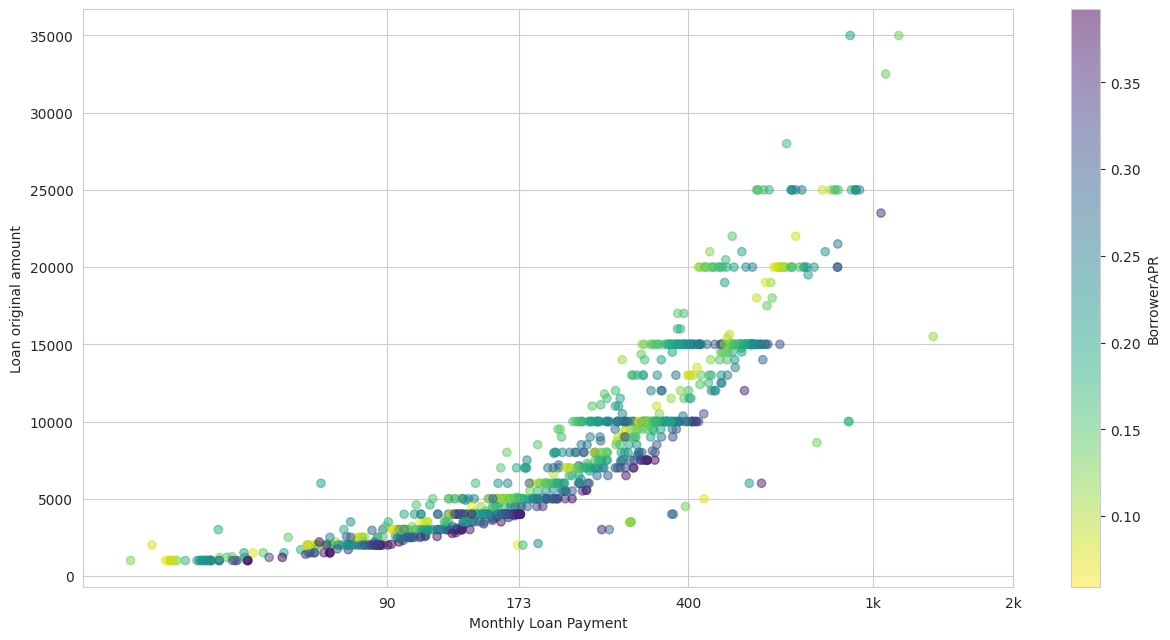

In [183]:
plt.scatter(data = df_samp, x = 'MonthlyLoanPayment', y = 'LoanOriginalAmount', alpha = 1/2, c = 'BorrowerAPR', \
            cmap = 'viridis_r')
plt.colorbar(label = 'BorrowerAPR')
plt.ylabel('Loan original amount')
plt.xlabel('Monthly Loan Payment')
plt.xlim((20,2000))
plt.xscale('log')
plt.xticks([90, 173, 400, 1e3, 2e3], [90, 173, 400, '1k', '2k'])
plt.show()

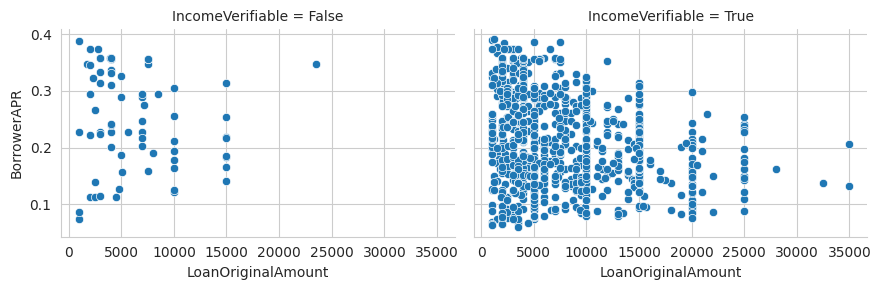

In [184]:
# borrowers with verifiable income borrow higher amounts more often
g = sns.FacetGrid(data = df_samp, col = 'IncomeVerifiable', aspect = 1.5)
g.map(sns.scatterplot, 'LoanOriginalAmount', 'BorrowerAPR')
plt.show()

### Employment status

<ipython-input-185-93cedcc022a5>:1: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:blue'` for the same effect.


<ipython-input-185-93cedcc022a5>:1: FutureWarning:



The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.




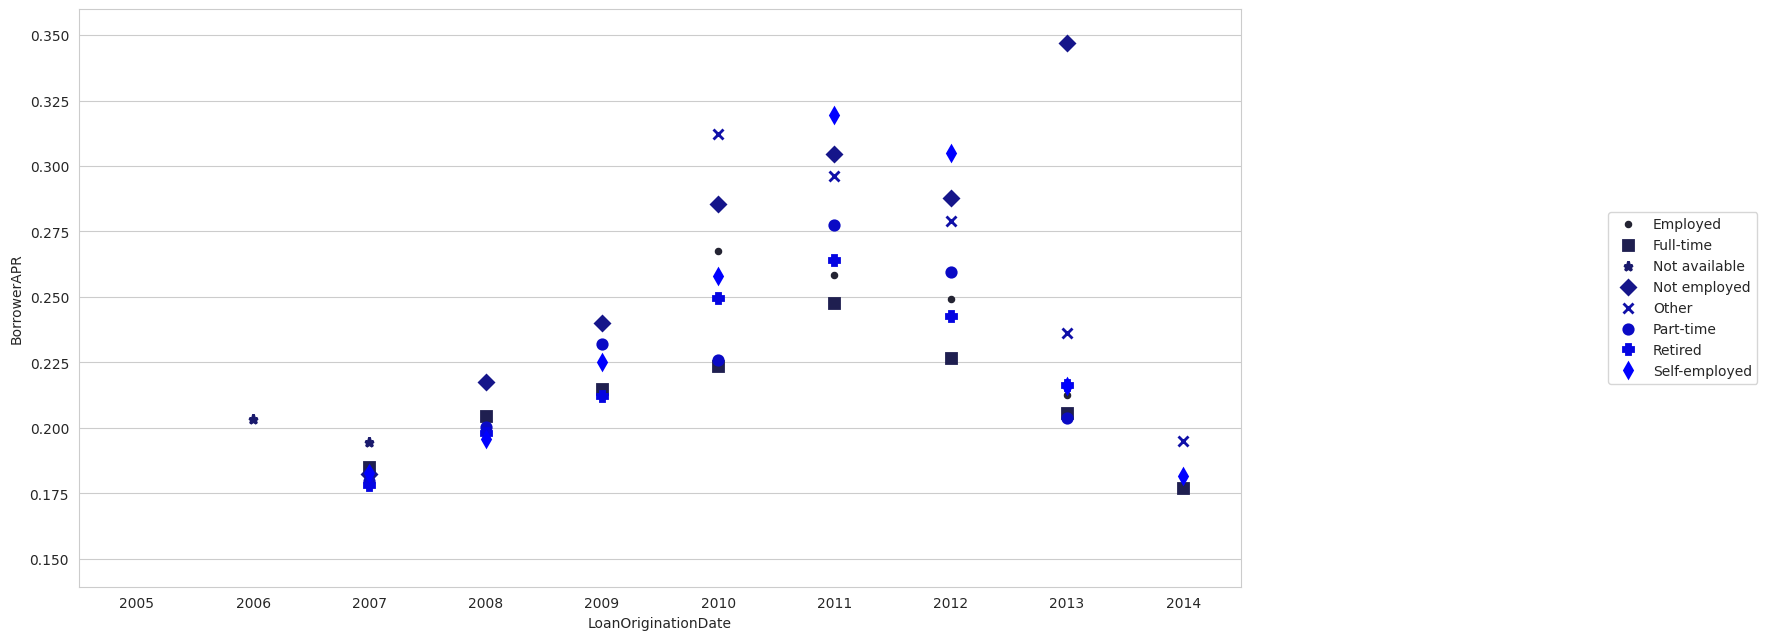

In [185]:
sns.pointplot(data = df, x = df['LoanOriginationDate'].dt.year, y = 'BorrowerAPR', hue = 'EmploymentStatus',\
             markers = ['.','s','*','D','x','o','P','d'], color = 'blue', errwidth=0, linestyles='')
plt.legend(loc = 'right', bbox_to_anchor=(1.45, 0.5), ncol=1);

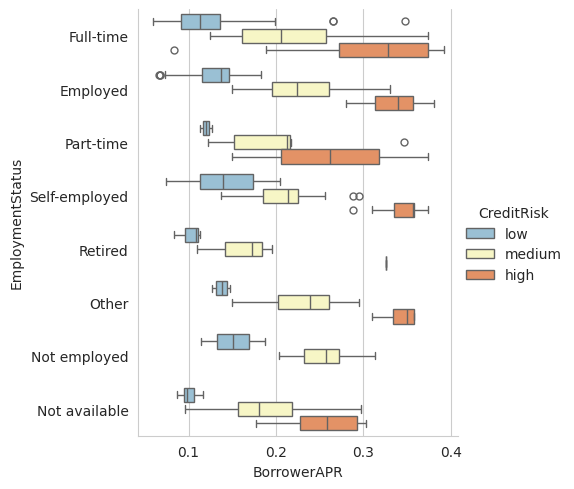

In [186]:
sns.catplot(y = 'EmploymentStatus', x = 'BorrowerAPR', hue = 'CreditRisk', order = \
           ['Full-time','Employed','Part-time','Self-employed','Retired','Other','Not employed','Not available'], \
           kind = 'box', data = df_samp, palette = 'RdYlBu_r');

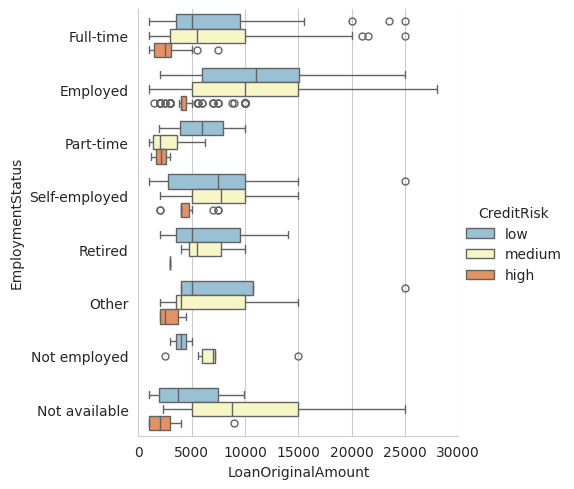

In [187]:
sns.catplot(y = 'EmploymentStatus', x = 'LoanOriginalAmount', hue = 'CreditRisk', order = \
           ['Full-time','Employed','Part-time','Self-employed','Retired','Other','Not employed','Not available'], \
           kind = 'box', data = df_samp, palette = 'RdYlBu_r')
plt.xlim((0,30000));

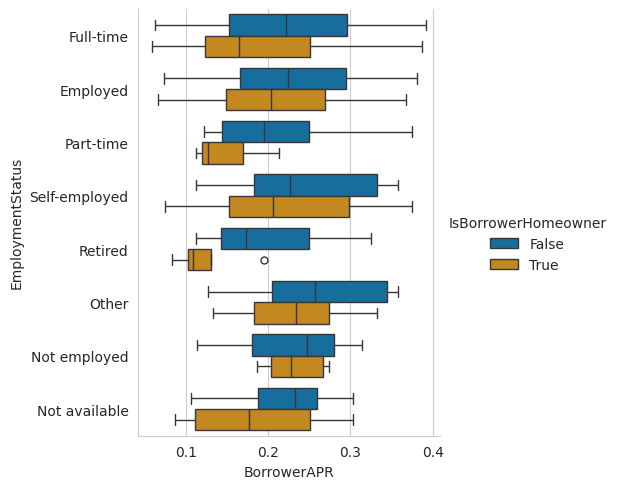

In [188]:
sns.catplot(y = 'EmploymentStatus', x = 'BorrowerAPR', hue = 'IsBorrowerHomeowner', order = \
           ['Full-time','Employed','Part-time','Self-employed','Retired','Other','Not employed','Not available'], \
           kind = 'box', data = df_samp, palette = 'colorblind');

Differences among employment statuses are not very significant or consistent. This combined with knowing that employment categories are very imbalanced as was described earlier prevents from making any solid conclusions.

### Observations

**Relationships Observed:**

Credit risk category is a major factor that segments borrowers into distinguishable groups. It strongly determines the interest rate and the borrowed amount. Borrowed amounts are increasing overall in the last few years, while the average interest rate is decreasing, especially for the medium and high-risk groups.

**Interesting Interactions:**

House ownership or income range are also significant for borrower segmentation, but only until combined with credit risk. This is because these variables feed into the credit score/credit rating/credit risk calculations. Once a borrower is assigned a credit rating/credit risk, these variables make no difference anymore.



#Data Labelling


In [189]:
df.head(20)

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating,ListingCategory,BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanNumber,LoanOriginalAmount,LoanOriginationDate,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors,LoanYear,MonthsToClosed,LoanStatusActive,CreditRating,CreditRisk
LoanKey,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
E33A3400205839220442E84,1021339766868145413AB3B,193129,NaT,C,36,Completed,2009-08-14,0.16516,0.1580,0.1380,0.13885,NaN,NaN,NaN,NaN,0,CO,Other,Self-employed,2.0,True,True,NaN,640.0,659.0,2001-10-11,5.0,4.0,12.0,1,24.0,3.0,3.0,2.0,472.0,4.0,0.0,0.0,0.0,0.00,1500.0,11.0,0.81,0.0,0.17,"$25,000-49,999",True,3083.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0,NaN,78,19141,9425,2007-09-12,Q3 2007,1F3E3376408759268057EDA,330.43,11396.1400,9425.00,1971.1400,-133.18,0.0,0.00,0.00,0.00,1.0000,0,0,0.0,258,2007,22.645161,False,C,medium
9E3B37071505919926B1D82,10273602499503308B223C1,1209647,NaT,NaN,36,Current,NaT,0.12016,0.0920,0.0820,0.07960,0.0249,0.05470,6.0,A,2,CO,Professional,Employed,44.0,False,False,NaN,680.0,699.0,1996-03-18,14.0,14.0,29.0,13,389.0,3.0,5.0,0.0,0.0,0.0,1.0,0.0,3989.0,0.21,10266.0,29.0,1.00,2.0,0.18,"$50,000-74,999",True,6125.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0,NaN,0,134815,10000,2014-03-03,Q1 2014,1D13370546739025387B2F4,318.93,0.0000,0.00,0.0000,0.00,0.0,0.00,0.00,0.00,1.0000,0,0,0.0,1,2014,NaN,True,A,low
6954337960046817851BCB2,0EE9337825851032864889A,81716,NaT,HR,36,Completed,2009-12-17,0.28269,0.2750,0.2400,0.25585,NaN,NaN,NaN,NaN,0,GA,Other,Not available,NaN,False,True,783C3371218786870A73D20,480.0,499.0,2002-07-27,NaN,NaN,3.0,0,0.0,0.0,1.0,1.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.06,Not displayed,True,2083.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0,NaN,86,6466,3001,2007-01-17,Q1 2007,5F7033715035555618FA612,123.32,4186.6300,3001.00,1185.6300,-24.20,0.0,0.00,0.00,0.00,1.0000,0,0,0.0,41,2007,34.354839,False,HR,high
A0393664465886295619C51,0EF5356002482715299901A,658116,NaT,NaN,36,Current,NaT,0.12528,0.0974,0.0874,0.08490,0.0249,0.06000,6.0,A,16,GA,Skilled Labor,Employed,113.0,True,False,NaN,800.0,819.0,1983-02-28,5.0,5.0,29.0,7,115.0,0.0,1.0,4.0,10056.0,14.0,0.0,0.0,1444.0,0.04,30754.0,26.0,0.76,0.0,0.15,"$25,000-49,999",True,2875.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0,NaN,16,77296,10000,2012-11-01,Q4 2012,9ADE356069835475068C6D2,321.45,5143.2000,4091.09,1052.1100,-108.01,0.0,0.00,0.00,0.00,1.0000,0,0,0.0,158,2012,NaN,True,A,low
A180369302188889200689E,0F023589499656230C5E3E2,909464,NaT,NaN,36,Current,NaT,0.24614,0.2085,0.1985,0.18316,0.0925,0.09066,3.0,D,2,MN,Executive,Employed,44.0,True,False,NaN,680.0,699.0,2004-02-20,19.0,19.0,49.0,6,220.0,1.0,9.0,0.0,0.0,0.0,0.0,0.0,6193.0

In [190]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113064 entries, E33A3400205839220442E84 to 00AF3704550953269A64E40
Data columns (total 82 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   ListingKey                           113064 non-null  object        
 1   ListingNumber                        113064 non-null  int64         
 2   ListingCreationDate                  382 non-null     datetime64[ns]
 3   CreditGrade                          28952 non-null   category      
 4   Term                                 113064 non-null  int64         
 5   LoanStatus                           113064 non-null  category      
 6   ClosedDate                           55054 non-null   datetime64[ns]
 7   BorrowerAPR                          113064 non-null  float64       
 8   BorrowerRate                         113064 non-null  float64       
 9   LenderYield                         

In [191]:
# Encode LoanStatus (e.g., 1 for default, 0 for not default)
# df["LoanStatus"] = df["ClosedDate"].apply(lambda x: 1 if pd.isnull(x) else 0)
df["LoanStatus"] = df["LoanCurrentDaysDelinquent"].apply(lambda x: 1 if x > 180 else 0)

In [192]:
df.isnull().sum()

ListingKey                                  0
ListingNumber                               0
ListingCreationDate                    112682
CreditGrade                             84112
Term                                        0
LoanStatus                                  0
ClosedDate                              58010
BorrowerAPR                                 0
BorrowerRate                                0
LenderYield                                 0
EstimatedEffectiveYield                     0
EstimatedLoss                           29083
EstimatedReturn                         29083
ProsperRating (numeric)                 29083
ProsperRating                           29083
ListingCategory                             0
BorrowerState                            5515
Occupation                               3529
EmploymentStatus                         2255
EmploymentStatusDuration                 7625
IsBorrowerHomeowner                         0
CurrentlyInGroup                  

In [193]:
df['LoanStatus'].value_counts().sort_index()

LoanStatus
0    98001
1    15063
Name: count, dtype: int64

# Feature Creation

In [194]:
# Creating new features

# 1. IncomeToLoanRatio: Ratio of stated monthly income to the loan amount
df['IncomeToLoanRatio'] = df['StatedMonthlyIncome'] / df['LoanOriginalAmount']

# 2. EmploymentStatusDurationYears: Employment status duration in years
df['EmploymentStatusDurationYears'] = df['EmploymentStatusDuration'] / 12

# 3. DebtToIncomeRatioCategory: Categorize debt to income ratio into bins
bins = [0, 0.2, 0.4, 0.6, 0.8, 1, 10.01]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High', 'Extreme']
df['DebtToIncomeRatioCategory'] = pd.cut(df['DebtToIncomeRatio'], bins=bins, labels=labels)

# 4. CreditScoreRangeMidpoint: Midpoint of the borrower's credit score range
df['CreditScoreRangeMidpoint'] = (df['CreditScoreRangeLower'] + df['CreditScoreRangeUpper']) / 2

# Encoding the new categorical feature
df['DebtToIncomeRatioCategory'] = df['DebtToIncomeRatioCategory'].cat.codes

# Missing Data Handling

In [195]:
for col in df.columns:
    print('{} : {}'.format(col,df[col].unique()))

ListingKey : ['1021339766868145413AB3B' '10273602499503308B223C1'
 '0EE9337825851032864889A' ... 'E6E13596170052029692BB1'
 'E6EB3531504622671970D9E' 'E6ED3600409833199F711B7']
ListingNumber : [ 193129 1209647   81716 ... 1069178  539056 1140093]
ListingCreationDate : <DatetimeArray>
[                'NaT', '2007-12-23 12:09:24', '2012-08-13 06:10:52',
 '2013-06-03 09:07:12', '2012-06-13 17:06:50', '2008-04-15 12:16:44',
 '2013-11-01 13:53:22', '2008-03-05 08:21:35', '2006-05-07 12:52:18',
 '2006-09-13 19:44:51',
 ...
 '2007-11-16 10:00:18', '2013-10-18 19:33:16', '2008-06-08 14:44:40',
 '2007-01-03 12:25:47', '2011-12-21 10:42:33', '2008-09-08 17:27:46',
 '2008-07-17 22:44:53', '2007-04-25 17:58:06', '2008-05-29 19:45:51',
 '2012-03-15 16:29:21']
Length: 383, dtype: datetime64[ns]
CreditGrade : ['C', NaN, 'HR', 'AA', 'D', 'B', 'E', 'A', 'NC']
Categories (8, object): ['AA' < 'A' < 'B' < 'C' < 'D' < 'E' < 'HR' < 'NC']
Term : [36 60 12]
LoanStatus : [0 1]
ClosedDate : <DatetimeArray>
['2

In [196]:
for col in df.columns:
    df[col].replace({'?':np.nan},inplace=True)

In [197]:
df.head()

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating,ListingCategory,BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanNumber,LoanOriginalAmount,LoanOriginationDate,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors,LoanYear,MonthsToClosed,LoanStatusActive,CreditRating,CreditRisk,IncomeToLoanRatio,EmploymentStatusDurationYears,DebtToIncomeRatioCategory,CreditScoreRangeMidpoint
LoanKey,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
E33A3400205839220442E84,1021339766868145413AB3B,193129,NaT,C,36,0,2009-08-14,0.16516,0.1580,0.1380,0.13885,NaN,NaN,NaN,NaN,0,CO,Other,Self-employed,2.0,True,True,NaN,640.0,659.0,2001-10-11,5.0,4.0,12.0,1,24.0,3.0,3.0,2.0,472.0,4.0,0.0,0.0,0.0,0.00,1500.0,11.0,0.81,0.0,0.17,"$25,000-49,999",True,3083.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,78,19141,9425,2007-09-12,Q3 2007,1F3E3376408759268057EDA,330.43,11396.14,9425.00,1971.14,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258,2007,22.645161,False,C,medium,0.327144,0.166667,0,649.5
9E3B37071505919926B1D82,10273602499503308B223C1,1209647,NaT,NaN,36,0,NaT,0.12016,0.0920,0.0820,0.07960,0.0249,0.05470,6.0,A,2,CO,Professional,Employed,44.0,False,False,NaN,680.0,699.0,1996-03-18,14.0,14.0,29.0,13,389.0,3.0,5.0,0.0,0.0,0.0,1.0,0.0,3989.0,0.21,10266.0,29.0,1.00,2.0,0.18,"$50,000-74,999",True,6125.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,0,134815,10000,2014-03-03,Q1 2014,1D13370546739025387B2F4,318.93,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1,2014,NaN,True,A,low,0.612500,3.666667,0,689.5
6954337960046817851BCB2,0EE9337825851032864889A,81716,NaT,HR,36,0,2009-12-17,0.28269,0.2750,0.2400,0.25585,NaN,NaN,NaN,NaN,0,GA,Other,Not available,NaN,False,True,783C3371218786870A73D20,480.0,499.0,2002-07-27,NaN,NaN,3.0,0,0.0,0.0,1.0,1.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.06,Not displayed,True,2083.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,86,6466,3001,2007-01-17,Q1 2007,5F7033715035555618FA612,123.32,4186.63,3001.00,1185.63,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41,2007,34.354839,False,HR,high,0.694213,NaN,0,489.5
A0393664465886295619C51,0EF5356002482715299901A,658116,NaT,NaN,36,0,NaT,0.12528,0.0974,0.0874,0.08490,0.0249,0.06000,6.0,A,16,GA,Skilled Labor,Employed,113.0,True,False,NaN,800.0,819.0,1983-02-28,5.0,5.0,29.0,7,115.0,0.0,1.0,4.0,10056.0,14.0,0.0,0.0,1444.0,0.04,30754.0,26.0,0.76,0.0,0.15,"$25,000-49,999",True,2875.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,16,77296,10000,2012-11-01,Q4 2012,9ADE356069835475068C6D2,321.45,5143.20,4091.09,1052.11,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158,2012,NaN,True,A,low,0.287500,9.416667,0,809.5
A180369302188889200689E,0F023589499656230C5E3E2,909464,NaT,NaN,36,0,NaT,0.24614,0.2085,0.1985,0.18316,0.0925,0.09066,3.0,D,

In [198]:
df.isnull().sum()

ListingKey                                  0
ListingNumber                               0
ListingCreationDate                    112682
CreditGrade                             84112
Term                                        0
LoanStatus                                  0
ClosedDate                              58010
BorrowerAPR                                 0
BorrowerRate                                0
LenderYield                                 0
EstimatedEffectiveYield                     0
EstimatedLoss                           29083
EstimatedReturn                         29083
ProsperRating (numeric)                 29083
ProsperRating                           29083
ListingCategory                             0
BorrowerState                            5515
Occupation                               3529
EmploymentStatus                         2255
EmploymentStatusDuration                 7625
IsBorrowerHomeowner                         0
CurrentlyInGroup                  

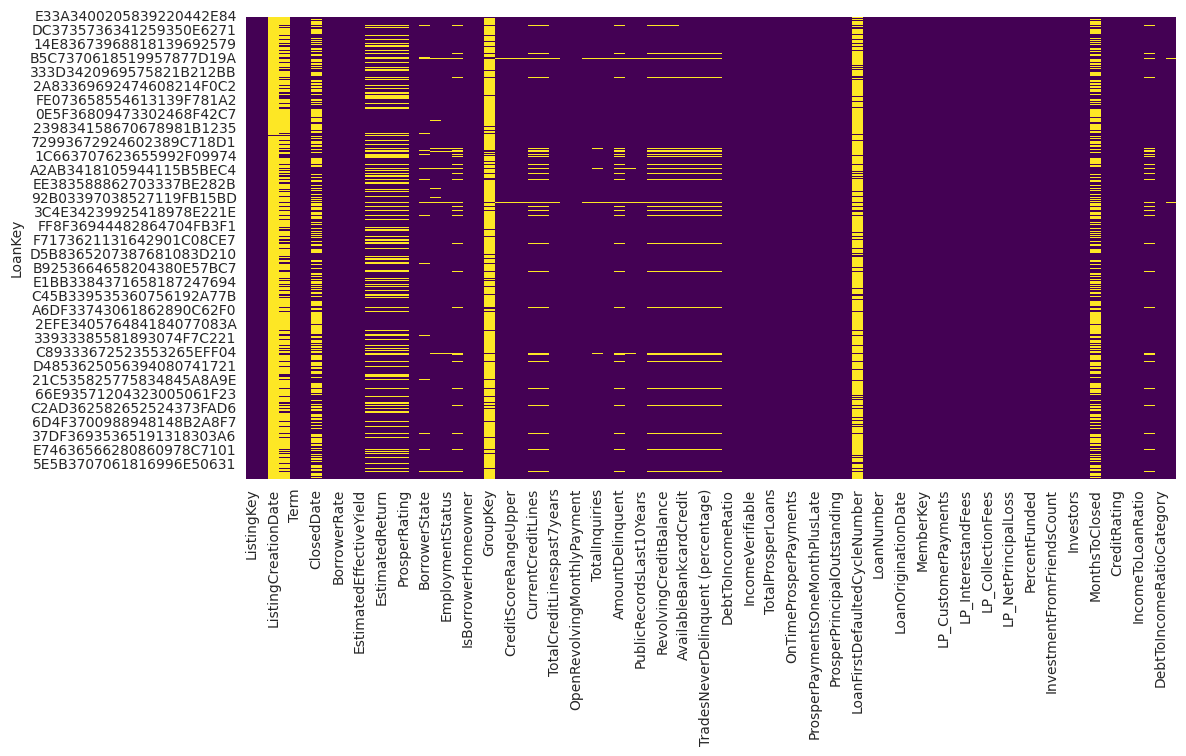

In [199]:
plt.figure(figsize=(12, 6))  # Adjust the figure size as needed
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [200]:
df.describe()


,ListingNumber,ListingCreationDate,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),EmploymentStatusDuration,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,StatedMonthlyIncome,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanNumber,LoanOriginalAmount,LoanOriginationDate,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors,LoanYear,MonthsToClosed,IncomeToLoanRatio,EmploymentStatusDurationYears,DebtToIncomeRatioCategory,CreditScoreRangeMidpoint
count,1.130640e+05,382,113064.000000,113064.000000,55054,113064.000000,113064.000000,113064.000000,113064.000000,83981.000000,83981.000000,83981.000000,105439.000000,112473.000000,112473.000000,112367,105460.000000,105460.000000,112367.000000,113064.000000,113064.000000,112367.000000,111905.000000,112367.00000,105442.000000,112074.000000,112367.000000,105460.000000,1.054600e+05,105460.000000,105520.000000,105520.000000,105520.000000,105520.000000,113064.000000,1.130640e+05,113064.000000,113064.000000,113064.00000,113064.000000,113064.000000,113064.000000,113064.000000,113064.000000,16952.000000,113064.000000,113064.000000,113064.000000,113064,113064.000000,113064.000000,113064.000000,113064.000000,113064.000000,113064.000000,113064.000000,113064.000000,113064.00000,113064.000000,113064.000000,113064.000000,113064.000000,113064.000000,113064.000000,55054.000000,113064.000000,105439.000000,113064.000000,112473.000000
mean,6.248013e+05,2011-03-31 12:58:28.513089024,40.800255,0.133225,2011-03-08 00:38:08.138917888,0.218959,0.192947,0.182884,0.167647,0.080417,0.096246,4.068682,96.062055,685.524882,704.524882,1994-11-13 18:22:40.007831552,10.307112,9.248397,26.746376,6.959510,397.826187,1.438616,5.590814,0.59513,986.834022,4.158618,0.312761,0.015210,1.759262e+04,0.561098,11208.250417,23.221531,0.885558,0.802085,3.043781,5.605142e+03,0.275419,4.446278,4.31782,0.119092,0.009322,1638.978861,567.967134,153.993039,16.268464,32.121736,69044.317599,8314.878432,2011-07-14 07:10:35.024410880,271.936536,4209.309061,3125.541461,1083.767600,-55.020577,-14.351245,705.854692,686.681945,25.33682,0.998573,0.048380,0.023641,16.678544,80.877344,2011.023668,18.945029,1.042120,8.005171,0.637683,695.024882
min,4.000000e+00,2005-12-29 19:53:41,12.000000,0.000000,2005-11-25 00:00:00,0.006530,0.000000,-0.010000,-0.182700,0.004900,-0.182700,1.000000,0.000000,0.000000,19.000000,1947-08-24 00:00:00,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1000.000000,2005-11-15 00:00:00,0.000000,-2.349900,0.000000,-2.349900,-664.870000,-9274.750000,-94.200000,-954.550000,0.00000,0.700000,0.000000,0.000000,0.000000,1.000000,2005.000000,0.000000,0.000000,0.000000,-1.000000,9.500000
25%,3.976642e+05,2008-05-31 04:41:22.249999872,36.000000,0.000000,2009-07-15 00:00:00,0.156290,0.134000,0.124500,0.114770,0.042400,0.074630,3.00000

In [201]:
df.drop(columns=['ListingKey','ListingNumber'], inplace=True, axis=1)

In [202]:
df1 = df.copy()

In [203]:
# Make a list of features which have missing values
features_with_na = [feature for feature in df.columns if df[feature].isnull().sum() > 0]

# Print the feature name and the percentage of missing values
for feature in features_with_na:
    missing_percentage = np.round(df[feature].isnull().mean() * 100, 2)
    print(f"{feature}: {missing_percentage}% missing values")

ListingCreationDate: 99.66% missing values
CreditGrade: 74.39% missing values
ClosedDate: 51.31% missing values
EstimatedLoss: 25.72% missing values
EstimatedReturn: 25.72% missing values
ProsperRating (numeric): 25.72% missing values
ProsperRating: 25.72% missing values
BorrowerState: 4.88% missing values
Occupation: 3.12% missing values
EmploymentStatus: 1.99% missing values
EmploymentStatusDuration: 6.74% missing values
GroupKey: 88.2% missing values
CreditScoreRangeLower: 0.52% missing values
CreditScoreRangeUpper: 0.52% missing values
FirstRecordedCreditLine: 0.62% missing values
CurrentCreditLines: 6.73% missing values
OpenCreditLines: 6.73% missing values
TotalCreditLinespast7years: 0.62% missing values
InquiriesLast6Months: 0.62% missing values
TotalInquiries: 1.03% missing values
CurrentDelinquencies: 0.62% missing values
AmountDelinquent: 6.74% missing values
DelinquenciesLast7Years: 0.88% missing values
PublicRecordsLast10Years: 0.62% missing values
PublicRecordsLast12Months

In [204]:
df2 =df.copy()

In [205]:
# Drop columns with more than 50% missing data
columns_to_drop = [feature for feature in features_with_na if (df[feature].isnull().mean() * 100) > 55]
print("Columns being dropped:")
print(columns_to_drop)

Columns being dropped:
['ListingCreationDate', 'CreditGrade', 'GroupKey', 'LoanFirstDefaultedCycleNumber']


In [206]:
df.drop(columns=columns_to_drop, inplace=True)

In [207]:
df.isnull().sum()

Term                                       0
LoanStatus                                 0
ClosedDate                             58010
BorrowerAPR                                0
BorrowerRate                               0
LenderYield                                0
EstimatedEffectiveYield                    0
EstimatedLoss                          29083
EstimatedReturn                        29083
ProsperRating (numeric)                29083
ProsperRating                          29083
ListingCategory                            0
BorrowerState                           5515
Occupation                              3529
EmploymentStatus                        2255
EmploymentStatusDuration                7625
IsBorrowerHomeowner                        0
CurrentlyInGroup                           0
CreditScoreRangeLower                    591
CreditScoreRangeUpper                    591
FirstRecordedCreditLine                  697
CurrentCreditLines                      7604
OpenCredit

In [208]:
df.dropna(inplace=True)

In [209]:
df.shape

(25969, 80)

In [210]:
df3 = df.copy()

# Data Encoding

In [211]:
# Assuming df is your DataFrame
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['ProsperRating', 'ListingCategory', 'BorrowerState', 'Occupation', 'EmploymentStatus', 'IncomeRange', 'LoanOriginationQuarter', 'MemberKey', 'CreditRating', 'CreditRisk']


In [212]:
# Encoding categorical variables
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# WOE and IV Calculation

##Dropping DateTimeColumns

In [213]:
# Identify datetime columns
datetime_columns = df.select_dtypes(include=['datetime64']).columns.tolist()

# Drop datetime columns from the DataFrame
df.drop(columns=datetime_columns,inplace =True)

In [214]:
#function to calculate weight of evidence and information value

def iv_woe(df, target, bins=10, show_woe=False):

    #Empty Dataframe
    newDF,woeDF = pd.DataFrame(), pd.DataFrame()

    #Extract Column Names
    cols = df.columns

    #Run WOE and IV on all the independent variables
    for ivars in cols[~cols.isin([target])]:
        if (df[ivars].dtype.kind in 'bifc') and (len(np.unique(df[ivars]))>10):
            binned_x = pd.qcut(df[ivars], bins,  duplicates='drop')
            d0 = pd.DataFrame({'x': binned_x, 'y': df[target]})
        else:
            d0 = pd.DataFrame({'x': df[ivars], 'y': df[target]})
        d = d0.groupby("x", as_index=False).agg({"y": ["count", "sum"]})
        d.columns = ['Cutoff', 'N', 'Events']
        d['% of Events'] = np.maximum(d['Events'], 0.5) / d['Events'].sum()
        d['Non-Events'] = d['N'] - d['Events']
        d['% of Non-Events'] = np.maximum(d['Non-Events'], 0.5) / d['Non-Events'].sum()
        d['WoE'] = np.log(d['% of Events']/d['% of Non-Events'])
        d['IV'] = d['WoE'] * (d['% of Events'] - d['% of Non-Events'])
        d.insert(loc=0, column='Variable', value=ivars)
        print("Information value of " + ivars + " is " + str(round(d['IV'].sum(),6)))
        temp =pd.DataFrame({"Variable" : [ivars], "IV" : [d['IV'].sum()]}, columns = ["Variable", "IV"])
        newDF=pd.concat([newDF,temp], axis=0)
        woeDF=pd.concat([woeDF,d], axis=0)

        #Show WOE Table
        if show_woe == True:
            print(d)
    return newDF, woeDF
iv, woe = iv_woe(df, target='LoanStatus', bins=20)

Information value of Term is 0.109477
Information value of BorrowerAPR is 0.478828
Information value of BorrowerRate is 0.521275
Information value of LenderYield is 0.52103
Information value of EstimatedEffectiveYield is 0.457432
Information value of EstimatedLoss is 0.408745
Information value of EstimatedReturn is 0.474747
Information value of ProsperRating (numeric) is 0.360668
Information value of ProsperRating is 0.360668
Information value of ListingCategory is 0.018957
Information value of BorrowerState is 0.018385
Information value of Occupation is 0.073519
Information value of EmploymentStatus is 0.077528
Information value of EmploymentStatusDuration is 0.012797
Information value of IsBorrowerHomeowner is 0.019615
Information value of CurrentlyInGroup is 0.00919
Information value of CreditScoreRangeLower is 0.155478
Information value of CreditScoreRangeUpper is 0.155478
Information value of CurrentCreditLines is 0.072967
Information value of OpenCreditLines is 0.065194
Informati

In [215]:
# Filter variables with IV values greater than 0.2 and less than 5
variables_with_notable_power = iv[(iv['IV'] > 0.2) & (iv['IV'] < 5)]['Variable'].tolist()

print("Variables with notable predictive power (IV > 0.2 and IV < 1.2):")
print(variables_with_notable_power)

Variables with notable predictive power (IV > 0.2 and IV < 1.2):
['BorrowerAPR', 'BorrowerRate', 'LenderYield', 'EstimatedEffectiveYield', 'EstimatedLoss', 'EstimatedReturn', 'ProsperRating (numeric)', 'ProsperRating', 'LoanMonthsSinceOrigination', 'LoanNumber', 'LoanOriginationQuarter', 'LP_CustomerPayments', 'LP_CustomerPrincipalPayments', 'LoanYear', 'MonthsToClosed', 'CreditRating', 'CreditRisk']


In [216]:
len(variables_with_notable_power)

17

#Feature Selection

In [217]:
target = 'LoanStatus'
X = df[variables_with_notable_power]
y = df[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [218]:
# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Binary Classification Models

##1. Logistic Regression

In [219]:
# Initialize the logistic regression model
log_reg = LogisticRegression(max_iter=1000)

# Train the model
log_reg.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test_scaled)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Get the coefficients
print("Coefficients:")
print(log_reg.coef_)

# Get the intercept
print("Intercept:")
print(log_reg.intercept_)

# Get the probability of each sample belonging to each class
y_prob = log_reg.predict_proba(X_test)
print("Probability of each sample belonging to each class:")
print(y_prob)

Accuracy: 0.9433962264150944
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      4153
           1       0.87      0.85      0.86      1041

    accuracy                           0.94      5194
   macro avg       0.91      0.91      0.91      5194
weighted avg       0.94      0.94      0.94      5194

Confusion Matrix:
[[4015  138]
 [ 156  885]]
Coefficients:
[[ -1.71327558   0.18886616   0.10703973   0.24262803   0.99009384
    0.52248143  -0.90388154  -0.58597287  -0.85122219  -1.6131455
    0.14413088   8.64502369 -15.11738684   0.43305588  -0.47249259
   -0.58597287   0.06881461]]
Intercept:
[-5.19942712]
Probability of each sample belonging to each class:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning:

X has feature names, but LogisticRegression was fitted without feature names



##2. Naive Bayes

In [220]:
# Initialize the Naive Bayes model
nb = GaussianNB()

# Train the model
nb.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = nb.predict(X_test_scaled)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7294955718136311
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.72      0.81      4153
           1       0.41      0.78      0.54      1041

    accuracy                           0.73      5194
   macro avg       0.67      0.75      0.67      5194
weighted avg       0.83      0.73      0.75      5194

Confusion Matrix:
[[2974 1179]
 [ 226  815]]


##3. GBT Model

In [221]:
# Initialize the Gradient Boosting model
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5)

# Train the model
gb.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = gb.predict(X_test_scaled)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9626492106276473
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      4153
           1       0.89      0.92      0.91      1041

    accuracy                           0.96      5194
   macro avg       0.94      0.95      0.94      5194
weighted avg       0.96      0.96      0.96      5194

Confusion Matrix:
[[4039  114]
 [  80  961]]


##4. Linear Discriminant Analysis (LDA)

In [222]:
# Initialize the LDA model
lda = LinearDiscriminantAnalysis()

# Train the model
lda.fit(X_train, y_train)

# Make predictions on the test set
y_pred = lda.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8623411628802464
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      4153
           1       0.85      0.38      0.53      1041

    accuracy                           0.86      5194
   macro avg       0.86      0.68      0.72      5194
weighted avg       0.86      0.86      0.84      5194

Confusion Matrix:
[[4082   71]
 [ 644  397]]


## Without Scaling

In [223]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'GBT': GradientBoostingClassifier(),
    'LDA': LinearDiscriminantAnalysis()
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Make predictions
    accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
    results[name] = accuracy

# Print accuracy of each model
for name, accuracy in results.items():
    print(f'{name}: {accuracy}')

Logistic Regression: 0.9445514054678475
Naive Bayes: 0.7637658837119754
GBT: 0.9532152483634964
LDA: 0.8623411628802464


## After Scaling

In [224]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB(),
    'GBT': GradientBoostingClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)  # Train the model
    y_pred = model.predict(X_test_scaled)  # Make predictions
    accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
    results[name] = accuracy

for name, accuracy in results.items():
    print(f'{name}: {accuracy}')


Logistic Regression: 0.9433962264150944
Naive Bayes: 0.7294955718136311
GBT: 0.9532152483634964
LDA: 0.8623411628802464


In [225]:
df.shape

(25969, 77)

# Multiclass Classification models

## Variable Calculations

In [283]:
df = df3.copy()
df.shape

In [284]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25969 entries, 3EE2364952142596779635D to 589536350469116027ED11B
Data columns (total 80 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Term                                 25969 non-null  int64         
 1   LoanStatus                           25969 non-null  int64         
 2   ClosedDate                           25969 non-null  datetime64[ns]
 3   BorrowerAPR                          25969 non-null  float64       
 4   BorrowerRate                         25969 non-null  float64       
 5   LenderYield                          25969 non-null  float64       
 6   EstimatedEffectiveYield              25969 non-null  float64       
 7   EstimatedLoss                        25969 non-null  float64       
 8   EstimatedReturn                      25969 non-null  float64       
 9   ProsperRating (numeric)              25969 non-n

In [285]:
df.isnull().sum().sum()

0

In [286]:
df.duplicated().sum()

0

**Model Formulas**

### Loan Tenure :

In [287]:
df["Term"].describe()

count    25969.000000
mean        37.997150
std         10.576548
min         12.000000
25%         36.000000
50%         36.000000
75%         36.000000
max         60.000000
Name: Term, dtype: float64

In [288]:
date_cols = ["ClosedDate", "LoanOriginationDate"]

df.dropna()

df.shape

(25969, 80)

In [289]:
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
df.shape

(25969, 80)

In [290]:
print(df.shape)
df[date_cols].head()

(25969, 80)


,ClosedDate,LoanOriginationDate
LoanKey,,
3EE2364952142596779635D,2012-12-19,2012-04-19
D0623679715048926AB9F4D,2013-12-26,2013-04-26
3B763675825568665C5122A,2013-10-22,2013-02-21
7E583591759296638A02214,2013-07-03,2010-06-24
FBCE36430983505912FD996,2012-12-19,2012-02-07


**LoanTenure = (𝑀𝑎𝑡𝑢𝑟𝑖𝑡𝑦𝐷𝑎𝑡_𝑂𝑟𝑖𝑔𝑖𝑛𝑎𝑙𝑦𝑒𝑎𝑟 − 𝐿𝑜𝑎𝑛𝐷𝑎𝑡𝑒𝑦𝑒𝑎𝑟) 𝑥 12 −
(𝑀𝑎𝑡𝑢𝑟𝑖𝑡𝑦𝐷𝑎𝑡𝑒_𝑂𝑟𝑖𝑔𝑖𝑛𝑎𝑙𝑚𝑜𝑛𝑡ℎ − 𝐿𝑜𝑎𝑛𝐷𝑎𝑡𝑒𝑚𝑜𝑛𝑡ℎ)**

In [291]:
df["LoanTenure"] = ((df["ClosedDate"].dt.year - df["LoanOriginationDate"].dt.year) * 12) - (df["ClosedDate"].dt.month - df["LoanOriginationDate"].dt.month)

In [292]:
print(df["LoanTenure"].shape)
df.shape

(25969,)


(25969, 81)

In [293]:
df["LoanTenure"].describe()

count    25969.000000
mean        16.326120
std         13.843877
min        -11.000000
25%          8.000000
50%         15.000000
75%         26.000000
max         59.000000
Name: LoanTenure, dtype: float64

In [294]:
print(df["Term"].describe())
print(df["LoanTenure"].describe())

count    25969.000000
mean        37.997150
std         10.576548
min         12.000000
25%         36.000000
50%         36.000000
75%         36.000000
max         60.000000
Name: Term, dtype: float64
count    25969.000000
mean        16.326120
std         13.843877
min        -11.000000
25%          8.000000
50%         15.000000
75%         26.000000
max         59.000000
Name: LoanTenure, dtype: float64


In [295]:
df.drop(date_cols, axis=1, inplace=True)
df.drop("LoanTenure", axis=1, inplace=True)
df.rename(columns={"Term" : "LoanTenure"}, inplace=True)

In [296]:
df.shape

(25969, 78)

#### Equated Monthly Installments (EMI):

-	Tenure ---> **LoanTenure**
-	Principle repayment ---> **LP_CustomerPrinciplePayments**
-	Interest ---> **BorrowerRate**


In [297]:
emi_cols = ["LP_CustomerPayments", "LP_CustomerPrincipalPayments"]
df[emi_cols].head()

,LP_CustomerPayments,LP_CustomerPrincipalPayments
LoanKey,,
3EE2364952142596779635D,521.13,209.75
D0623679715048926AB9F4D,236.01,117.73
3B763675825568665C5122A,4725.35,4000.00
7E583591759296638A02214,4594.48,4000.00
FBCE36430983505912FD996,10681.27,9994.95


**For each row in the dataset:**
1. Calculate result_1 = P * r * 〖(1+r)〗^n
2. Calculate result_2 = 〖(1+r)〗^n – 1
3. Calculate EMI = result_1 / result_2


In [298]:
def cal_EMI(P, r, n):
  P = P.values
  r = r.values
  n = n.values
  #print(P.shape[0])
  result_1 = np.empty(0)
  result_2 = np.empty(0)
  result = np.empty(0)
  for i in range(P.shape[0]):
    #print(P[i])
    #print(r[i])
    #print(n[i])
    # EMI = P × r × (1 + r) ^ n / ((1 + r) ^ n – 1)
    #print(P[i] * (1 + r[i]))
    result_1 = np.append(result_1, P[i] * r[i] * np.power((1 + r[i]),n[i]))
    result_2 = np.append(result_2, np.power((1 + r[i]),n[i]) - 1)
    result = np.append(result, (result_1[i] / result_2[i]))

  return result

In [299]:
df["BorrowerRate"].describe()

count    25969.000000
mean         0.219635
std          0.084183
min          0.040000
25%          0.146900
50%          0.231000
75%          0.295800
max          0.360000
Name: BorrowerRate, dtype: float64

In [300]:
df["EMI"] = cal_EMI(df["LP_CustomerPrincipalPayments"], df["BorrowerRate"], df["LoanTenure"])

df["EMI"].describe()

count    25969.000000
mean      1002.626962
std        892.144472
min          0.000000
25%        324.159980
50%        761.055592
75%       1349.748056
max       6646.366959
Name: EMI, dtype: float64

#### Eligible Loan Amount (ELA):

**Components of ELA:**
-	A: “AppliedAmount” ---> **LoanOriginalAmount**
-	R: “Interest” ---> **BorrowerRate**
-	N: “LoanTenure” ---> **LoanTenure**
-	I: “IncomeTotal”  ---> **StatedMonthlyIncome**

In [301]:
ela_cols = ['DebtToIncomeRatio', 'IncomeRange', 'IncomeVerifiable',
       'StatedMonthlyIncome']

df[ela_cols].head()

,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome
LoanKey,,,,
3EE2364952142596779635D,0.49,"$50,000-74,999",True,5500.000000
D0623679715048926AB9F4D,0.39,"$25,000-49,999",True,2500.000000
3B763675825568665C5122A,0.11,"$25,000-49,999",True,3885.916667
7E583591759296638A02214,0.26,"$75,000-99,999",True,6666.666667
FBCE36430983505912FD996,0.11,"$25,000-49,999",True,3750.000000


In [302]:
df_new = df[df['IncomeVerifiable'] == True]

print(df_new.shape)
print(df.shape[0] - df_new.shape[0])

(23011, 79)
2958


**Calculation Procedure:**
**For each row in the dataset:**
1.	Calculate: Total Payment Due = (A + (A*r)) * n
2.	Calculate: Max allowable amount = I * 12 * 30%
3.	If ( Total Payment Due <= Max allowable amount)
            Then ELA = AppliedAmount
            Else ELA = Max allowable amount


In [303]:
def eligible_loan_amnt(df):
  df['Ava_Inc'] = (df['StatedMonthlyIncome'] * 12 * 0.3) * df['LoanTenure']
  df['Total_Loan_Amnt'] = np.round(df['LoanOriginalAmount'] + (df['LoanOriginalAmount'] * df['BorrowerRate']) *df['LoanTenure'])

  ELA = np.empty(0)

  for i in range(len(df['Ava_Inc'].values)):
    if df['Ava_Inc'].iloc[i] <= 0:
      ELA = np.append(ELA, 0)
    elif df['Total_Loan_Amnt'].iloc[i] <= df['Ava_Inc'].iloc[i]:
      ELA = np.append(ELA, df['Total_Loan_Amnt'].iloc[i])
    else:
      ELA = np.append(ELA, df['Ava_Inc'].iloc[i])

  df.drop(["Ava_Inc", "Total_Loan_Amnt"], axis=1, inplace=True)

  return ELA

In [304]:
df['ELA'] = eligible_loan_amnt(df)

df['ELA'].describe()

count     25969.000000
mean      58540.300258
std       52625.767313
min           0.000000
25%       23647.000000
50%       45988.000000
75%       75670.000000
max      416990.000000
Name: ELA, dtype: float64

In [305]:
df.shape

(25969, 80)

### Preferred Return on Investment (PROI):

In [306]:
# The function displays a graph.
def plot_by_woe(df_WoE, rotation_of_x_axis_labels = 0):
    x = np.array(df_WoE.iloc[:, 0].apply(str))
    # Turns the values of the column with index 0 to strings, makes an array from these strings, and passes it to variable x.
    y = df_WoE['WoE']
    # Selects a column with label 'WoE' and passes it to variable y.
    plt.figure(figsize=(18, 6))
    # Sets the graph size to width 18 x height 6.
    plt.plot(x, y, marker = 'o', linestyle = '--', color = 'k')
    # Plots the datapoints with coordiantes variable x on the x-axis and variable y on the y-axis.
    # Sets the marker for each datapoint to a circle, the style line between the points to dashed, and the color to black.
    plt.xlabel(df_WoE.columns[0])
    # Names the x-axis with the name of the column with index 0.
    plt.ylabel('Weight of Evidence')
    # Names the y-axis 'Weight of Evidence'.
    plt.title(str('Weight of Evidence by ' + df_WoE.columns[0]))
    # Names the grapth 'Weight of Evidence by ' the name of the column with index 0.
    plt.xticks(rotation = rotation_of_x_axis_labels)
    # Rotates the labels of the x-axis a predefined number of degrees.

#### Simple Data Preprocessing

In [307]:
df.select_dtypes(exclude=[int, float]).columns

Index(['ProsperRating', 'ListingCategory', 'BorrowerState', 'Occupation',
       'EmploymentStatus', 'IsBorrowerHomeowner', 'CurrentlyInGroup',
       'FirstRecordedCreditLine', 'IncomeRange', 'IncomeVerifiable',
       'LoanOriginationQuarter', 'MemberKey', 'LoanStatusActive',
       'CreditRating', 'CreditRisk', 'DebtToIncomeRatioCategory'],
      dtype='object')

In [308]:
# Assuming df is your DataFrame
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['ProsperRating', 'ListingCategory', 'BorrowerState', 'Occupation', 'EmploymentStatus', 'IncomeRange', 'LoanOriginationQuarter', 'MemberKey', 'CreditRating', 'CreditRisk']


In [309]:
# Encoding categorical variables
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [310]:
# Identify datetime columns
datetime_columns = df.select_dtypes(include=['datetime64']).columns.tolist()

# Drop datetime columns from the DataFrame
df.drop(columns=datetime_columns,inplace =True)

In [311]:
bool_cols = ['IsBorrowerHomeowner', 'CurrentlyInGroup', 'IncomeVerifiable']

for col in bool_cols:
    df[col] = df[col].astype(int)

In [312]:
df.isnull().sum().sum()

0

In [313]:
df.dropna(inplace=True)

In [314]:
df.isnull().sum().sum()

0

In [315]:
df.select_dtypes(exclude=[int, float]).columns

Index(['LoanStatusActive', 'DebtToIncomeRatioCategory'], dtype='object')

### Algorithm (PreferredROI)

In [316]:
def PROI(df):
    # Calculate ROI
    df['InterestAmount'] = (df['LoanOriginalAmount']*(df['BorrowerRate']))
    df['TotalAmount'] = (df['InterestAmount'] + df['LoanOriginalAmount'])
    df['ROI'] = (df['InterestAmount'] / df['TotalAmount'])
    print(df['ROI'].describe())

    # Setting PROI
    df['PROI'] = df['ROI'].median()

    for i in range(df.shape[0]):
        # Check out LP_CustomerPrinciplePayment
        if df['LP_CustomerPrincipalPayments'].iloc[i] <= 1000:
            df['PROI'].iloc[i] = df['PROI'].iloc[i] + 0.05
        elif (df['LP_CustomerPrincipalPayments'].iloc[i] > 2000) & (df['LP_CustomerPrincipalPayments'].iloc[i] <= 10500):
            df['PROI'].iloc[i] = df['PROI'].iloc[i] - 0.05
        elif (df['LP_CustomerPrincipalPayments'].iloc[i] > 10500):
            df['PROI'].iloc[i] = df['PROI'].iloc[i] - 0.1

        # Check out ProsperRating
        if df['ProsperRating'].iloc[i] in [2, 3]:
            df['PROI'].iloc[i] = df['PROI'].iloc[i] + 0.05
        elif df['ProsperRating'].iloc[i] == 6:
            df['PROI'].iloc[i] = df['PROI'].iloc[i] - 0.05

        # Check out LoanOriginalAmount
        if df['LoanOriginalAmount'].iloc[i] <= 2000:
            df['PROI'].iloc[i] = df['PROI'].iloc[i] - 0.05
        elif (df['LoanOriginalAmount'].iloc[i] > 19500) & (df['LoanOriginalAmount'].iloc[i] <= 25500):
            df['PROI'].iloc[i] = df['PROI'].iloc[i] + 0.05
        elif df['LoanOriginalAmount'].iloc[i] > 25500:
            df['PROI'].iloc[i] = df['PROI'].iloc[i] + 0.1

        # Check out LoanCurrentDaysDelinquent
        if (df['LoanCurrentDaysDelinquent'].iloc[i] >= 50):
            df['PROI'].iloc[i] = df['PROI'].iloc[i] + 0.05

        # Check out MonthlyLoanPayment
        if (df['MonthlyLoanPayment'].iloc[i] <= 90):
            df['PROI'].iloc[i] = df['PROI'].iloc[i] - 0.05
        elif (df['MonthlyLoanPayment'].iloc[i] <= 750) & (df['MonthlyLoanPayment'].iloc[i] > 360):
            df['PROI'].iloc[i] = df['PROI'].iloc[i] + 0.05

    print(df['ROI'].describe())

    return df['PROI']

In [317]:
df['PROI'] = PROI(df)

count    25969.000000
mean         0.176074
std          0.058192
min          0.038462
25%          0.128084
50%          0.187652
75%          0.228276
max          0.264706
Name: ROI, dtype: float64


Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-316-2b1e385969a7>:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-316-2b1e385969a7>:28: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-316-2b1e385969a7>:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


count    25969.000000
mean         0.176074
std          0.058192
min          0.038462
25%          0.128084
50%          0.187652
75%          0.228276
max          0.264706
Name: ROI, dtype: float64


<ipython-input-316-2b1e385969a7>:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-316-2b1e385969a7>:42: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-316-2b1e385969a7>:16: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-316-2b1e385969a7>:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.

In [318]:
# Define feature columns and target columns
feature_columns = df.columns.difference(['EMI', 'ELA', 'PROI'])
X = df[feature_columns]
y_emi = df['EMI']
y_ela = df['ELA']
y_proi = df['PROI']


In [319]:
# Binning the target variables into 5 categories
y_emi_binned = pd.cut(y_emi, bins=5, labels=False)
y_ela_binned = pd.cut(y_ela, bins=5, labels=False)
y_proi_binned = pd.cut(y_proi, bins=5, labels=False)

# Verify the binned target variables
print(y_emi_binned.value_counts())
print(y_ela_binned.value_counts())
print(y_proi_binned.value_counts())

EMI
0    19341
1     5037
2     1393
3      176
4       22
Name: count, dtype: int64
ELA
0    20448
1     4047
2     1210
3      240
4       24
Name: count, dtype: int64
PROI
1    13893
2     8543
3     2897
0      479
4      157
Name: count, dtype: int64


In [320]:
# Assuming data is already loaded in a DataFrame 'data'
# Dropping BorrowerState and Occupation columns
data = df.drop(columns=['BorrowerState', 'Occupation'])

# Checking for missing values
print("Missing values in data:")
print(data.isnull().sum())

# Select features and target variables
X = data.drop(columns=['EMI', 'ELA', 'PROI'])
y = data[['EMI', 'ELA', 'PROI']]

# Check unique values of PROI before encoding
print("\nUnique values of PROI before encoding:")
print(y['PROI'].unique())

# Adjust binning strategy if necessary
# Example: Increasing the number of bins to ensure at least two classes
y['PROI'] = pd.cut(y['PROI'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Check unique values of PROI after adjusting binning
print("\nUnique values of PROI after adjusting binning:")
print(y['PROI'].unique())

# Encoding categorical target labels
label_encoder = LabelEncoder()
y['PROI'] = label_encoder.fit_transform(y['PROI'])

# Check unique encoded values of PROI
print("\nUnique encoded values of PROI:")
print(y['PROI'].unique())


Missing values in data:
LoanTenure                             0
LoanStatus                             0
BorrowerAPR                            0
BorrowerRate                           0
LenderYield                            0
EstimatedEffectiveYield                0
EstimatedLoss                          0
EstimatedReturn                        0
ProsperRating (numeric)                0
ProsperRating                          0
ListingCategory                        0
EmploymentStatus                       0
EmploymentStatusDuration               0
IsBorrowerHomeowner                    0
CurrentlyInGroup                       0
CreditScoreRangeLower                  0
CreditScoreRangeUpper                  0
CurrentCreditLines                     0
OpenCreditLines                        0
TotalCreditLinespast7years             0
OpenRevolvingAccounts                  0
OpenRevolvingMonthlyPayment            0
InquiriesLast6Months                   0
TotalInquiries                   

<ipython-input-320-3344a70edddb>:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-320-3344a70edddb>:27: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [321]:
from sklearn.feature_selection import mutual_info_regression

# Split data into features (X) and target variables (y)
X = df.drop(columns=['EMI', 'ELA', 'PROI'])
y = df[['EMI', 'ELA', 'PROI']]

# Compute mutual information between each feature and each target variable separately
mutual_info_df = pd.DataFrame(index=X.columns, columns=y.columns)
for target_col in y.columns:
    mutual_info = mutual_info_regression(X, y[target_col], random_state=42)
    mutual_info_df[target_col] = mutual_info

# Compute the average mutual information across all target variables for each feature
mutual_info_df['Average Mutual Information'] = mutual_info_df.mean(axis=1)

# Sort by average mutual information
mutual_info_df = mutual_info_df.sort_values(by='Average Mutual Information', ascending=False)

# Print mutual information scores
print("\nMutual information scores:\n", mutual_info_df)

# Select top features based on average mutual information
top_features = mutual_info_df.head(15).index.tolist()  # Adjust number of top features as needed

# Print the top features based on average mutual information
print("\nTop features based on average mutual information:\n", top_features)



Mutual information scores:
                                           EMI       ELA      PROI  \
InterestAmount                       4.354706  5.074493  0.491891   
TotalAmount                          3.533702  4.956983  0.545922   
MonthlyLoanPayment                   3.232412  4.705649  0.554081   
BorrowerRate                         2.268013  3.136302  0.397287   
LenderYield                          2.266382  3.133589  0.398055   
ROI                                  2.268284  3.131227  0.395864   
BorrowerAPR                          2.117397  3.060187  0.417097   
EstimatedEffectiveYield              1.909020  2.776596  0.415426   
EstimatedReturn                      1.768716  2.616338  0.391119   
LP_CustomerPrincipalPayments         2.417007  1.382537  0.536856   
EstimatedLoss                        1.371426  1.991624  0.423830   
LoanOriginalAmount                   1.380185  1.969280  0.200022   
LP_CustomerPayments                  1.572379  0.848613  0.332769   
Prosp

In [322]:
# Select the top features
X_selected = X[top_features]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

In [323]:
# Print the shapes of the new training and testing sets
print("\nShapes of training and testing sets with selected features:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Shapes of training and testing sets with selected features:
X_train: (20775, 15)
X_test: (5194, 15)
y_train: (20775, 3)
y_test: (5194, 3)


In [324]:
from sklearn.preprocessing import PolynomialFeatures

# Apply polynomial features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [325]:
# Scale the features
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

In [326]:
# Convert target variables to categorical
y_train_categorical = {}
y_test_categorical = {}
for target in y_train.columns:
    y_train_categorical[target] = pd.cut(y_train[target], bins=3, labels=['low', 'medium', 'high'])
    y_test_categorical[target] = pd.cut(y_test[target], bins=3, labels=['low', 'medium', 'high'])

## AdaBoost

In [327]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Train the models
ada_model = AdaBoostClassifier(random_state=42)
ada_predictions = {}

for target in y_train_categorical.keys():
    ada_model.fit(X_train, y_train_categorical[target])
    ada_predictions[target] = ada_model.predict(X_test)

# Evaluate the models
ada_accuracy = {}
all_true_values = []
all_predicted_values = []

for target in y_test_categorical.keys():
    true_values = y_test_categorical[target]
    predicted_values = ada_predictions[target]
    ada_accuracy[target] = accuracy_score(true_values, predicted_values)
    all_true_values.extend(true_values)
    all_predicted_values.extend(predicted_values)

# Calculate overall accuracy
overall_accuracy = accuracy_score(all_true_values, all_predicted_values)

# Print accuracies
print("AdaBoost Accuracy:")
for target, acc in ada_accuracy.items():
    print(f"{target}: {acc:.4f}")

print(f"\nOverall Accuracy: {overall_accuracy:.4f}")


AdaBoost Accuracy:
EMI: 0.9218
ELA: 0.7911
PROI: 0.8693

Overall Accuracy: 0.8607


## Gradient Boosting

In [328]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Train the models
gb_model = GradientBoostingClassifier(random_state=42)
gb_predictions = {}
for target in y_train_categorical.keys():
    unique_classes = np.unique(y_train_categorical[target])
    if len(unique_classes) < 2:
        print(f"Skipping training for target '{target}' because it contains only one class.")
        # Predict the single class for all test samples
        gb_predictions[target] = np.full_like(y_test_categorical[target], unique_classes[0])
        continue
    gb_model.fit(X_train, y_train_categorical[target])
    gb_predictions[target] = gb_model.predict(X_test)

# Evaluate the models
gb_accuracy = {}
all_true_values = []
all_predicted_values = []

for target in y_test_categorical.keys():
    true_values = y_test_categorical[target]
    predicted_values = gb_predictions[target]
    gb_accuracy[target] = accuracy_score(true_values, predicted_values)
    all_true_values.extend(true_values)
    all_predicted_values.extend(predicted_values)

# Calculate overall accuracy
overall_accuracy = accuracy_score(all_true_values, all_predicted_values)

# Print accuracies
print("\nGradient Boosting Accuracy:")
for target, acc in gb_accuracy.items():
    print(f"{target}: {acc:.4f}")

print(f"\nOverall Accuracy: {overall_accuracy:.4f}")



Gradient Boosting Accuracy:
EMI: 0.9848
ELA: 0.9755
PROI: 0.9896

Overall Accuracy: 0.9833


# Pipeline

You can create a machine learning pipeline using Python's scikit-learn library to combine the two models. Below is an example code demonstrating how to create such a pipeline:

In [349]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier

# Assuming 'data' is already defined

# Select feature columns
feature_columns = data.columns.difference(['LoanStatus', 'EMI', 'ELA', 'PROI'])
X = data[feature_columns]
y = data[['LoanStatus', 'EMI', 'ELA', 'PROI']]

# Binning the target variables into 5 categories
y['EMI'] = pd.cut(y['EMI'], bins=5, labels=False)
y['ELA'] = pd.cut(y['ELA'], bins=5, labels=False)
y['PROI'] = pd.cut(y['PROI'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Encoding categorical target labels
label_encoder = LabelEncoder()
y['PROI'] = label_encoder.fit_transform(y['PROI'])

# Mutual information feature selection
mutual_info_df = pd.DataFrame(index=X.columns, columns=y.columns.difference(['LoanStatus']))
for target_col in y.columns.difference(['LoanStatus']):
    mutual_info = mutual_info_regression(X, y[target_col], random_state=42)
    mutual_info_df[target_col] = mutual_info

mutual_info_df['Average Mutual Information'] = mutual_info_df.mean(axis=1)
mutual_info_df = mutual_info_df.sort_values(by='Average Mutual Information', ascending=False)
print("\nMutual information scores:\n", mutual_info_df)

top_features = mutual_info_df.head(15).index.tolist()
print("\nTop features based on average mutual information:\n", top_features)

# Select the top features
X_selected = X[top_features]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
print("\nShapes of training and testing sets with selected features:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# Apply polynomial features and scale the features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
scaler = StandardScaler()

class BinaryClassifier(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.model = LogisticRegression()

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def transform(self, X):
        return self.model.predict_proba(X)

class MulticlassClassifier(BaseEstimator, TransformerMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def transform(self, X):
        return self.model.predict(X)

# Binary classification pipeline
binary_pipeline = Pipeline([
    ("poly_features", poly),
    ("scaler", scaler),
    ("binary_classifier", BinaryClassifier())
])

# CombinedPipeline class
class CombinedPipeline(BaseEstimator, TransformerMixin):
    def __init__(self, binary_pipeline, multiclass_models):
        self.binary_pipeline = binary_pipeline
        self.multiclass_models = multiclass_models

    def fit(self, X, y):
        self.binary_pipeline.fit(X, y['LoanStatus'])
        binary_predictions = self.binary_pipeline.transform(X)[:, 1].reshape(-1, 1)
        X_combined = np.hstack((X, binary_predictions))

        for target in self.multiclass_models.keys():
            self.multiclass_models[target].fit(X_combined, y[target])
        return self

    def transform(self, X):
        binary_predictions = self.binary_pipeline.transform(X)[:, 1].reshape(-1, 1)
        X_combined = np.hstack((X, binary_predictions))
        predictions = {}

        for target in self.multiclass_models.keys():
            predictions[target] = self.multiclass_models[target].predict(X_combined)
        return predictions

# Split y into binary and multiclass parts, correctly aligning with the split
y_combined_train = pd.DataFrame({
    'LoanStatus': y_train['LoanStatus'],  # Use LoanStatus as binary target
    'EMI': y_train['EMI'],
    'ELA': y_train['ELA'],
    'PROI': y_train['PROI']
})

y_combined_test = pd.DataFrame({
    'LoanStatus': y_test['LoanStatus'],  # Use LoanStatus as binary target
    'EMI': y_test['EMI'],
    'ELA': y_test['ELA'],
    'PROI': y_test['PROI']
})

multiclass_models = {
    'EMI': AdaBoostClassifier(random_state=42),
    'ELA': GradientBoostingClassifier(random_state=42),
    'PROI': GradientBoostingClassifier(random_state=42)
}

combined_pipeline = CombinedPipeline(binary_pipeline, multiclass_models)

# Fit the combined pipeline
combined_pipeline.fit(X_train, y_combined_train)

# Predict with the combined pipeline
predictions = combined_pipeline.transform(X_test)

# Evaluate the model
for target in predictions.keys():
    accuracy = accuracy_score(y_combined_test[target], predictions[target])
    print(f"Accuracy for {target}: {accuracy:.4f}")


<ipython-input-349-164a3a7ae485>:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-349-164a3a7ae485>:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-349-164a3a7ae485>:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-349-


Mutual information scores:
                                           ELA       EMI      PROI  \
InterestAmount                       0.558928  0.513807  0.261380   
TotalAmount                          0.497882  0.438732  0.287070   
MonthlyLoanPayment                   0.445433  0.388851  0.286564   
LP_CustomerPrincipalPayments         0.221583  0.411912  0.378767   
LP_CustomerPayments                  0.170823  0.431471  0.218638   
LoanOriginalAmount                   0.316952  0.295020  0.095949   
EstimatedEffectiveYield              0.238377  0.157417  0.254730   
BorrowerAPR                          0.237329  0.147235  0.260508   
BorrowerRate                         0.210942  0.143083  0.249684   
EstimatedReturn                      0.218738  0.137435  0.242024   
ROI                                  0.205301  0.141217  0.245230   
LenderYield                          0.206097  0.133244  0.242638   
LP_GrossPrincipalLoss                0.101902  0.073231  0.359169   
LP_Ne

In [351]:
print(classification_report(y_combined_test, y_pred))

ValueError: Classification metrics can't handle a mix of multiclass-multioutput and binary targets